# AgroHomeopathy Data Analysis and Visualization

## Setup and Configuration

To do:

Make colorblind and print safe

Add countries into stacked bars in the publications pr year chart (or make stacked area chart)

Could be done with the MIS plot too

Decide on "Main Biological System" plot - pr label or pr study?

"Main Biological System" can be plotted with subplots showing the commonality of remedies/potency levels in each biological system

Country-Remedy Distribution: There might be a faulty processing of blanks in this

Remedy co-occurance flip axis

Update the publication frequency chart so that the y-axis only have whole numbers.

Plot blinded vs having one significant outcome





In [304]:

import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import seaborn as sns
import scipy
from scipy.cluster.hierarchy import linkage


import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [305]:
# ============================================
# GLOBAL COLOR SCHEME CONFIGURATION
# ============================================

# Qualitative colors (for categorical data: pie charts, bar charts)
QUALITATIVE_COLORS = [
    '#6CB86E', '#87D180', '#EF8A0C', '#FCC66D',
    '#3CA8BC', '#98D9E4', '#94A323', '#C3CE3D',
    '#A08400', '#F7D42A', '#26897E', '#8DBFA8'
]

# Sequential colors (for heatmaps, gradients)
SEQUENTIAL_COLORS = [
    '#FFF3E0', '#FFE0B2', '#FFCC80', '#FFB74D',
    '#FFA726', '#FF9800', '#FB8C00', '#F57C00',
    '#EF6C00', '#E65100'
]

# ============================================
# PLOTLY CONFIGURATION
# ============================================
import plotly.io as pio

# Create custom Plotly template
pio.templates["custom"] = go.layout.Template(
    layout_colorway=QUALITATIVE_COLORS
)

# Set as default template
pio.templates.default = "custom"

print("✓ Plotly configured with custom color scheme")

# ============================================
# MATPLOTLIB CONFIGURATION
# ============================================
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

# Set qualitative colors as default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=QUALITATIVE_COLORS)

# Create custom sequential colormap for heatmaps (available as CUSTOM_SEQUENTIAL_CMAP)
CUSTOM_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list('custom_sequential', SEQUENTIAL_COLORS)

# Create custom qualitative colormap (available as CUSTOM_QUALITATIVE_CMAP)
CUSTOM_QUALITATIVE_CMAP = ListedColormap(QUALITATIVE_COLORS, name='custom_qualitative')


✓ Plotly configured with custom color scheme


## Utility Functions

In [306]:
# Title: Label Formatting Utility for Pie Charts
# Description: Helper function to insert HTML <br> line breaks into long labels to improve pie chart readability.
#              Offers three strategies: break at parentheses/commas, at midpoint between words, or by word count threshold.

def add_line_breaks_to_label(label, strategy='parentheses'):
    """
    Add <br> tags to long labels for better pie chart readability.
    
    Strategies:
    - 'parentheses': Break before opening parenthesis AND at commas
    - 'midpoint': Break at middle space
    - 'word_count': Break if more than 4 words (more aggressive)
    """
    if not isinstance(label, str):
        return label

    if strategy == 'parentheses':
        # Break before parenthesis
        if '(' in label:
            label = label.replace(' (', '<br>(')
        # Also break at commas inside parentheses if text is very long
        if len(label) > 35 and ',' in label:
            label = label.replace(', ', ',<br>')
        return label

    elif strategy == 'midpoint':
        words = label.split()
        if len(words) <= 2:  # More aggressive - break even short-ish labels
            return label
        mid = len(words) // 2
        return ' '.join(words[:mid]) + '<br>' + ' '.join(words[mid:])

    elif strategy == 'word_count':
        words = label.split()
        if len(words) > 4:  # Changed from 6 to 4 - more aggressive
            mid = len(words) // 2
            return ' '.join(words[:mid]) + '<br>' + ' '.join(words[mid:])
        return label

    return label


## Data Loading

In [307]:
# Data input

df_old = pd.read_excel('data_agrohom/150925_extraction_agrohom.xlsx')  # Not used anymore, kept for reference
df = pd.read_excel('data_agrohom/Leo all extractions.xlsx')
df_all = df.copy()  # preserve the full dataset for later filtering/use

In [308]:
print(df_all.columns)

Index(['Done', 'Study # within same publication', 'Covidence #',
       'Study ID (as in covidence)', 'Title (covidence)', 'MIS score',
       'Reviewer Name', 'Title', 'First author SURNAME only',
       'Year of publication', 'DOI', 'Country of corresponding author',
       'Language of full article', 'How many studies in this publictaion?',
       'Replication study', 'If replication, write here which publication',
       'Blinded', 'Physical allocation', 'Setting in which treated',
       'Growth infrastructure', 'Soil characteristics, if given (free text)',
       'Crop type studied', 'Species, variety/cultivar ',
       'Main biological system studied', 'Parallel interventions applied',
       'Homeopathic intervention', 'Remedy/remedies ', 'Potency levels',
       'Reason for choosing remedy & hypothesis for application of the remedy',
       'Reason for choosing remedy level(s)', 'Production of potency',
       'Materials for potentization', 'Controls',
       'Control for inte

# Descriptive Statistics and Quality Metrics

## MIS Score Distribution

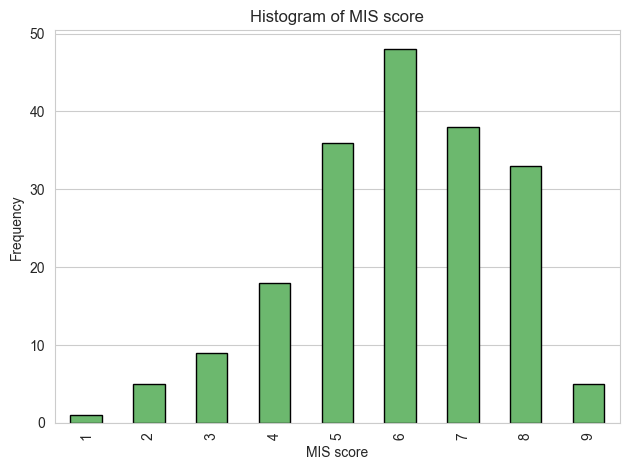

In [309]:
# Compute distribution of MIS scores (excluding missing values) and sort by score
MIS_counts = df_all['MIS score'].dropna().value_counts().sort_index()

# Plot the bar chart of MIS score frequencies
MIS_his = MIS_counts.plot.bar(edgecolor='black')

# Label the axes and set the title
MIS_his.set_xlabel('MIS score')
MIS_his.set_ylabel('Frequency')
MIS_his.set_title('Histogram of MIS score')

# Save the histogram as a PNG file
MIS_his.xaxis.grid(False)
MIS_his.figure.tight_layout()
MIS_his.figure.savefig('mis_histogram.png', dpi=300, bbox_inches='tight')

## Publication Year Distribution

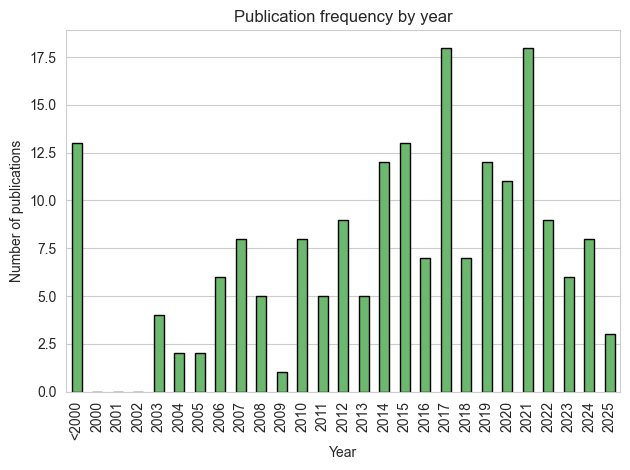

In [310]:
# Compute distribution of publication years with a "<2000" bin and ensure all years 2000-2025 are present
# NB! DOES NOT COUNT MISSING VALUES

years_clean = pd.to_numeric(df_all['Year of publication'], errors='coerce').dropna().astype(int)
year_labels = years_clean.map(lambda y: '<2000' if y < 2000 else str(y))
year_counts = year_labels.value_counts()

# Ensure all desired categories are present (fill missing with 0)
categories = ['<2000'] + [str(y) for y in range(2000, 2026)]
year_counts = year_counts.reindex(categories, fill_value=0)

# Plot the bar chart of year frequencies
year_hist = year_counts.loc[categories].plot.bar(edgecolor='black')

# Label the axes and set the title
year_hist.set_xlabel('Year')
year_hist.set_ylabel('Number of publications')
year_hist.set_title('Publication frequency by year')

# Save the histogram as a PNG file
year_hist.xaxis.grid(False)
year_hist.figure.tight_layout()
year_hist.figure.savefig('year_histogram.png', dpi=300, bbox_inches='tight')


## Year stacked by MIS

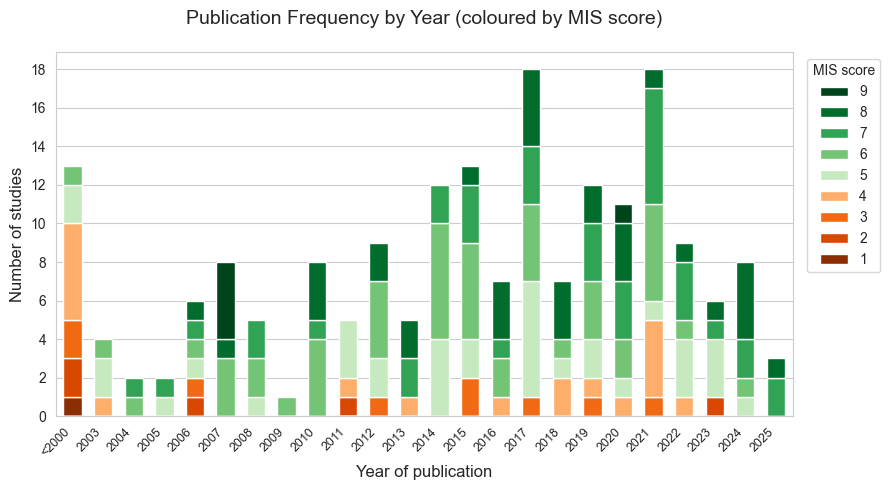

In [355]:
# Stacked bar chart: publication count by year, coloured by MIS score

# Data prep (same logic as area chart above)
years_mis_bar = pd.to_numeric(df_all['Year of publication'], errors='coerce').dropna().astype(int)
mis_year_labels_bar = years_mis_bar.map(lambda y: '<2000' if y < 2000 else str(y))
mis_scores_bar = pd.to_numeric(df_all.loc[years_mis_bar.index, 'MIS score'], errors='coerce')
mis_year_df_bar = pd.DataFrame({'Year': mis_year_labels_bar, 'MIS': mis_scores_bar}).dropna()
mis_year_df_bar['MIS'] = mis_year_df_bar['MIS'].astype(int)
crosstab_bar = pd.crosstab(mis_year_df_bar['Year'], mis_year_df_bar['MIS'])
for score in range(1, 10):
    if score not in crosstab_bar.columns:
        crosstab_bar[score] = 0
crosstab_bar = crosstab_bar[list(range(1, 10))]
categories_bar = ['<2000'] + [str(y) for y in range(2000, 2026)]
crosstab_bar = crosstab_bar.reindex([c for c in categories_bar if c in crosstab_bar.index], fill_value=0)

colors_mis_bar = [
    '#8c2d04', '#d94801', '#f16913', '#fdae6b',
    '#c7e9c0', '#74c476', '#31a354', '#006d2c', '#00441b',
]

fig_mis_bar, ax_mis_bar = plt.subplots(figsize=(9, 5))
crosstab_bar.plot(kind='bar', stacked=True, color=colors_mis_bar, ax=ax_mis_bar, width=0.6)

ax_mis_bar.set_xlabel('Year of publication', fontsize=12)
ax_mis_bar.set_ylabel('Number of studies', fontsize=12)
ax_mis_bar.set_title('Publication Frequency by Year (coloured by MIS score)', fontsize=14, pad=20)
ax_mis_bar.set_xticklabels(crosstab_bar.index, rotation=45, ha='right', fontsize=9)
ax_mis_bar.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Reverse legend to match area chart (9 on top)
handles_bar, labels_bar = ax_mis_bar.get_legend_handles_labels()
ax_mis_bar.legend(
    handles_bar[::-1], labels_bar[::-1],
    title='MIS score',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=10
)

ax_mis_bar.xaxis.grid(False)
plt.tight_layout()
fig_mis_bar.savefig('mis_score_by_year_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Year stacked country of corresponding author

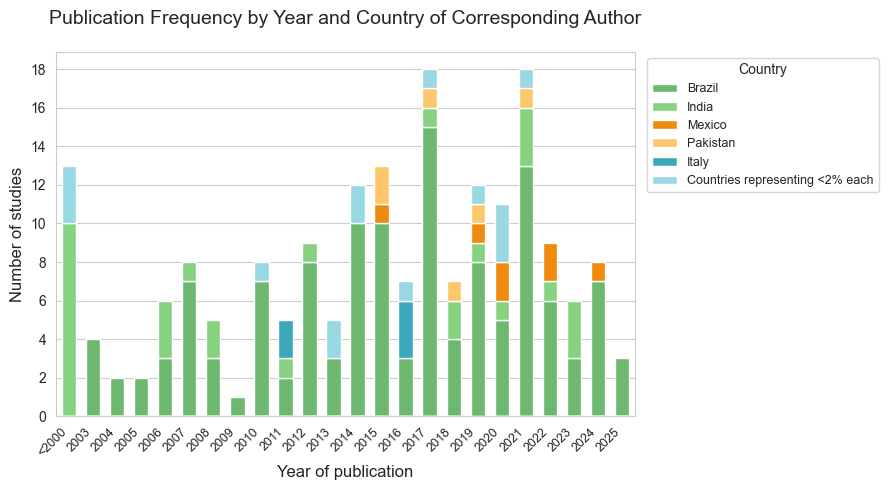

In [312]:
# Publication frequency by year, stacked by country of corresponding author

# Year binning — identical logic to year histogram
years_ctry = pd.to_numeric(df_all['Year of publication'], errors='coerce').dropna().astype(int)
year_labels_ctry = years_ctry.map(lambda y: '<2000' if y < 2000 else str(y))

# Country grouping — identical <2% logic to country pie chart
country_series_yr = (
    df_all['Country of corresponding author']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'Parkistan': 'Pakistan'})
)
init_counts_yr = country_series_yr.value_counts()
init_total_yr = int(init_counts_yr.sum())
to_other_yr = init_counts_yr[(init_counts_yr / init_total_yr) * 100 < 2.0].index
country_grouped_yr = country_series_yr.replace(
    {k: 'Countries representing <2% each' for k in to_other_yr}
)

# Align year labels and country to same valid rows
valid_idx_yr = years_ctry.index
country_yr_clean = country_grouped_yr.loc[valid_idx_yr]

# Crosstab: Year bin (rows) × Country (columns)
ctab_yr_country = pd.crosstab(year_labels_ctry, country_yr_clean)

# Order rows by year bin
categories_yr = ['<2000'] + [str(y) for y in range(2000, 2026)]
ctab_yr_country = ctab_yr_country.reindex(
    [c for c in categories_yr if c in ctab_yr_country.index], fill_value=0
)

# Order columns: major countries by frequency, <2% group last
major_countries_yr = [c for c in init_counts_yr.index if c not in to_other_yr]
col_order_yr = [c for c in major_countries_yr if c in ctab_yr_country.columns]
if 'Countries representing <2% each' in ctab_yr_country.columns:
    col_order_yr.append('Countries representing <2% each')
ctab_yr_country = ctab_yr_country[col_order_yr]

# Colors
colors_yr_country = QUALITATIVE_COLORS[:len(col_order_yr)]

fig_yr_ctry, ax_yr_ctry = plt.subplots(figsize=(9, 5))
ctab_yr_country.plot(kind='bar', stacked=True, color=colors_yr_country, ax=ax_yr_ctry, width=0.6)

ax_yr_ctry.set_xlabel('Year of publication', fontsize=12)
ax_yr_ctry.set_ylabel('Number of studies', fontsize=12)
ax_yr_ctry.set_title('Publication Frequency by Year and Country of Corresponding Author', fontsize=14, pad=20)
ax_yr_ctry.set_xticklabels(ctab_yr_country.index, rotation=45, ha='right', fontsize=9)
ax_yr_ctry.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax_yr_ctry.legend(
    title='Country',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9
)

ax_yr_ctry.xaxis.grid(False)
plt.tight_layout()
fig_yr_ctry.savefig('year_country_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Country of Corresponding Author

In [313]:
# Title: Corresponding Author Country Distribution (Pie Chart)
# Description: Cleans and standardizes country names, groups countries contributing <2% of studies into a single "Countries representing <2% each" category, 
#              calculates percentages, renders a Plotly pie chart with adaptive label placement (inside/outside), and saves the figure as 'country_pie.png'.

# Prepare and normalize data
country_series = (
    df_all['Country of corresponding author']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'Parkistan': 'Pakistan'})
)

# Initial counts to determine <2% threshold
initial_counts = country_series.value_counts()
initial_total = int(initial_counts.sum())

# Group all countries contributing <2% into "Other"
threshold_pct = 2.0
to_other = initial_counts[(initial_counts / initial_total) * 100 < threshold_pct].index
country_series_grouped = country_series.replace({k: 'Countries representing <2% each' for k in to_other})

# Final counts/labels/values after grouping
country_counts = country_series_grouped.value_counts()
labels = country_counts.index.tolist()
values = country_counts.values.tolist()

# Compute percentages and set label positions
total = int(sum(values))
percentages = [(v / total) * 100 if total else 0 for v in values]
percentages_cutoff = 10
text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in percentages]
custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels, percentages, text_positions)
]

# Build pie chart (Plotly shows leader lines automatically for outside labels)
country_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels,
            values=values,
            text=custom_text,
            textinfo='text',
            textposition=text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

country_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=12, color='black'),
country_pie.update_layout(
    title='Country of corresponding author',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

country_pie.show()  #Plotly figures are data objects when created, call .show() to display them

#Save the figure as a PNG file. Note: matplotlib uses .figure.savefig(), plotly uses .write_image().
country_pie.write_image('country_pie.png', width=800, height=600, scale=2)


## MIS stacked by country

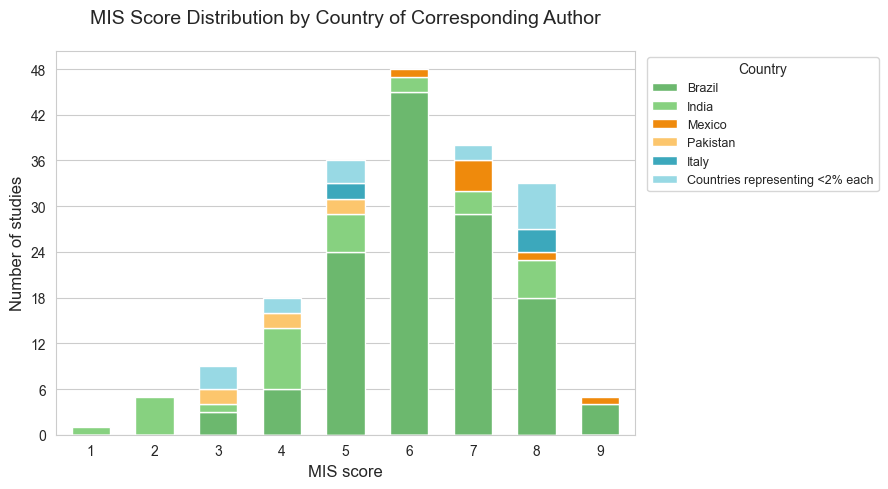

In [314]:
# MIS score distribution stacked by country (same <2% grouping as pie chart above)

# Country grouping — identical logic to the pie chart
country_series_mis = (
    df_all['Country of corresponding author']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'Parkistan': 'Pakistan'})
)
init_counts_mis = country_series_mis.value_counts()
init_total_mis = int(init_counts_mis.sum())
to_other_mis = init_counts_mis[(init_counts_mis / init_total_mis) * 100 < 2.0].index
country_grouped_mis = country_series_mis.replace(
    {k: 'Countries representing <2% each' for k in to_other_mis}
)

# MIS scores aligned to same rows
mis_for_country = pd.to_numeric(df_all['MIS score'], errors='coerce')
valid_idx = mis_for_country.dropna().index
mis_clean = mis_for_country.loc[valid_idx].astype(int)
country_clean = country_grouped_mis.loc[valid_idx]

# Crosstab: MIS score (x-axis) × Country (stacked)
ctab_mis_country = pd.crosstab(mis_clean, country_clean)

# Order columns: countries by overall frequency, <2% group last
major_countries = [c for c in init_counts_mis.index if c not in to_other_mis]
col_order = [c for c in major_countries if c in ctab_mis_country.columns]
if 'Countries representing <2% each' in ctab_mis_country.columns:
    col_order.append('Countries representing <2% each')
ctab_mis_country = ctab_mis_country[col_order]

# Colors matching qualitative palette (same order as pie chart)

colors_country = QUALITATIVE_COLORS[:len(col_order)]

fig_mis_ctry, ax_mis_ctry = plt.subplots(figsize=(9, 5))
ctab_mis_country.plot(kind='bar', stacked=True, color=colors_country, ax=ax_mis_ctry, width=0.6)

ax_mis_ctry.set_xlabel('MIS score', fontsize=12)
ax_mis_ctry.set_ylabel('Number of studies', fontsize=12)
ax_mis_ctry.set_title('MIS Score Distribution by Country of Corresponding Author', fontsize=14, pad=20)
ax_mis_ctry.set_xticklabels(ctab_mis_country.index, rotation=0, fontsize=10)
ax_mis_ctry.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax_mis_ctry.legend(
    title='Country',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9
)

ax_mis_ctry.xaxis.grid(False)
plt.tight_layout()
fig_mis_ctry.savefig('mis_country_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Language of Full Article

In [315]:
# Title: Language of Full Article Distribution (Pie Chart)
# Description: Normalizes language labels (handles '&' vs '+', trims, canonicalizes multi-language order),
#              aggregates counts, computes percentages with adaptive label placement, and renders/saves a Plotly pie chart.

# Prepare data
language_series = (
    df_all['Language of full article']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)


# SPECIAL CASE re-labeling/normalization:
# - This is a dataset-specific cleanup to standardize mixed-language entries.
# - We treat '&' as equivalent to '+' and canonicalize the order of languages
#   so that permutations like "English+Spanish" and "Spanish+English" map to the same label.
def _normalize_language_label(s: str) -> str:
    if not s or s.lower() == 'unknown':
        return 'Unknown'
    # SPECIAL CASE: normalize separator
    s = s.replace('&', '+')
    parts = [p.strip().title() for p in s.split('+') if p.strip()]
    if not parts:
        return 'Unknown'
    # SPECIAL CASE: sort to combine permutations like "English+Spanish" and "Spanish+English"
    parts = sorted(dict.fromkeys(parts))  # remove duplicates and sort
    return '+'.join(parts) if len(parts) > 1 else parts[0]


# Apply the special-case normalization to the language labels
language_series = language_series.apply(_normalize_language_label)

language_counts = language_series.value_counts()
lang_labels = language_counts.index.tolist()
lang_values = language_counts.values.tolist()

# Compute percentages and set label positions
lang_total = sum(lang_values)
lang_percentages = [(v / lang_total) * 100 if lang_total else 0 for v in lang_values]
percentages_cutoff = 10
lang_text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in lang_percentages]
lang_custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(lang_labels, lang_percentages, lang_text_positions)
]

# Build pie chart with style similar to the country chart
language_pie = go.Figure(
    data=[
        go.Pie(
            labels=lang_labels,
            values=lang_values,
            text=lang_custom_text,
            textinfo='text',
            textposition=lang_text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

language_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=12, color='black'),
language_pie.update_layout(
    title='Language of full article',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

language_pie.show()
language_pie.write_image('language_pie.png', width=800, height=600, scale=2)

# Study Characteristics (MIS ≥ 5)

## Replication Status

In [316]:
# Here starts plottings that are only relevant for MIS score > 5
# ===============================================================

# Rebind df to the subset with MIS >= 5 for all plots below
df = df_all[df_all['MIS score'] >= 5].copy()
print(f'Using N={len(df)} studies with MIS score >= 5 for subsequent plots')



Using N=160 studies with MIS score >= 5 for subsequent plots


In [317]:
# Title: Replication Landscape Among Included Studies (Pie Chart)
# Description:
# - Visualizes the distribution of studies by replication status: single studies, direct (actual) replications,
#   and studies replicating the same drug on a different plant system.
# - Labels are positioned adaptively for readability, and a small slice is slightly separated to draw attention.
# - NOTE: Values are placeholder (MADE UP DATA). Replace with dynamic counts once replication metadata are available.

ironic_replications = go.Figure(data=[go.Pie(
    labels=['Single studies', 'Actual replications', 'Studies replicating a same drug<br>on other plant system'],
    values=[148, 0, 1],  # MADE UP DATA: replace with computed values from dataset
    textinfo='label+percent',
    textposition=['inside', 'none', 'outside'],
    insidetextorientation='horizontal',
    pull=[0, 0, 0.08],  # separate the tiny slice
    hovertemplate='%{label}: %{value} studies<extra></extra>'
)])

ironic_replications.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)


textfont=dict(size=12, color='black'),
ironic_replications.update_layout(
    margin=dict(t=120, b=20, l=20, r=20)
)

ironic_replications.show()
ironic_replications.write_image('replications.png', width=800, height=600, scale=2)


## Blinding Status

In [318]:
# Title: Blinding Status Distribution (Pie Chart)
# Description: Visualizes the distribution of blinding status among included studies (current MIS ≥ 5 subset).
#              Cleans labels, aggregates counts, computes percentages with adaptive label placement for readability,
#              renders an interactive Plotly pie chart, and saves it as 'blinded_pie.png'.

# Prepare data
blinded_series = (
    df['Blinded']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)

blinded_counts = blinded_series.value_counts()
blinded_labels = blinded_counts.index.tolist()
blinded_values = blinded_counts.values.tolist()

# Compute percentages and set label positions
blinded_total = sum(blinded_values)
blinded_percentages = [(v / blinded_total) * 100 if blinded_total else 0 for v in blinded_values]
percentages_cutoff = 10
blinded_text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in blinded_percentages]
blinded_custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(blinded_labels, blinded_percentages, blinded_text_positions)
]

# Build pie chart with style similar to the language chart
blinded_pie = go.Figure(
    data=[
        go.Pie(
            labels=blinded_labels,
            values=blinded_values,
            text=blinded_custom_text,
            textinfo='text',
            textposition=blinded_text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

blinded_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=12, color='black'),
blinded_pie.update_layout(
    title='Blinded',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

# Display chart and save
blinded_pie.show()
blinded_pie.write_image('blinded_pie.png', width=800, height=600)

## Experimental Settings

In [319]:
df['Setting in which treated'].dropna().value_counts().sort_index()



Setting in which treated
Farm / open fields                                                            37
Farm / open fields, Greenhouse open                                            1
Farm / open fields, Indoor unspecific                                          1
Greenhouse clima controlled                                                    8
Greenhouse clima controlled, Microbiological experiment                        1
Greenhouse open                                                               35
Greenhouse open, Indoor unspecific                                             1
Greenhouse open, Microbiological experiment                                    1
Greenhouse unspecific                                                         24
Greenhouse unspecific, Farm / open fields                                      1
Greenhouse unspecific, Greenhouse clima controlled                             1
Greenhouse unspecific, Microbiological experiment                              1
Gre

<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/my_first_analysis.ipynb</llm-snippet-file>


<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/agro_hom_figures260212.ipynb</llm-snippet-file>


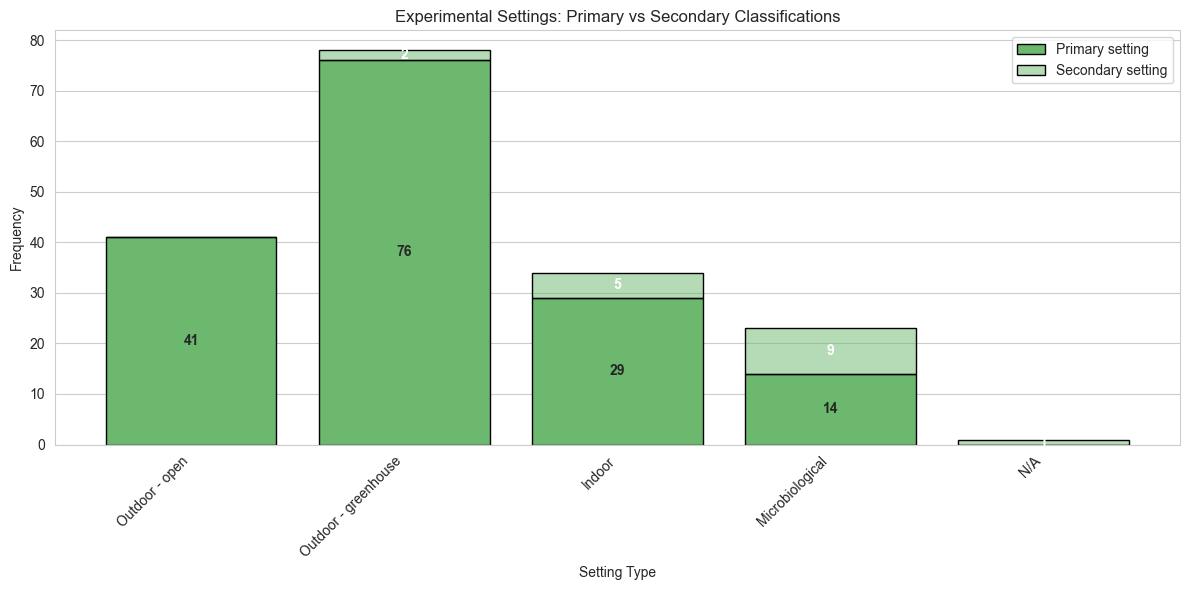

In [320]:
# Setting in which treated bar chart. Makes a chart with the first bar being Outdoor - open (most open) and so forth (less open, more controlled). If a study has multiple settings, it counts in multiple bars, but any secondary (or third...) settings are counted in the secondary bars on top. This primary/secondary is prioritized according to the same order from most open to least open.

# Create mapping dictionary
mapping = {
    'Farm / open fields': 'Outdoor - open',
    'Greenhouse clima controlled': 'Outdoor - greenhouse',
    'Greenhouse open': 'Outdoor - greenhouse',
    'Greenhouse unspecific': 'Outdoor - greenhouse',
    'Indoor clima controlled': 'Indoor',
    'Indoor unspecific': 'Indoor',
    'Microbiological experiment': 'Microbiological',
    'N/A or not relevant': 'N/A'
}

# Define categories in order of importance
categories = ['Outdoor - open', 'Outdoor - greenhouse', 'Indoor', 'Microbiological', 'N/A']

# Initialize counters
primary_counts = {cat: 0 for cat in categories}
secondary_counts = {cat: 0 for cat in categories}

# Process each entry
for entry in df['Setting in which treated'].dropna():
    # Split by comma and strip whitespace
    settings = [s.strip() for s in entry.split(',')]

    # Map each setting to category
    mapped_settings = []
    for setting in settings:
        if setting in mapping:
            mapped_settings.append(mapping[setting])

    if mapped_settings:
        # First category (highest priority) goes to primary
        primary_category = None
        for cat in categories:  # Check in order of importance
            if cat in mapped_settings:
                primary_category = cat
                break

        if primary_category:
            primary_counts[primary_category] += 1

            # Remaining categories go to secondary
            remaining = [cat for cat in mapped_settings if cat != primary_category]
            for cat in remaining:
                secondary_counts[cat] += 1

# Create the plot
settings_bar, ax = plt.subplots(figsize=(12, 6))

# Use standard colors from global settings:
# - All primary bars use the first green from the global palette
# - "Light" bars remain defined via transparency (same hue with alpha)
try:
    base_color = QUALITATIVE_COLORS[0]  # first green from global palette
except NameError:
    base_color = '#6CB86E'  # fallback to the known first green used globally

colors = {cat: base_color for cat in categories}
light_colors = {cat: base_color + '80' for cat in categories}  # 50% transparency (RGBA hex)

x_pos = np.arange(len(categories))

# Plot primary bars
primary_values = [primary_counts[cat] for cat in categories]
bars1 = ax.bar(x_pos, primary_values, color=[colors[cat] for cat in categories],
               label='Primary setting', edgecolor='black')

# Plot secondary bars on top
secondary_values = [secondary_counts[cat] for cat in categories]
bars2 = ax.bar(x_pos, secondary_values, bottom=primary_values,
               color=[light_colors[cat] for cat in categories],
               label='Secondary setting', edgecolor='black')

# Customize the plot
ax.set_xlabel('Setting Type')
ax.set_ylabel('Frequency')
ax.set_title('Experimental Settings: Primary vs Secondary Classifications')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()

# Add value labels on bars
for i, (p, s) in enumerate(zip(primary_values, secondary_values)):
    if p > 0:
        ax.text(i, p / 2, str(p), ha='center', va='center', fontweight='bold')
    if s > 0:
        ax.text(i, p + s / 2, str(s), ha='center', va='center', fontweight='bold', color='white')

ax.xaxis.grid(False)
plt.tight_layout()
settings_bar.savefig('settings_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Crop Types Studied

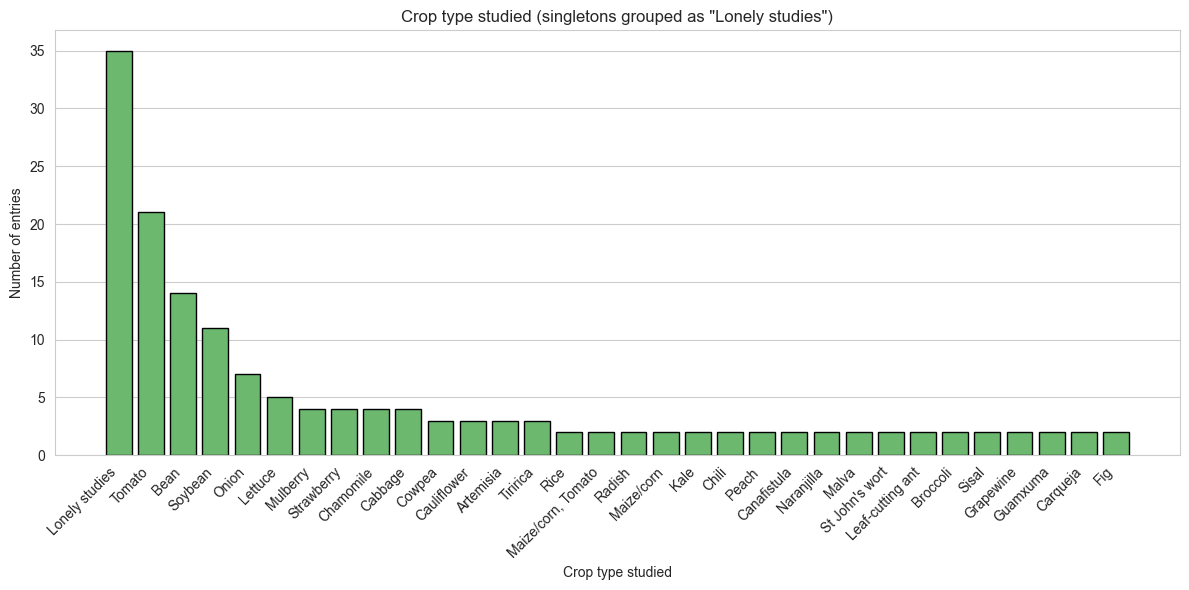

In [321]:
# Analyze and visualize the distribution of "Crop type studied" with all singletons grouped as "Lonely studies".
# Steps:
# 1) Clean the "Crop type studied" column (drop missing, ensure strings, trim spaces).
# 2) Count occurrences of each unique crop type.
# 3) Group all categories that appear only once (singletons) under a single label "Lonely studies".
# 4) Sort by frequency (descending) and plot a bar chart.
# 5) Save the figure as a PNG and display it.

# 1) Clean the source series
crop_series = df['Crop type studied'].dropna().astype(str).str.strip()

# 2) Raw counts by crop type
crop_counts = crop_series.value_counts()

# 3) Group all singletons under "Lonely studies"
lonely_mask = crop_counts == 1  # True for categories that appear exactly once
lonely_count = int(crop_counts[lonely_mask].sum())  # Total number of singleton entries (studies)
grouped_counts = crop_counts[~lonely_mask].copy()  # Keep non-singletons as-is
if lonely_count > 0:
    grouped_counts.loc['Lonely studies'] = lonely_count

# 4) Sort for plotting
grouped_counts = grouped_counts.sort_values(ascending=False)

# 5) Plot bar chart
# Use matplotlib directly
fig, crop_bar = plt.subplots(figsize=(12, 6))
bars = crop_bar.bar(range(len(grouped_counts)), grouped_counts.values, edgecolor='black')
crop_bar.set_xticks(range(len(grouped_counts)))
crop_bar.set_xticklabels(grouped_counts.index, rotation=45, ha='right')
crop_bar.set_xlabel('Crop type studied')
crop_bar.set_ylabel('Number of entries')
crop_bar.set_title('Crop type studied (singletons grouped as "Lonely studies")')

# Save and show
crop_bar.xaxis.grid(False)
crop_bar.figure.tight_layout()
crop_bar.figure.savefig('crop_type_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Main Biological Systems - Individual lables counted, not main biological system pr study

Task: Create a pie chart like the "Country of corresponding author" chart for the column "Main biological system studied". Split multiple systems separated by commas and count each individually, except keep "Harvest (fruit, grains, tubers)" as a single, unsplit category.

In [322]:

# - Split comma-separated entries so each system is counted individually.
# - Preserve the phrase "Harvest (fruit, grains, tubers)" as one unit (do not split it).
# - Display a clean pie chart with percentages and a clear, informative title.

# 1) Normalize and clean the source column
bio_series = (
    df['Main biological system studied']  # source column
    .fillna('N/A')  # fill missing as 'Unknown'
    .astype(str)  # ensure string type
    .str.strip()  # trim whitespace
    .replace({'': 'Unknown'})  # safeguard empty strings
)

# 2) Protect the multi-word phrase so it doesn't get split by commas
protected_phrase = 'Harvest (fruit, grains, tubers)'
protected_placeholder = 'Harvest (fruit-grains-tubers)'  # temporary replacement (semicolons)

# Replace the protected phrase with a placeholder before splitting
bio_series = bio_series.str.replace(protected_phrase, protected_placeholder, regex=False)

# 3) Split by comma, explode into one value per row, and clean up
bio_exploded = (
    bio_series
    .str.split(',')  # split comma-separated values
    .explode()  # one value per row
    .astype(str)
    .str.strip()
)

# Restore the protected phrase and handle any remaining empties
bio_exploded = bio_exploded.replace({'': 'N/A', protected_placeholder: protected_phrase})

# 4) Aggregate counts and prepare labels/values
bio_counts = bio_exploded.value_counts()
bio_labels = bio_counts.index.tolist()
bio_values = bio_counts.values.tolist()

# 4b) Define intuitive colors matching labels
color_map = {
    'Adult plants': '#1b7837',  # dark green (mature plants)
    'Seedling': '#5aae61',  # medium green (young plants)
    'Seed': '#8c510a',  # brown (seeds)
    'Cutlings': '#ccebc5',  # pale green (cuttings)
    'Harvest (fruit, grains, tubers)': '#faa945',  # harvest -> golden/orange
    '"Harvest (fruit-grains-tubers)"': '#faa945',  # safeguard variant in data
    'Fungus': '#7c6a7c',  # purple (fungi)
    'Bacteria': '#2b8cbe',  # blue (bacteria)
    'Animal (eg. insect)': '#d95f02',  # orange (insects/animals)
    'Soil': '#664012',  # sark brown (soil)
    'Run-overs': '#246f3b',  # desaturated dark green (misc/other)
    'N/A': '#bdbdbd'  # light gray (unknown)
}
bio_colors = [color_map.get(lbl, '#cccccc') for lbl in bio_labels]
bio_labels = [add_line_breaks_to_label(lbl, strategy='parentheses') for lbl in bio_labels]

# 5) Compute percentages and decide label placement (outside for small slices)
bio_total = int(sum(bio_values))
bio_percentages = [(v / bio_total) * 100 if bio_total else 0 for v in bio_values]
percentages_cutoff = 10
bio_text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in bio_percentages]

# Create custom text with conditional formatting (inline for outside, two-line for inside)
bio_custom_text = []
for label, value in zip(bio_labels, bio_values):
    percent = (value / sum(bio_values)) * 100
    if percent < 10:  # Outside label - one line
        bio_custom_text.append(f'{label} {percent:.1f}%')
    else:  # Inside label - two lines
        bio_custom_text.append(f'{label} {percent:.1f}%')


# 6) Build the Plotly pie chart
bio_pie = go.Figure(
    data=[
        go.Pie(
            labels=bio_labels,
            values=bio_values,
            text=bio_custom_text,
            textinfo='text',
            textposition=bio_text_positions,  # inside for large slices, outside for small ones
            insidetextorientation='horizontal',
            sort=False,  # keep current order (by frequency)
            direction='clockwise',
            rotation=90,  # start at 12 o'clock
            marker=dict(colors=bio_colors, line=dict(color='white', width=1))
        )
    ]
)

bio_pie.update_traces(
     textfont=dict(size=12, color='black'),
     insidetextfont=dict(color='black'),
)
 

# 7) Style and title (include N and note multi-selection)
bio_pie.update_layout(
    title=f'Main Biological System Studied (N={bio_total})',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

# 8) Render and export
bio_pie.show()
bio_pie.write_image('main_bio_system_pie.png', width=800, height=600, scale=2)

In [323]:
# Create treemap chart for Main Biological System (same data as pie chart)

bio_treemap = go.Figure(
    data=[
        go.Treemap(
            labels=bio_labels,
            values=bio_values,
            parents=[''] * len(bio_labels),  # all at root level
            text=bio_custom_text,
            textinfo='label+text',
            textposition='middle center',
            marker=dict(
                colors=bio_colors,
                line=dict(color='white', width=2)
            ),
            textfont=dict(size=12, color='black')
        )
    ]
)

bio_treemap.update_layout(
    title=f'Main Biological System Studied - Treemap (N={bio_total})',
    margin=dict(t=60, b=20, l=20, r=20)
)

bio_treemap.show()
bio_treemap.write_image('main_bio_system_treemap.png', width=800, height=600, scale=2)


## Parallel Interventions

<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/my_first_analysis.ipynb</llm-snippet-file>


In [324]:
# Title: Parallel Interventions Applied (Grouped Pie Chart)
# Description: Cleans and standardizes the "Parallel interventions applied" column, maps granular entries to broader categories, splits comma-separated selections to count each individually, computes frequencies and adaptive label placement, and renders/saves a Plotly pie chart with N in the subtitle.

# - Map granular entries to broader, report-friendly categories
# - Split multi-valued cells and count each intervention individually
# - Visualize the grouped distribution with clear labeling and a descriptive title

# 1) Clean and standardize the source column
parallel_series = (
    df['Parallel interventions applied']
    .fillna('N/A')  # replace missing with explicit 'N/A'
    .astype(str)  # ensure strings
    .str.strip()  # trim whitespace
)

# 2) Mapping from raw entries to grouped categories
mapping = {
    'Chemical fertilizers': 'Chemical (fertilizers, pesticides)',
    'Chemical pest control or antibiotics': 'Chemical (fertilizers, pesticides)',
    'Seed sanitazion with chlorine/HgCl2/alcohol or similar': 'Chemical (fertilizers, pesticides)',
    'Manure or organic fertilizers': 'Organic (manure, organic fertilizers)',
    'Active inoculation with microbiotic pathogen': 'Biological (inoculation, insects)',
    'Active application of insects/nymphs': 'Biological (inoculation, insects)',
    'Active inoculation with microbiotic pathogen as part of factorial design': 'Biological (inoculation, insects)',
    'Catch crop': 'Biological (inoculation, insects)',
    'Salt-stress': 'Stress treatment',
    'Heat-stress': 'Stress treatment',
    'Water-stress': 'Stress treatment',
    'Salt-stress as part of factorial design': 'Stress treatment',
    'Aluminium-stress': 'Stress treatment',
    'Heavy metal-stress': 'Stress treatment',
    'None': 'None',
    'N/A': 'N/A',
}

# 3) Split cells on comma, explode to rows, trim, and coerce empties to 'N/A'
entries = (
    parallel_series
    .str.split(',')  # split multiple interventions
    .explode()  # count each intervention separately
    .astype(str)
    .str.strip()
    .replace({'': 'N/A'})
)

# 4) Apply grouping (keep any unmapped entries as-is to surface unexpected values)
grouped = entries.map(lambda x: mapping.get(x, x))

# 5) Count and keep the natural order of most prevalent (value_counts is descending by default)
grouped_counts = grouped.value_counts()

# 7) Prepare data for the pie chart
labels = grouped_counts.index.tolist()
labels = [add_line_breaks_to_label(lbl, strategy='parentheses') for lbl in labels]
values = grouped_counts.values.tolist()
total = int(sum(values)) if len(values) else 0

# Place labels outside if the slice is small to improve readability (threshold: 11%)
percentages = [(v / total) * 100 if total else 0 for v in values]
percentages_cutoff = 11
text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in percentages]
custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels, percentages, text_positions)
]

# 8) Build the pie chart (styled consistently with the "Country of corresponding author" chart)
parallel_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels,
            values=values,
            text=custom_text,
            textinfo='text',
            textposition=text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=70,
        )
    ]
)

parallel_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)

# 9) Styling and a descriptive title including N and methodological notes
textfont = dict(size=12, color='black'),
parallel_pie.update_layout(
    title=f'Parallel interventions applied'
          f'<br><sup>Grouped categories; multi-selections counted individually; N={total}</sup>',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

# 10) Display and export
parallel_pie.show()
parallel_pie.write_image('parallel_interventions_applied_pie.png', width=800, height=600, scale=2)


<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/agro_hom_figures250924.ipynb</llm-snippet-file>


## Intervention Types

Homeopathic interventions — summary
-----------------------------------
Excluded entry: "Additional: Dilution in water before application"
Occurrences of excluded entry: 15 (9.38% of 160 studies)

Number of interventions per study (count of studies having 0, 1, 2, ... interventions):
                          Number of studies
Homeopathic intervention                   
0                                         1
1                                       147
2                                        10
3                                         2


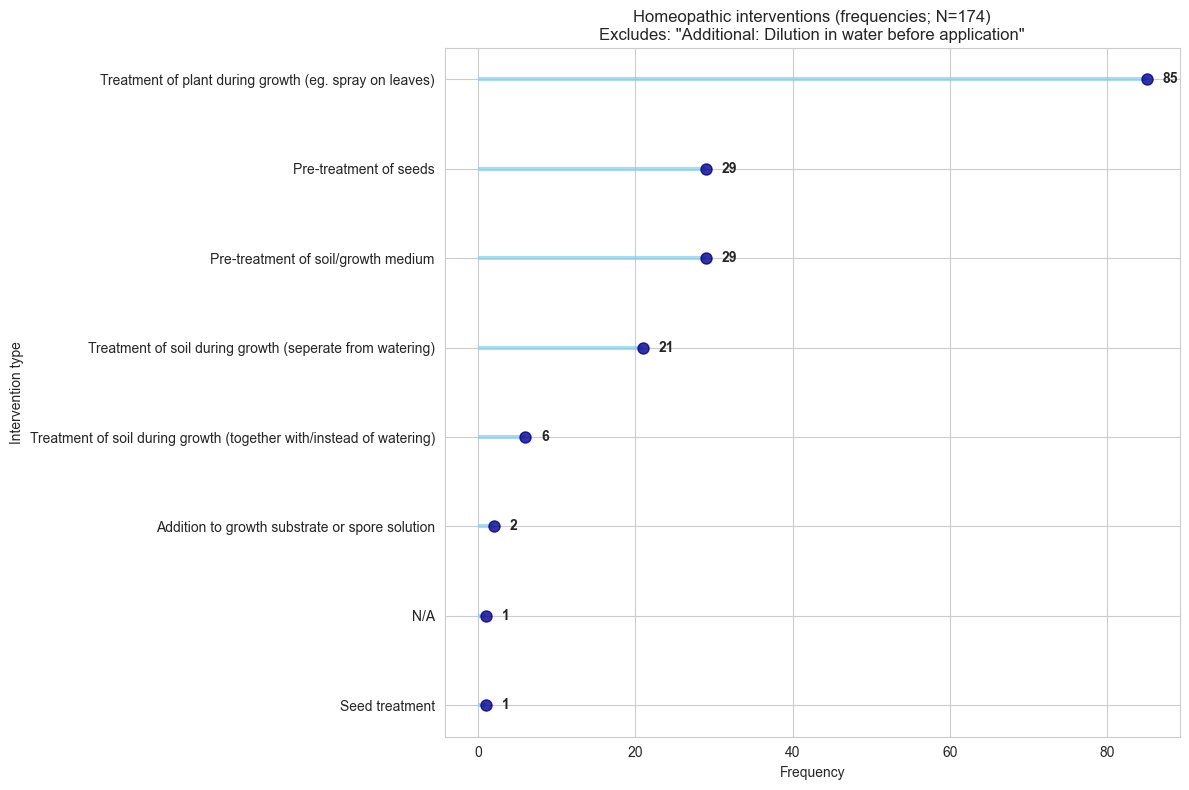

In [325]:
# Analysis: Homeopathic intervention types (lollipop chart)
# What this cell does:
# 1) Cleans and splits the "Homeopathic intervention" column on commas to get individual interventions.
# 2) Excludes a specific non-intervention entry: "Additional: Dilution in water before application".
# 3) Computes:
#    - How often the excluded entry appears and its percentage of studies (vs original df rows).
#    - A frequency table of intervention types (with the excluded entry removed).
#    - The distribution of how many interventions are listed per study.
# 4) Visualizes the intervention frequencies as a lollipop chart with data labels.

# Clean and split the entries
homeopathic_series_hom_interven = (
    df['Homeopathic intervention']
    .fillna('N/A')
    .astype(str)
    .str.strip()
)

exploded_interventions_hom_interven = (
    homeopathic_series_hom_interven
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'N/A'})
)

# Item to remove (non-intervention metadata)
dilution_separate_hom_interven = "Additional: Dilution in water before application"

# Compute count and percentage relative to the number of rows in the original df
original_n_hom_interven = len(df)
dilution_separate_count_hom_interven = int(
    (exploded_interventions_hom_interven == dilution_separate_hom_interven).sum())
dilution_separate_pct_hom_interven = (
        dilution_separate_count_hom_interven / original_n_hom_interven * 100
) if original_n_hom_interven else 0.0

# Remove the item from the list and rebuild the frequency table
filtered_interventions_hom_interven = exploded_interventions_hom_interven[
    exploded_interventions_hom_interven != dilution_separate_hom_interven
    ]
homeopathic_intervention_freq_hom_interven = (
    filtered_interventions_hom_interven
    .value_counts()
    .to_frame(name='Frequency')
)


# New: compute per-study counts of interventions (excluding N/A and the removed item)
def _count_interventions_hom_interven(cell: str) -> int:
    parts = [p.strip() for p in str(cell).split(',')]
    parts = [p for p in parts if p and p != 'N/A' and p != dilution_separate_hom_interven]
    return len(parts)


per_study_counts_hom_interven = homeopathic_series_hom_interven.apply(_count_interventions_hom_interven)
interventions_per_study_counts_hom_interven = (
    per_study_counts_hom_interven.value_counts().sort_index().to_frame(name='Number of studies')
)

# Intro/summary prints
print('Homeopathic interventions — summary')
print('-----------------------------------')
print(f'Excluded entry: "{dilution_separate_hom_interven}"')
print(f'Occurrences of excluded entry: {dilution_separate_count_hom_interven} '
      f'({dilution_separate_pct_hom_interven:.2f}% of {original_n_hom_interven} studies)')
print('\nNumber of interventions per study (count of studies having 0, 1, 2, ... interventions):')
print(interventions_per_study_counts_hom_interven)

# Show the frequency table (excluding the removed item)
homeopathic_intervention_freq_hom_interven

# Build lollipop chart
fig_hom_interven, ax_hom_interven = plt.subplots(figsize=(12, 8))

# Sort data ascending for a clean lollipop layout
sorted_data_hom_interven = homeopathic_intervention_freq_hom_interven.sort_values('Frequency', ascending=True)
y_pos_hom_interven = np.arange(len(sorted_data_hom_interven))

# Create lollipop stems and markers
ax_hom_interven.hlines(
    y=y_pos_hom_interven, xmin=0, xmax=sorted_data_hom_interven['Frequency'],
    color='skyblue', alpha=0.7, linewidth=3
)
ax_hom_interven.plot(
    sorted_data_hom_interven['Frequency'], y_pos_hom_interven, "o",
    markersize=8, color='darkblue', alpha=0.8
)

# Add numeric labels to the right of each marker
for i, v in enumerate(sorted_data_hom_interven['Frequency']):
    ax_hom_interven.text(v + 2, i, str(v), va='center', fontweight='bold')

# Axes and title
ax_hom_interven.set_yticks(y_pos_hom_interven)
ax_hom_interven.set_yticklabels(sorted_data_hom_interven.index)
ax_hom_interven.set_xlabel('Frequency')
ax_hom_interven.set_ylabel('Intervention type')

# Title includes N (after exclusion) and a note about the exclusion
final_total = int(sorted_data_hom_interven['Frequency'].sum())
ax_hom_interven.set_title(
    f'Homeopathic interventions (frequencies; N={final_total})\n'
    f'Excludes: "{dilution_separate_hom_interven}"'
)

plt.tight_layout()
fig_hom_interven.savefig('homeopathic_interventions_lollipop.png', dpi=300, bbox_inches='tight')
plt.show()


In [326]:
df[('Remedy/remedies ')].dropna().value_counts()


Remedy/remedies 
Natrum Muriaticum                                                                                                                                                   7
Phosphorus                                                                                                                                                          5
Sulphur                                                                                                                                                             5
Cina                                                                                                                                                                4
Staphysagria, Apis melifica, Arnica Montana, Sulphur, Natrum Muriaticum, Phosphorus, Silicea terra, Nux vomica                                                      4
                                                                                                                                                         

## Remedy Analysis

### Individual Remedy Frequencies

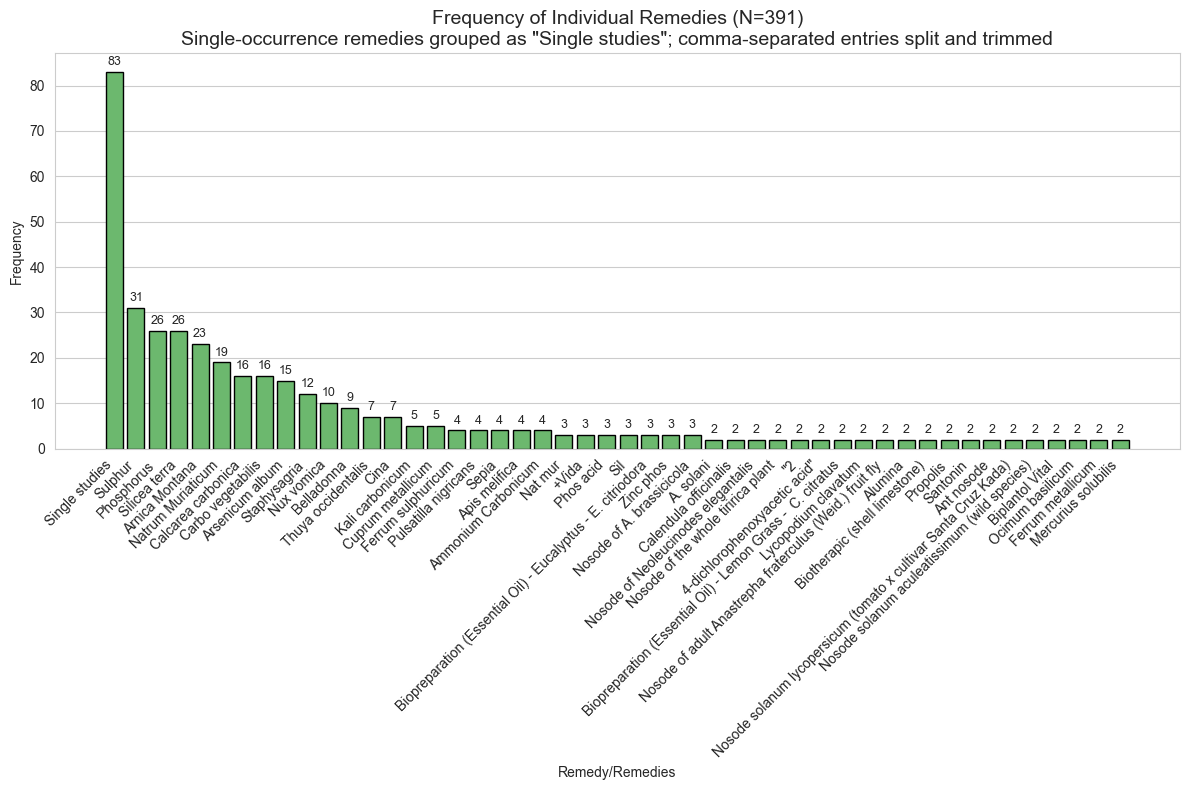

In [327]:
# Title: Frequency of Individual Remedies (with singletons grouped)
# Explanation:
# - This cell analyzes the 'Remedy/remedies ' column where multiple remedies may be listed per study, separated by commas.
# - It splits multi-valued cells, trims whitespace, and replaces empty tokens with 'Blank'.
# - Remedies that occur only once are grouped under a single category called 'Single studies' to simplify the chart.
# - The result is a bar chart showing remedy frequencies, saved as 'remedies_bar.png'.

# 1) Clean and standardize the source column (keep as strings, trim, replace missing)
remedy_series_remedies = (
    df['Remedy/remedies ']
    .fillna('Blank')  # make missing explicit
    .astype(str)  # ensure string type
    .str.strip()  # remove surrounding whitespace
)

# 2) Split comma-separated remedies, explode to one remedy per row, and clean tokens
remedy_exploded_remedies = (
    remedy_series_remedies
    .str.split(',')  # split multiple remedies per study
    .explode()  # one remedy per row
    .astype(str)
    .str.strip()
    .replace({'': 'Blank'})  # guard against empty strings after splitting
)

# 3) Frequency counts by remedy
remedy_counts_remedies = remedy_exploded_remedies.value_counts()

# 4) Group singletons under "Single studies" to avoid a very long tail
lonely_mask_remedies = remedy_counts_remedies == 1
lonely_count_remedies = int(remedy_counts_remedies[lonely_mask_remedies].sum())
grouped_counts_remedies = remedy_counts_remedies[~lonely_mask_remedies].copy()
if lonely_count_remedies > 0:
    grouped_counts_remedies.loc['Single studies'] = lonely_count_remedies

# 5) Sort categories for plotting (descending by frequency)
grouped_counts_remedies = grouped_counts_remedies.sort_values(ascending=False)
total_n_remedies = int(grouped_counts_remedies.sum())  # total number of counted remedy entries

# 6) Create bar plot
fig_remedies, ax_remedies = plt.subplots(figsize=(12, 8))
bars = ax_remedies.bar(
    range(len(grouped_counts_remedies)),
    grouped_counts_remedies.values,
    edgecolor='black'
)

# 7) Axes labels and an informative, two-line title
ax_remedies.set_xticks(range(len(grouped_counts_remedies)))
ax_remedies.set_xticklabels(grouped_counts_remedies.index, rotation=45, ha='right')
ax_remedies.set_xlabel('Remedy/Remedies')
ax_remedies.set_ylabel('Frequency')
ax_remedies.set_title(
    f'Frequency of Individual Remedies (N={total_n_remedies})\n'
    f'Single-occurrence remedies grouped as "Single studies"; '
    f'comma-separated entries split and trimmed',
    fontsize=14
)

# 8) Optional: annotate bars with their counts for readability
for i, v in enumerate(grouped_counts_remedies.values):
    if v > 0:
        ax_remedies.text(i, v + max(grouped_counts_remedies.values) * 0.01, str(v),
                         ha='center', va='bottom', fontsize=9)

# 9) Save and show
ax_remedies.xaxis.grid(False)
plt.tight_layout()
fig_remedies.savefig('remedies_bar.png', dpi=300, bbox_inches='tight')
plt.show()


### Remedies per Study Distribution

In [328]:
# - This cell analyzes how many distinct remedies are listed per study in the column 'Remedy/remedies '.
# - Each row is a study; entries may contain multiple remedies separated by commas.
# - We count remedies per study (0, 1, 2, ...) and visualize the distribution as a pie chart.
# - Labels are shown inside for larger slices and outside (with leader lines) for smaller slices for readability.
# - The chart title includes the total number of studies (N) considered.

def _count_remedies_per_study(cell: str) -> int:
    """
    Count the number of comma-separated remedies in a cell.
    Empty, NaN, or 'N/A' are treated as 0 remedies.
    """
    if pd.isna(cell) or str(cell).strip() in ['', 'N/A']:
        return 0
    parts = [p.strip() for p in str(cell).split(',') if p.strip()]
    return len(parts)


# 1) Compute number of remedies per study and their frequency distribution
remedies_per_study_counts = df['Remedy/remedies '].apply(_count_remedies_per_study)
remedies_per_study_freq = remedies_per_study_counts.value_counts().sort_index()

# 2) Prepare labels and values (grammatically correct singular/plural)
labels_remedies_per_study = [
    f'{count} remedies' if count != 1 else '1 remedy'
    for count in remedies_per_study_freq.index
]
values_remedies_per_study = remedies_per_study_freq.values.tolist()

# 3) Compute percentages and decide label position:
#    - outside for small slices (<9%), inside otherwise
total_remedies_per_study = sum(values_remedies_per_study)  # equals number of studies (N)
percentages_remedies_per_study = [
    (v / total_remedies_per_study) * 100 if total_remedies_per_study else 0
    for v in values_remedies_per_study
]
percentages_cutoff = 9
text_positions_remedies_per_study = [
    'outside' if p < percentages_cutoff else 'inside' for p in percentages_remedies_per_study
]
custom_text_remedies_per_study = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels_remedies_per_study, percentages_remedies_per_study, text_positions_remedies_per_study)
]

# 4) Build the pie chart
remedies_per_study_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_remedies_per_study,
            values=values_remedies_per_study,
            text=custom_text_remedies_per_study,
            textinfo='text',
            textposition=text_positions_remedies_per_study,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

remedies_per_study_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)
 

# 5) Style and title (include N)
remedies_per_study_pie.update_layout(
    title=f'Number of Remedies per Study (N={total_remedies_per_study})',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

# 6) Display and export
remedies_per_study_pie.show()
remedies_per_study_pie.write_image('remedies_per_study_pie.png', width=800, height=600, scale=2)


### Country-Remedy Distribution

Top 20 remedies (excluding N/A and Blank): ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Natrum Muriaticum', 'Calcarea carbonica', 'Carbo vegetabilis', 'Arsenicum album', 'Staphysagria', 'Nux vomica', 'Belladonna', 'Cina', 'Thuya occidentalis', 'Cuprum metallicum', 'Kali carbonicum', 'Ferrum sulphuricum', 'Pulsatilla nigricans', 'Sepia', 'Apis melifica', 'Ammonium Carbonicum']
Created 247 country-remedy combinations


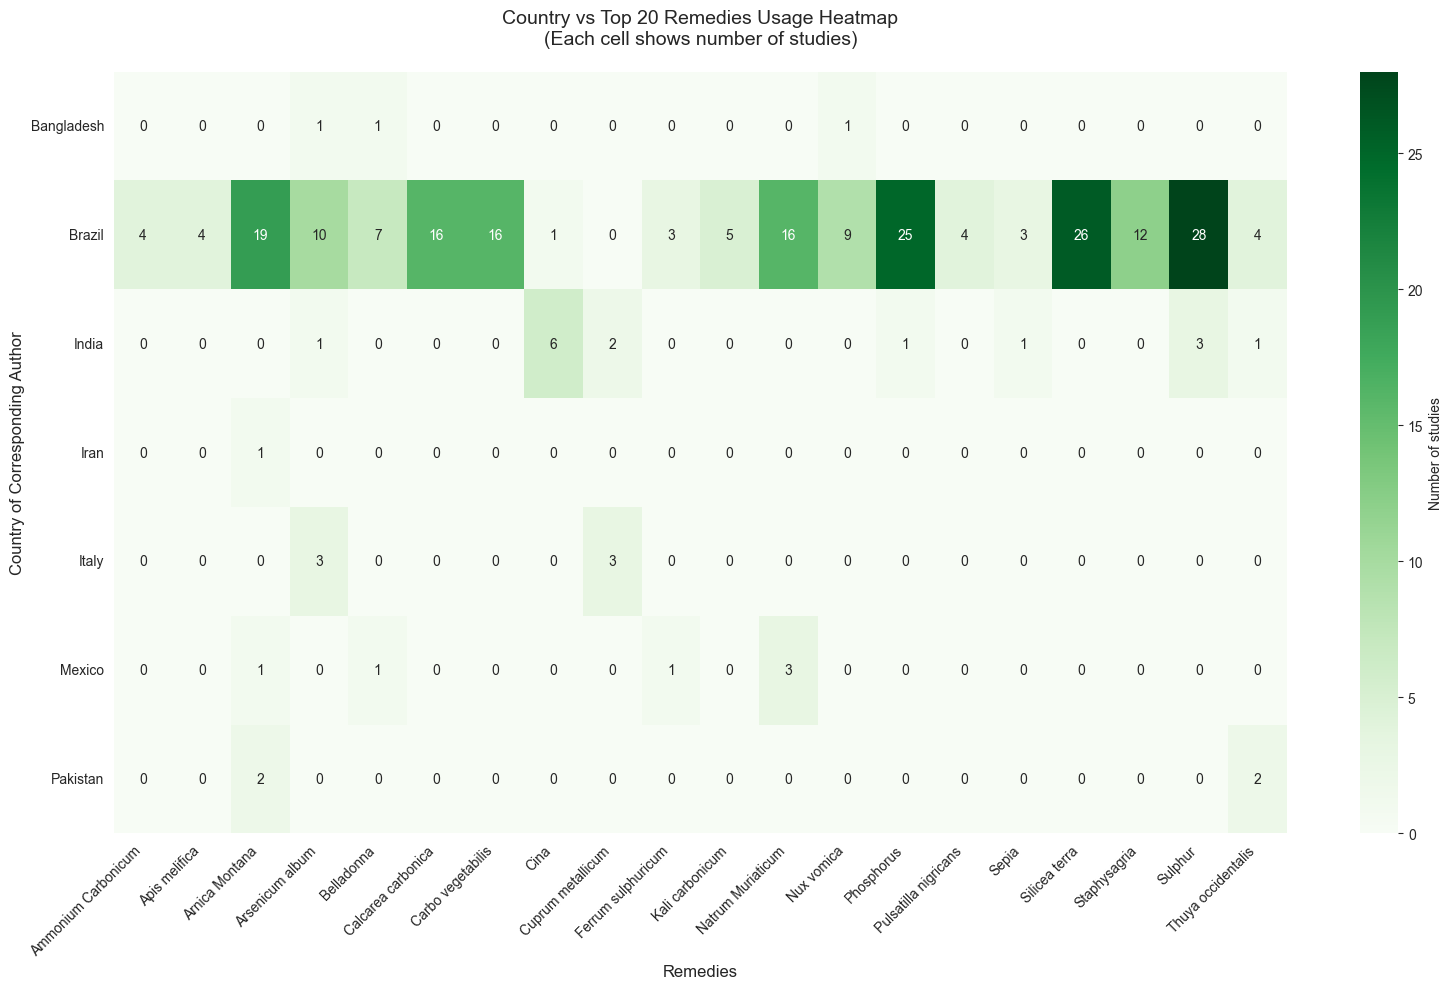

Heatmap includes:
- 7 countries
- 20 remedies (top 20)
- 247 total country-remedy combinations


In [329]:
# There might be a faulty processing of blanks in this part
# Create country-remedy cross-tabulation for heatmap analysis - this analyzes the relationship between corresponding author country and remedy usage
# Clean country data (reuse from earlier analysis)

country_series_heatmap = (
  df['Country of corresponding author']
  .fillna('Blank')
  .astype(str)
  .str.strip()
  .replace({
      'Parkistan': 'Pakistan'  # Fix typo from earlier analysis
  })
)

# Clean and split remedy data (reuse logic from remedy bar chart)
remedy_series_heatmap = (
  df['Remedy/remedies ']
  .fillna('Blank')
  .astype(str)
  .str.strip()
)

# Split comma-separated remedies into individual entries
remedy_exploded_heatmap = (
  remedy_series_heatmap
  .str.split(',')
  .explode()
  .astype(str)
  .str.strip()
  .replace({'': 'Blank'})
)

# Get top 20 most frequent remedies EXCLUDING blanks and N/As
top_remedies = remedy_exploded_heatmap.value_counts().drop(['N/A', 'Blank'], errors='ignore').head(20).index.tolist()
print(f"Top 20 remedies (excluding N/A and Blank): {top_remedies}")  # Debug print

# Create expanded dataframe for cross-tabulation - each row represents one country-remedy combination from the original data
expanded_data = []
for idx in range(len(df)):
  country = country_series_heatmap.iloc[idx]
  remedy_cell = remedy_series_heatmap.iloc[idx]

  # Skip studies with missing remedy data entirely
  if pd.isna(remedy_cell) or str(remedy_cell).strip() in ['', 'N/A', 'Blank']:
      continue  # Skip this study entirely for the heatmap
  else:
      remedies = str(remedy_cell).split(',')

  # Add each remedy from this study as a separate entry
  for remedy in remedies:
      remedy_clean = remedy.strip() if remedy.strip() else 'Blank'
      if remedy_clean in top_remedies:  # Only include top 20 remedies (N/A and Blank already excluded from top_remedies)
          expanded_data.append({'Country': country, 'Remedy': remedy_clean})

print(f"Created {len(expanded_data)} country-remedy combinations")  # Debug print

# Check if we have data before proceeding
if len(expanded_data) == 0:
  print("No data found! Check if remedies match top_remedies list.")
else:
  expanded_df = pd.DataFrame(expanded_data)

  # Create cross-tabulation matrix
  heatmap_matrix = pd.crosstab(expanded_df['Country'], expanded_df['Remedy'])

  # Create heatmap visualization
  fig_heatmap, ax_heatmap = plt.subplots(figsize=(16, 10))

  # Use seaborn for a professional heatmap
  import seaborn as sns
  sns.heatmap(
      heatmap_matrix,
      annot=True,  # Show numbers in cells
      fmt='d',     # Integer format
      cmap='Greens',  # Color scheme (yellow to orange to red)
      ax=ax_heatmap,
      cbar_kws={'label': 'Number of studies'}
  )

  # Customize the plot
  ax_heatmap.set_title('Country vs Top 20 Remedies Usage Heatmap\n(Each cell shows number of studies)', fontsize=14, pad=20)
  ax_heatmap.set_xlabel('Remedies', fontsize=12)
  ax_heatmap.set_ylabel('Country of Corresponding Author', fontsize=12)

  # Center ticks and labels in the middle of each cell (heatmap cells are 0.5, 1.5, 2.5, etc.)
  ax_heatmap.set_xticks([i + 0.5 for i in range(len(heatmap_matrix.columns))])
  ax_heatmap.set_xticklabels(heatmap_matrix.columns, rotation=45, ha='right')
  ax_heatmap.set_yticks([i + 0.5 for i in range(len(heatmap_matrix.index))])
  ax_heatmap.set_yticklabels(heatmap_matrix.index, rotation=0)

  # Save and display
  plt.tight_layout()
  fig_heatmap.savefig('country_remedy_heatmap.png', dpi=300, bbox_inches='tight')
  plt.show()

  # Print summary statistics
  print(f"Heatmap includes:")
  print(f"- {len(heatmap_matrix.index)} countries")
  print(f"- {len(heatmap_matrix.columns)} remedies (top 20)")
  print(f"- {heatmap_matrix.values.sum()} total country-remedy combinations")



In [330]:
# # Create hierarchical clustered heatmap with country normalization
# # Normalize each country (row) so values represent proportion of that country's total remedy usage
#
# # Normalize the heatmap matrix by row (each country's values sum to 1)
# heatmap_normalized = heatmap_matrix.div(heatmap_matrix.sum(axis=1), axis=0)
#
# # Replace any NaN values (from countries with no remedies) with 0
# heatmap_normalized = heatmap_normalized.fillna(0)
#
# # Create clustered heatmap with hierarchical clustering on both axes
#
# # Create the clustermap (hierarchical clustering on both rows and columns)
# clustered_fig = sns.clustermap(
#     heatmap_normalized,
#     cmap='Greens',
#     annot=True,  # Show values in cells
#     fmt='.2f',   # Format as proportion with 2 decimal places
#     figsize=(16, 10),
#     cbar_kws={'label': 'Proportion of country total'},
#     linewidths=0.5,
#     linecolor='white',
#     method='average',  # Linkage method for hierarchical clustering
#     metric='euclidean'  # Distance metric
# )
#
# # Customize the plot title
# clustered_fig.fig.suptitle(
#     'Country vs Top 20 Remedies - Hierarchical Clustering (Normalized by Country)\n(Each cell shows proportion of that country\'s total remedy usage)',
#     fontsize=14,
#     y=0.98
# )
#
# # Adjust layout and save
# plt.tight_layout()
# clustered_fig.savefig('country_remedy_heatmap_clustered_normalized.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# # Print summary
# print(f"\nClustered heatmap created:")
# print(f"- Hierarchical clustering applied to both countries and remedies")
# print(f"- Each row normalized to show proportion of that country's total")
# print(f"- Values range from 0.00 to 1.00 (0% to 100%)")


### Remedy Co-occurrence Patterns

Found 94 studies with multiple remedies
Top 15 remedies in multi-remedy studies: ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Carbo vegetabilis', 'Calcarea carbonica', 'Arsenicum album', 'Natrum Muriaticum', 'Staphysagria', 'Belladonna', 'Nux vomica', 'Thuya occidentalis', 'Cuprum metallicum', 'Apis melifica', 'Kali carbonicum']


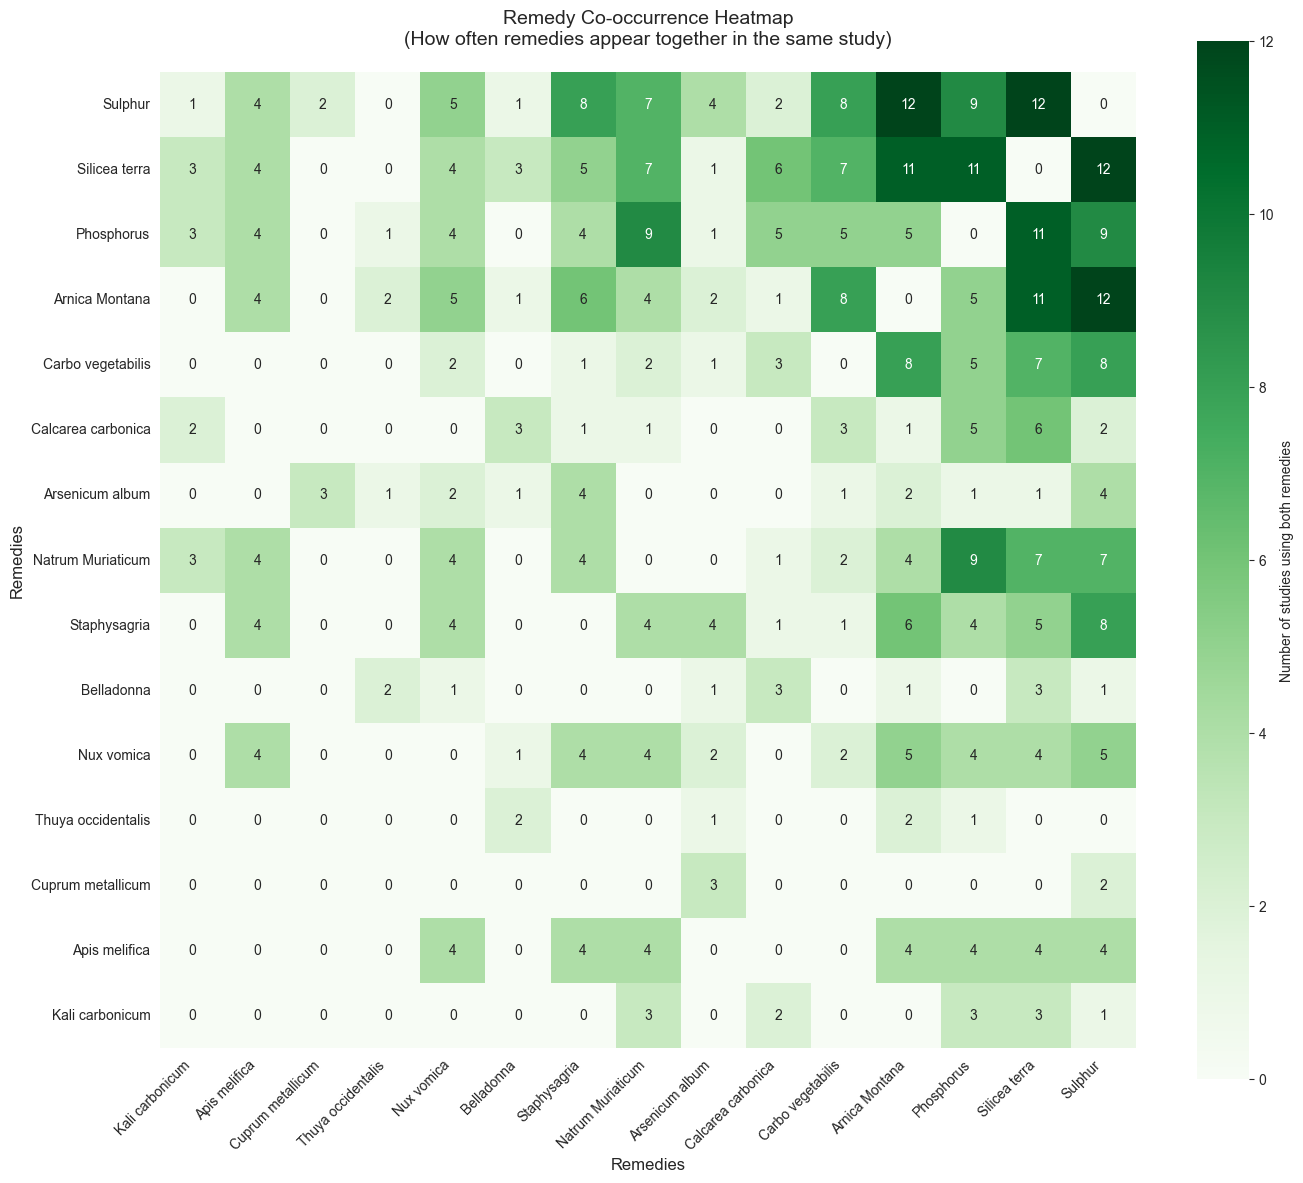

Co-occurrence heatmap includes:
- 15 top remedies from multi-remedy studies
- 94 studies with multiple remedies
- 268 total remedy pair co-occurrences

Top 10 remedy co-occurrences:
- Sulphur + Arnica Montana: 12 studies
- Sulphur + Silicea terra: 12 studies
- Silicea terra + Sulphur: 12 studies
- Arnica Montana + Sulphur: 12 studies
- Silicea terra + Arnica Montana: 11 studies
- Silicea terra + Phosphorus: 11 studies
- Phosphorus + Silicea terra: 11 studies
- Arnica Montana + Silicea terra: 11 studies
- Sulphur + Phosphorus: 9 studies
- Phosphorus + Natrum Muriaticum: 9 studies


In [331]:
  # Create remedy co-occurrence heatmap analysis - this shows which remedies are frequently used together in the same studies

  # Clean and split remedy data (reuse logic from earlier)
  remedy_series_cooccur = (
      df['Remedy/remedies ']
      .fillna('N/A')
      .astype(str)
      .str.strip()
  )

  # Get studies with multiple remedies only
  multi_remedy_studies = []
  for idx in range(len(df)):
      remedy_cell = remedy_series_cooccur.iloc[idx]

      # Handle NaN and empty values
      if pd.isna(remedy_cell) or str(remedy_cell).strip() in ['', 'N/A']:
          continue

      # Split remedies and clean them
      remedies = [r.strip() for r in str(remedy_cell).split(',') if r.strip()]

      # Only include studies with 2 or more remedies
      if len(remedies) > 1:
          multi_remedy_studies.append(remedies)

  print(f"Found {len(multi_remedy_studies)} studies with multiple remedies")

  # Get top remedies from multi-remedy studies to focus the heatmap
  all_remedies_multi = []
  for study_remedies in multi_remedy_studies:
      all_remedies_multi.extend(study_remedies)

  # Get top 15 most frequent remedies in multi-remedy studies (smaller number for readability)
  top_remedies_cooccur = pd.Series(all_remedies_multi).value_counts().head(15).index.tolist()
  print(f"Top 15 remedies in multi-remedy studies: {top_remedies_cooccur}")

  # Create co-occurrence matrix - count how often each pair appears together
  import numpy as np
  cooccur_matrix = pd.DataFrame(0, index=top_remedies_cooccur, columns=top_remedies_cooccur)

  # Fill the co-occurrence matrix
  for study_remedies in multi_remedy_studies:
      # Filter to only include top remedies
      study_top_remedies = [r for r in study_remedies if r in top_remedies_cooccur]

      # For each pair of remedies in this study, increment the count
      for i, remedy1 in enumerate(study_top_remedies):
          for j, remedy2 in enumerate(study_top_remedies):
              if i != j:  # Don't count a remedy with itself
                  cooccur_matrix.loc[remedy1, remedy2] += 1

  # Make the matrix symmetric (if A appears with B, then B appears with A)
  cooccur_matrix = (cooccur_matrix + cooccur_matrix.T) // 2

  # Flip the column order to reverse the x-axis and move mirror line to opposite diagonal
  cooccur_matrix = cooccur_matrix[cooccur_matrix.columns[::-1]]

  # Create heatmap visualization
  fig_cooccur, ax_cooccur = plt.subplots(figsize=(14, 12))

  # Use seaborn for professional heatmap
  import seaborn as sns
  sns.heatmap(
      cooccur_matrix,
      annot=True,  # Show numbers in cells
      fmt='d',     # Integer format
      cmap='Greens',  # Blue color scheme for co-occurrence
      ax=ax_cooccur,
      cbar_kws={'label': 'Number of studies using both remedies'},
      square=True  # Make cells square for better symmetry visualization
  )

  # Center ticks and labels in the middle of each cell
  ax_cooccur.set_xticks([i + 0.5 for i in range(len(cooccur_matrix.columns))])
  ax_cooccur.set_xticklabels(cooccur_matrix.columns, rotation=45, ha='right')
  ax_cooccur.set_yticks([i + 0.5 for i in range(len(cooccur_matrix.index))])
  ax_cooccur.set_yticklabels(cooccur_matrix.index, rotation=0)

  # Customize the plot
  ax_cooccur.set_title('Remedy Co-occurrence Heatmap\n(How often remedies appear together in the same study)', fontsize=14, pad=20)
  ax_cooccur.set_xlabel('Remedies', fontsize=12)
  ax_cooccur.set_ylabel('Remedies', fontsize=12)

  # Save and display
  plt.tight_layout()
  fig_cooccur.savefig('remedy_cooccurrence_heatmap.png', dpi=300, bbox_inches='tight')
  plt.show()

  # Print summary statistics
  total_cooccurrences = cooccur_matrix.values.sum() // 2  # Divide by 2 since matrix is symmetric
  print(f"Co-occurrence heatmap includes:")
  print(f"- {len(cooccur_matrix.index)} top remedies from multi-remedy studies")
  print(f"- {len(multi_remedy_studies)} studies with multiple remedies")
  print(f"- {total_cooccurrences} total remedy pair co-occurrences")

  # Show top co-occurring pairs
  cooccur_pairs = []
  for i in range(len(cooccur_matrix)):
      for j in range(i+1, len(cooccur_matrix)):  # Only upper triangle to avoid duplicates
          remedy1 = cooccur_matrix.index[i]
          remedy2 = cooccur_matrix.columns[j]
          count = cooccur_matrix.iloc[i, j]
          if count > 0:
              cooccur_pairs.append((remedy1, remedy2, count))

  cooccur_pairs.sort(key=lambda x: x[2], reverse=True)
  print(f"\nTop 10 remedy co-occurrences:")
  for remedy1, remedy2, count in cooccur_pairs[:10]:
      print(f"- {remedy1} + {remedy2}: {count} studies")



### Remedy-Crop Relationships

Top 20 remedies: ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Natrum Muriaticum', 'Calcarea carbonica', 'Carbo vegetabilis', 'Arsenicum album', 'Staphysagria', 'Nux vomica', 'Belladonna', 'Cina', 'Thuya occidentalis', 'Cuprum metallicum', 'Kali carbonicum', 'Ferrum sulphuricum', 'Pulsatilla nigricans', 'Sepia', 'Apis melifica', 'Ammonium Carbonicum']
Top 20 crops: ['Tomato', 'Bean', 'Soybean', 'Onion', 'Lettuce', 'Mulberry', 'Strawberry', 'Chamomile', 'Cabbage', 'Tiririca', 'Artemisia', 'Cowpea', 'Cauliflower', 'Carqueja', 'Guamxuma', 'Grapewine', 'Fig', 'Naranjilla', 'Sisal', 'Broccoli']
Created 145 remedy-crop combinations


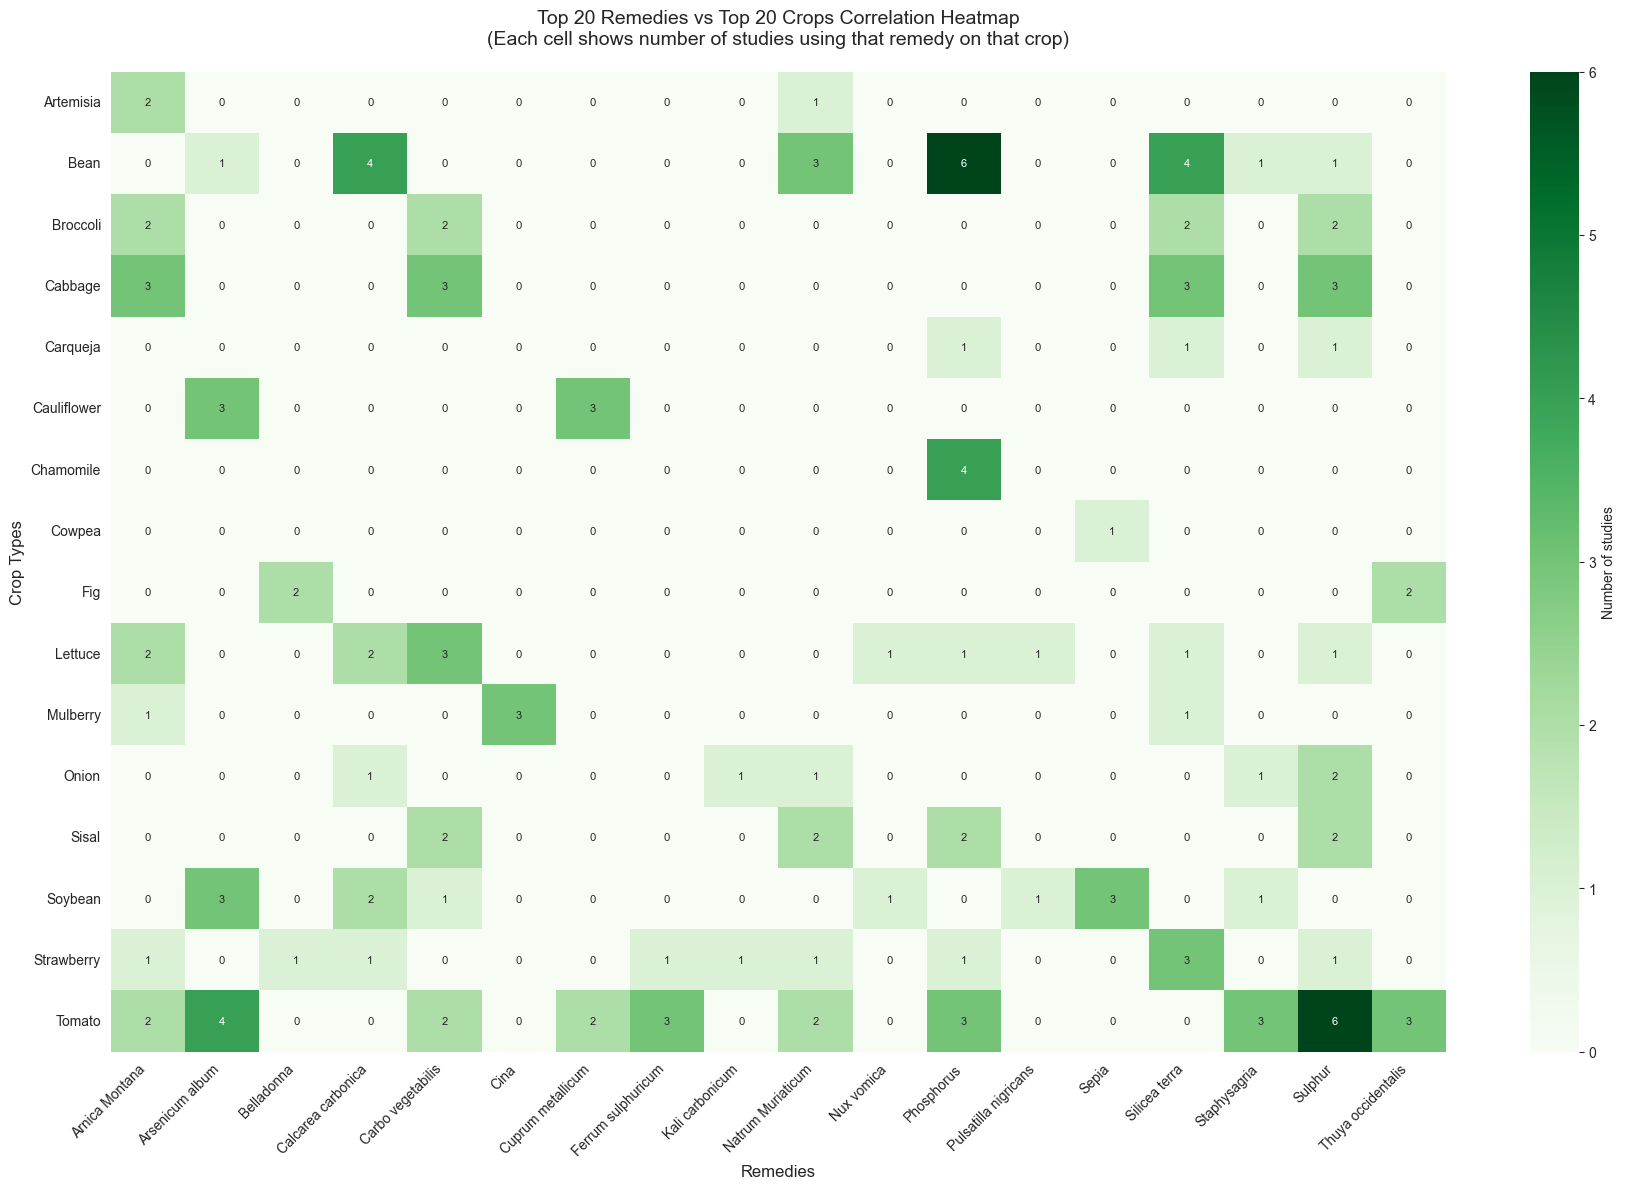

Remedy-crop correlation heatmap includes:
- 16 crop types (top 20)
- 18 remedies (top 20)
- 145 total remedy-crop study combinations

Top 10 remedy-crop combinations:
- Phosphorus on Bean: 6 studies
- Sulphur on Tomato: 6 studies
- Calcarea carbonica on Bean: 4 studies
- Silicea terra on Bean: 4 studies
- Phosphorus on Chamomile: 4 studies
- Arsenicum album on Tomato: 4 studies
- Natrum Muriaticum on Bean: 3 studies
- Arnica Montana on Cabbage: 3 studies
- Carbo vegetabilis on Cabbage: 3 studies
- Silicea terra on Cabbage: 3 studies


In [332]:
  # Cross-Category Heatmap: Top 20 Remedies vs Top 20 Crops
  # This code creates a heatmap showing which remedies are used on which crop types. We'll focus on the top 20 most frequent remedies and top 20 most frequent crops to identify patterns in remedy-crop combinations.

  # Create remedy-crop cross-correlation heatmap analysis - this shows which remedies are used on which crop types

  # Clean remedy data (reuse logic from earlier)
  remedy_series_crop = (
      df['Remedy/remedies ']
      .fillna('N/A')
      .astype(str)
      .str.strip()
  )

  # Split comma-separated remedies into individual entries
  remedy_exploded_crop = (
      remedy_series_crop
      .str.split(',')
      .explode()
      .astype(str)
      .str.strip()
      .replace({'': 'Blank'})
  )

  # Clean crop data (reuse logic from crop analysis)
  crop_series_remedy = (
      df['Crop type studied']
      .fillna('N/A')
      .astype(str)
      .str.strip()
  )

  # Get top 20 remedies and top 20 crops (excluding N/A entries for meaningful analysis - this exclusion is only needed for preliminary data exploration)
  top_20_remedies = remedy_exploded_crop.value_counts().drop(['N/A', 'Blank'], errors='ignore').head(20).index.tolist()
  top_20_crops = crop_series_remedy.value_counts().drop(['N/A', 'Blank'], errors='ignore').head(20).index.tolist()

  print(f"Top 20 remedies: {top_20_remedies}")
  print(f"Top 20 crops: {top_20_crops}")

  # Create expanded dataframe for cross-tabulation - each row represents one remedy-crop combination from the original data
  expanded_remedy_crop = []
  for idx in range(len(df)):
      crop = crop_series_remedy.iloc[idx]
      remedy_cell = remedy_series_crop.iloc[idx]

      # Skip if crop is not in top 20 or is N/A
      if crop not in top_20_crops or crop == 'N/A':
          continue

      # Handle remedy NaN and empty values
      if pd.isna(remedy_cell) or str(remedy_cell).strip() in ['', 'N/A']:
          continue  # Skip N/A remedies for this analysis
      else:
          remedies = str(remedy_cell).split(',')

      # Add each remedy from this study as a separate entry
      for remedy in remedies:
          remedy_clean = remedy.strip() if remedy.strip() else 'Blank'
          if remedy_clean in top_20_remedies and remedy_clean not in ['N/A', 'Blank']:  # Only include top 20 remedies, exclude N/A
              expanded_remedy_crop.append({'Crop': crop, 'Remedy': remedy_clean})

  print(f"Created {len(expanded_remedy_crop)} remedy-crop combinations")

  # Check if we have data before proceeding
  if len(expanded_remedy_crop) == 0:
      print("No data found! Check if remedies and crops match top lists.")
  else:
      expanded_remedy_crop_df = pd.DataFrame(expanded_remedy_crop)

      # Create cross-tabulation matrix (crops as rows, remedies as columns)
      remedy_crop_matrix = pd.crosstab(expanded_remedy_crop_df['Crop'], expanded_remedy_crop_df['Remedy'])

      # Create heatmap visualization
      fig_remedy_crop, ax_remedy_crop = plt.subplots(figsize=(18, 12))

      # Use seaborn for professional heatmap
      import seaborn as sns
      sns.heatmap(
          remedy_crop_matrix,
          annot=True,  # Show numbers in cells
          fmt='d',     # Integer format
          cmap='Greens',  # Green color scheme for crop-remedy correlation
          ax=ax_remedy_crop,
          cbar_kws={'label': 'Number of studies'},
          annot_kws={'size': 8}  # Smaller annotation text due to large matrix
      )

      # Center ticks and labels in the middle of each cell
      ax_remedy_crop.set_xticks([i + 0.5 for i in range(len(remedy_crop_matrix.columns))])
      ax_remedy_crop.set_xticklabels(remedy_crop_matrix.columns, rotation=45, ha='right')
      ax_remedy_crop.set_yticks([i + 0.5 for i in range(len(remedy_crop_matrix.index))])
      ax_remedy_crop.set_yticklabels(remedy_crop_matrix.index, rotation=0)

      # Customize the plot
      ax_remedy_crop.set_title('Top 20 Remedies vs Top 20 Crops Correlation Heatmap\n(Each cell shows number of studies using that remedy on that crop)', fontsize=14, pad=20)
      ax_remedy_crop.set_xlabel('Remedies', fontsize=12)
      ax_remedy_crop.set_ylabel('Crop Types', fontsize=12)

      # Save and display
      plt.tight_layout()
      fig_remedy_crop.savefig('remedy_crop_correlation_heatmap.png', dpi=300, bbox_inches='tight')
      plt.show()

      # Print summary statistics
      total_combinations = remedy_crop_matrix.values.sum()
      print(f"Remedy-crop correlation heatmap includes:")
      print(f"- {len(remedy_crop_matrix.index)} crop types (top 20)")
      print(f"- {len(remedy_crop_matrix.columns)} remedies (top 20)")
      print(f"- {total_combinations} total remedy-crop study combinations")

      # Extract and rank all remedy-crop combinations from the matrix for summary analysis
      remedy_crop_pairs = []
      # Loop through each row (crop) in the matrix
      for i in range(len(remedy_crop_matrix)):
          # Loop through each column (remedy) in the matrix
          for j in range(len(remedy_crop_matrix.columns)):
              crop = remedy_crop_matrix.index[i]  # Get crop name from row index
              remedy = remedy_crop_matrix.columns[j]  # Get remedy name from column index
              count = remedy_crop_matrix.iloc[i, j]  # Get the count value from this cell
              if count > 0:  # Only include combinations that actually occurred
                  remedy_crop_pairs.append((crop, remedy, count))

      # Sort by count (highest first) to show most frequent combinations
      remedy_crop_pairs.sort(key=lambda x: x[2], reverse=True)
      print(f"\nTop 10 remedy-crop combinations:")
      for crop, remedy, count in remedy_crop_pairs[:10]:
          print(f"- {remedy} on {crop}: {count} studies")



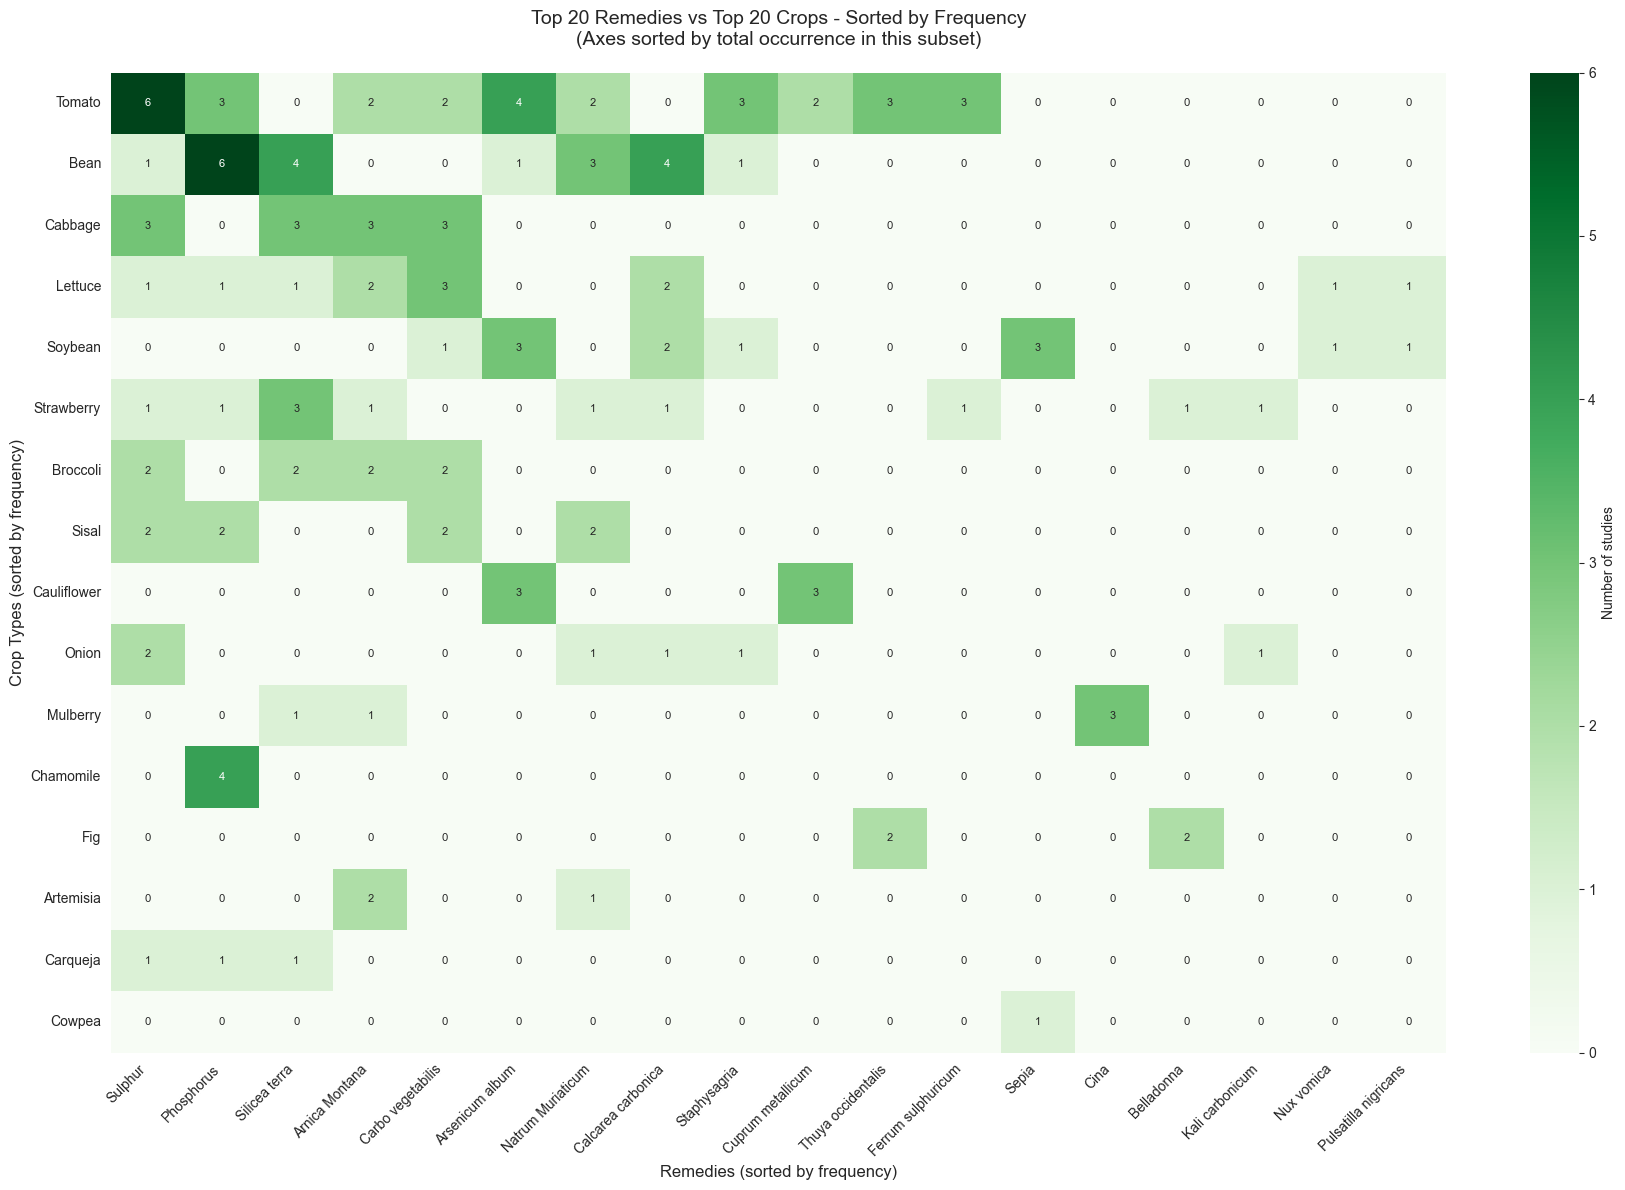


Crop frequency ranking (in top 20 subset):
1. Tomato: 30 studies
2. Bean: 20 studies
3. Cabbage: 12 studies
4. Lettuce: 12 studies
5. Soybean: 12 studies
6. Strawberry: 11 studies
7. Broccoli: 8 studies
8. Sisal: 8 studies
9. Cauliflower: 6 studies
10. Onion: 6 studies
11. Mulberry: 5 studies
12. Chamomile: 4 studies
13. Fig: 4 studies
14. Artemisia: 3 studies
15. Carqueja: 3 studies
16. Cowpea: 1 studies

Remedy frequency ranking (in top 20 subset):
1. Sulphur: 19 studies
2. Phosphorus: 18 studies
3. Silicea terra: 15 studies
4. Arnica Montana: 13 studies
5. Carbo vegetabilis: 13 studies
6. Arsenicum album: 11 studies
7. Natrum Muriaticum: 10 studies
8. Calcarea carbonica: 10 studies
9. Staphysagria: 6 studies
10. Cuprum metallicum: 5 studies
11. Thuya occidentalis: 5 studies
12. Ferrum sulphuricum: 4 studies
13. Sepia: 4 studies
14. Cina: 3 studies
15. Belladonna: 3 studies
16. Kali carbonicum: 2 studies
17. Nux vomica: 2 studies
18. Pulsatilla nigricans: 2 studies


In [333]:
# Create frequency-sorted version of remedy-crop heatmap
# Both axes sorted by total occurrence in the top 20 subset

# Sort crops (rows) by total frequency across all remedies
crop_totals = remedy_crop_matrix.sum(axis=1).sort_values(ascending=False)
sorted_crops = crop_totals.index.tolist()

# Sort remedies (columns) by total frequency across all crops
remedy_totals = remedy_crop_matrix.sum(axis=0).sort_values(ascending=False)
sorted_remedies = remedy_totals.index.tolist()

# Reindex the matrix with sorted axes
remedy_crop_sorted = remedy_crop_matrix.loc[sorted_crops, sorted_remedies]

# Create heatmap visualization
fig_sorted, ax_sorted = plt.subplots(figsize=(18, 12))

sns.heatmap(
    remedy_crop_sorted,
    annot=True,  # Show numbers in cells
    fmt='d',     # Integer format
    cmap='Greens',  # Green color scheme
    ax=ax_sorted,
    cbar_kws={'label': 'Number of studies'},
    annot_kws={'size': 8}  # Smaller annotation text
)

# Center ticks and labels
ax_sorted.set_xticks([i + 0.5 for i in range(len(remedy_crop_sorted.columns))])
ax_sorted.set_xticklabels(remedy_crop_sorted.columns, rotation=45, ha='right')
ax_sorted.set_yticks([i + 0.5 for i in range(len(remedy_crop_sorted.index))])
ax_sorted.set_yticklabels(remedy_crop_sorted.index, rotation=0)

# Customize the plot
ax_sorted.set_title(
    'Top 20 Remedies vs Top 20 Crops - Sorted by Frequency\n(Axes sorted by total occurrence in this subset)',
    fontsize=14,
    pad=20
)
ax_sorted.set_xlabel('Remedies (sorted by frequency)', fontsize=12)
ax_sorted.set_ylabel('Crop Types (sorted by frequency)', fontsize=12)

# Save and display
plt.tight_layout()
fig_sorted.savefig('remedy_crop_correlation_heatmap_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

# Print frequency rankings
print(f"\nCrop frequency ranking (in top 20 subset):")
for i, (crop, count) in enumerate(crop_totals.items(), 1):
    print(f"{i}. {crop}: {count} studies")

print(f"\nRemedy frequency ranking (in top 20 subset):")
for i, (remedy, count) in enumerate(remedy_totals.items(), 1):
    print(f"{i}. {remedy}: {count} studies")


## Potency Analysis

### Potency Level Distribution

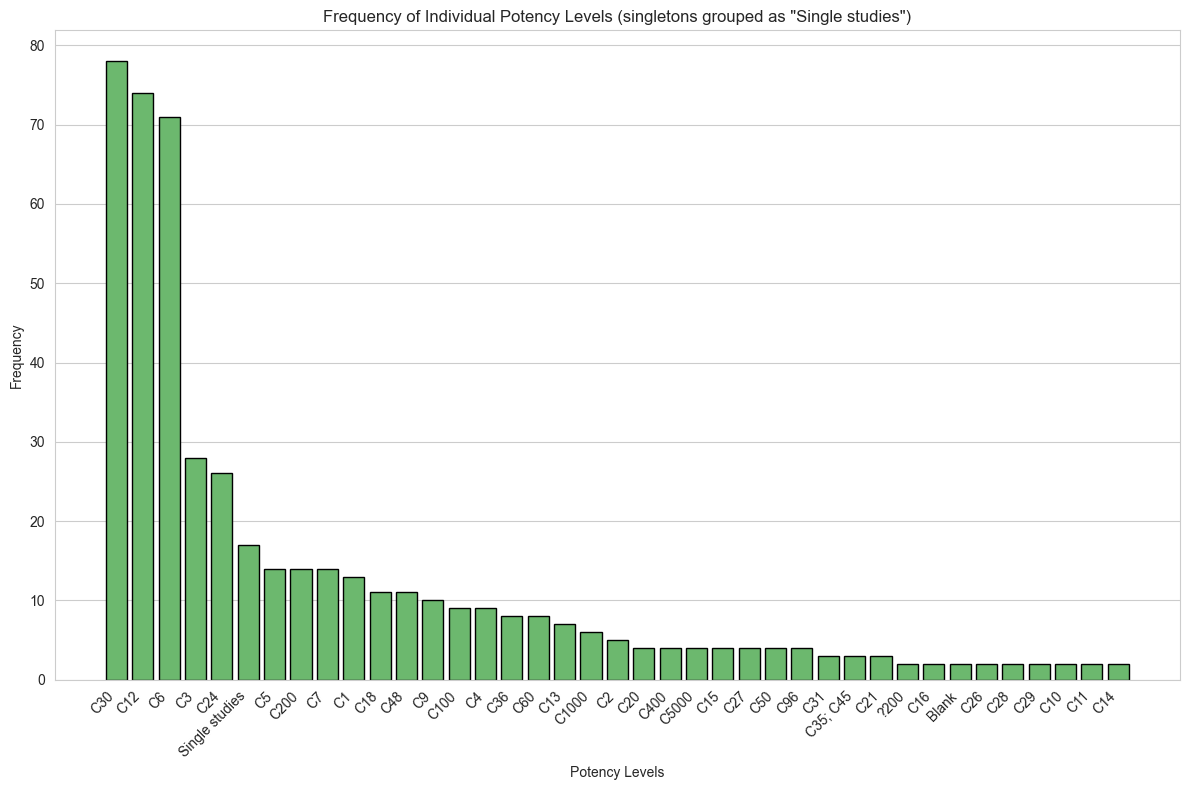

In [334]:
# Potency Levels Bar Chart Analysis

# This code analyzes the distribution of homeopathic potency levels used in studies. We'll split comma-separated entries, group singletons as "Single studies", and create a bar chart showing frequency of each potency level.

# Create potency levels frequency analysis with comma separation and singleton grouping - this shows which potency levels are most commonly used in studies

# Clean and split the 'Potency levels' column on commas
potency_series_levels = (
    df['Potency levels']
    .fillna('Blank')
    .astype(str)
    .str.strip()
)

# Split on comma, explode into individual entries, and clean up
potency_exploded_levels = (
    potency_series_levels
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'Blank'})
)

# Get frequency counts
potency_counts_levels = potency_exploded_levels.value_counts()

# Group all singletons under "Single studies"
lonely_mask_levels = potency_counts_levels == 1
lonely_count_levels = int(potency_counts_levels[lonely_mask_levels].sum())
grouped_counts_levels = potency_counts_levels[~lonely_mask_levels].copy()

if lonely_count_levels > 0:
    grouped_counts_levels.loc['Single studies'] = lonely_count_levels

# Sort for plotting
grouped_counts_levels = grouped_counts_levels.sort_values(ascending=False)

# Create bar plot using matplotlib directly for proper axis alignment
fig_levels, ax_levels = plt.subplots(figsize=(12, 8))
bars = ax_levels.bar(range(len(grouped_counts_levels)), grouped_counts_levels.values, edgecolor='black')
ax_levels.set_xticks(range(len(grouped_counts_levels)))
ax_levels.set_xticklabels(grouped_counts_levels.index, rotation=45, ha='right')
ax_levels.set_xlabel('Potency Levels')
ax_levels.set_ylabel('Frequency')
ax_levels.set_title('Frequency of Individual Potency Levels (singletons grouped as "Single studies")')

# Save and show
ax_levels.xaxis.grid(False)
plt.tight_layout()
fig_levels.savefig('potency_levels_bar.png', dpi=300, bbox_inches='tight')
plt.show()


In [335]:

# Count how many potency levels each study (row) has before comma separation
def _count_potency_levels_per_study(cell: str) -> int:
    if pd.isna(cell) or str(cell).strip() in ['', 'N/A']:
        return 0
    parts = [p.strip() for p in str(cell).split(',') if p.strip()]
    return len(parts)


potency_levels_per_study_counts = df['Potency levels'].apply(_count_potency_levels_per_study)
potency_levels_per_study_freq = potency_levels_per_study_counts.value_counts().sort_index()

# Prepare data for pie chart
labels_potency_levels_per_study = [f'{count} potency levels' if count != 1 else '1 potency level' for count in
                                   potency_levels_per_study_freq.index]
values_potency_levels_per_study = potency_levels_per_study_freq.values.tolist()

# Compute percentages and set label positions
total_potency_levels_per_study = sum(values_potency_levels_per_study)
percentages_potency_levels_per_study = [
    (v / total_potency_levels_per_study) * 100 if total_potency_levels_per_study else 0 for v in
    values_potency_levels_per_study]
percentages_cutoff = 10
text_positions_potency_levels_per_study = ['outside' if p < percentages_cutoff else 'inside' for p in
                                           percentages_potency_levels_per_study]
custom_text_potency_levels_per_study = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in
    zip(labels_potency_levels_per_study, percentages_potency_levels_per_study, text_positions_potency_levels_per_study)
]

# Build pie chart (styled like the "Country of corresponding author" chart)
potency_levels_per_study_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_potency_levels_per_study,
            values=values_potency_levels_per_study,
            text=custom_text_potency_levels_per_study,
            textinfo='text',
            textposition=text_positions_potency_levels_per_study,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

potency_levels_per_study_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=12, color='black'),
potency_levels_per_study_pie.update_layout(
    title='Number of potency levels per study',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

potency_levels_per_study_pie.show()
potency_levels_per_study_pie.write_image('potency_levels_per_study_pie.png', width=800, height=600, scale=2)


### Remedy-Potency Relationships

Top 20 remedies: ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Natrum Muriaticum', 'Calcarea carbonica', 'Carbo vegetabilis', 'Arsenicum album', 'Staphysagria', 'Nux vomica', 'Belladonna', 'Cina', 'Thuya occidentalis', 'Cuprum metallicum', 'Kali carbonicum', 'Ferrum sulphuricum', 'Pulsatilla nigricans', 'Sepia', 'Apis melifica', 'Ammonium Carbonicum']
Top 20 potency levels: ['C30', 'C12', 'C6', 'C3', 'C24', 'C200', 'C5', 'C7', 'C1', 'C18', 'C48', 'C9', 'C100', 'C4', 'C60', 'C36', 'C13', 'C1000', 'C2', 'C96']
Created 677 remedy-potency combinations


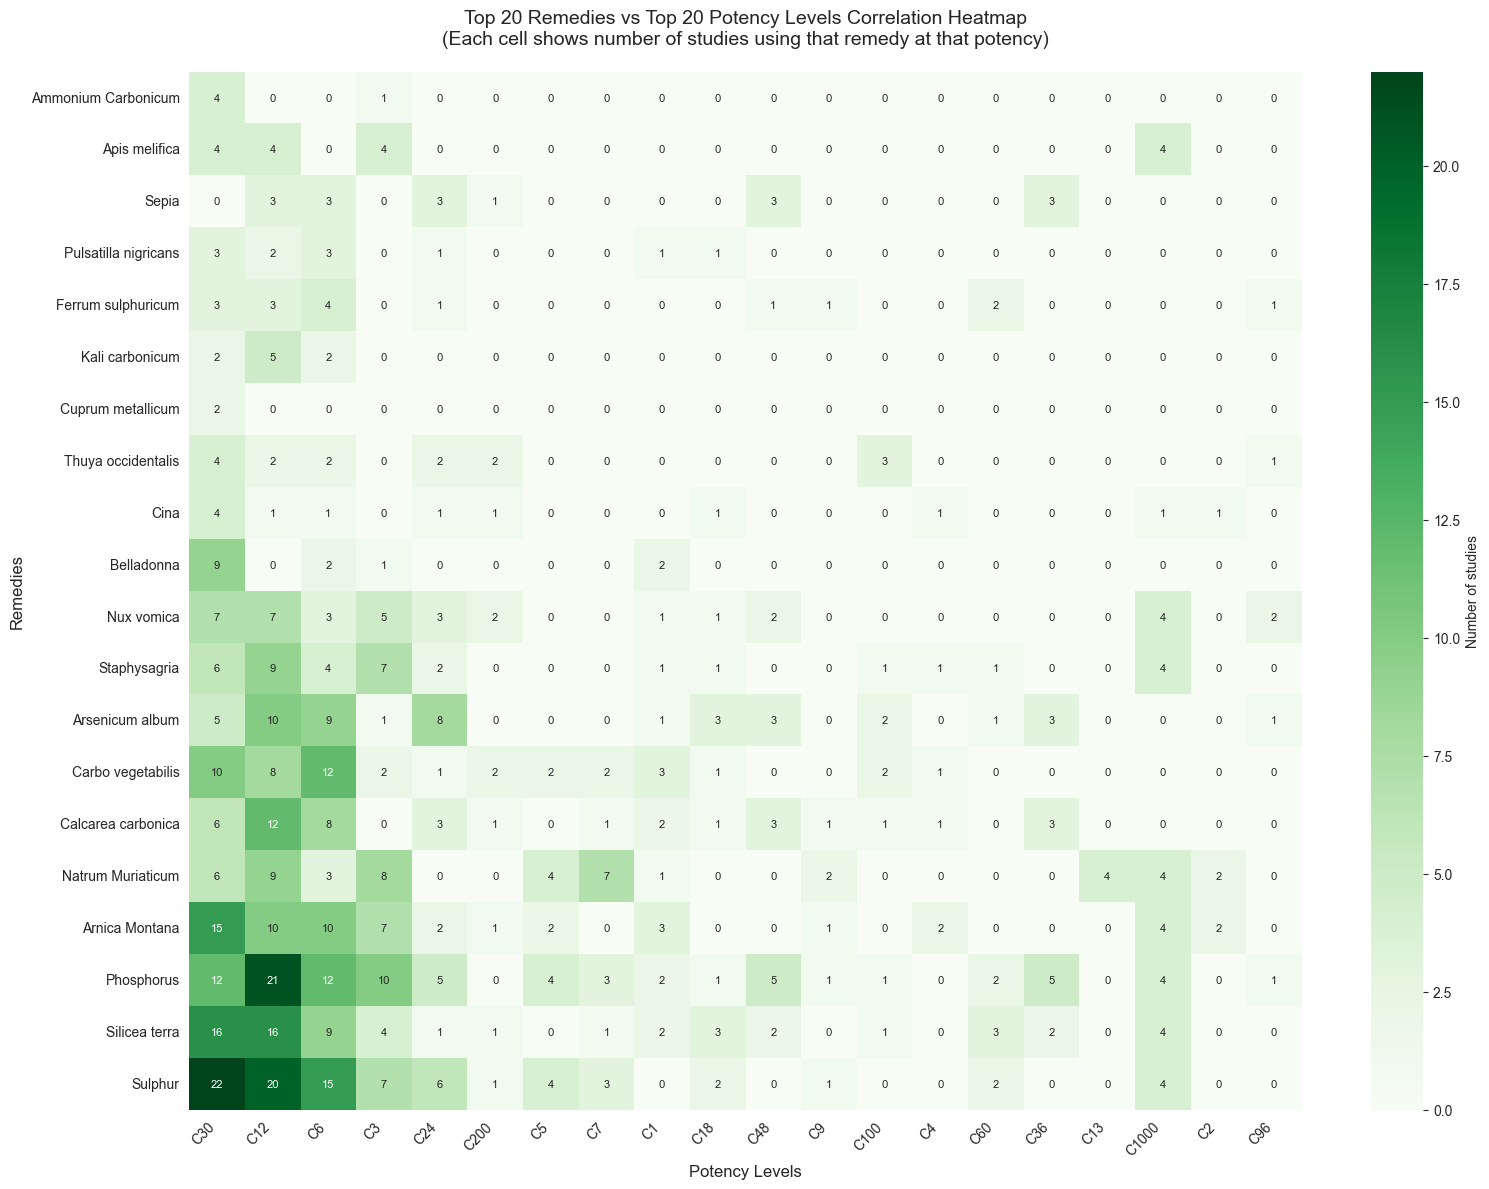

Remedy-potency correlation heatmap includes:
- 20 remedies (top 20)
- 20 potency levels (top 20)
- 677 total remedy-potency study combinations

Top 10 remedy-potency combinations:
- Sulphur at C30: 22 studies
- Phosphorus at C12: 21 studies
- Sulphur at C12: 20 studies
- Silicea terra at C30: 16 studies
- Silicea terra at C12: 16 studies
- Arnica Montana at C30: 15 studies
- Sulphur at C6: 15 studies
- Carbo vegetabilis at C6: 12 studies
- Calcarea carbonica at C12: 12 studies
- Phosphorus at C30: 12 studies


In [336]:
# Cross-Category Heatmap: Top 20 Remedies vs Top 20 Potency Levels

# This code creates a heatmap showing which potency levels are used with which remedies. We'll focus on the top 20 most frequent remedies and top 20 most frequent potency levels to identify patterns in remedy-potency combinations.

# Create remedy-potency cross-correlation heatmap analysis - this shows which potency levels are used with which remedies

# Clean remedy data (reuse logic from earlier)
remedy_series_potency = (
  df['Remedy/remedies ']
  .fillna('Blank')
  .astype(str)
  .str.strip()
)

# Split comma-separated remedies into individual entries
remedy_exploded_potency = (
  remedy_series_potency
  .str.split(',')
  .explode()
  .astype(str)
  .str.strip()
  .replace({'': 'Blank'})
)

# Clean potency data (reuse logic from potency analysis)
potency_series_remedy = (
  df['Potency levels']
  .fillna('Blank')
  .astype(str)
  .str.strip()
)

# Split comma-separated potencies into individual entries
potency_exploded_remedy = (
  potency_series_remedy
  .str.split(',')
  .explode()
  .astype(str)
  .str.strip()
  .replace({'': 'Blank'})
)

# Get top 20 remedies and top 20 potency levels (excluding N/A entries for meaningful analysis - this exclusion is only needed for preliminary data exploration)
top_20_remedies_potency = remedy_exploded_potency.value_counts().drop('N/A', errors='ignore').head(20).index.tolist()
top_20_potencies = potency_exploded_remedy.value_counts().drop('N/A', errors='ignore').head(20).index.tolist()

print(f"Top 20 remedies: {top_20_remedies_potency}")
print(f"Top 20 potency levels: {top_20_potencies}")

# Create expanded dataframe for cross-tabulation - each row represents one remedy-potency combination from the original data
expanded_remedy_potency = []
for idx in range(len(df)):
  remedy_cell = remedy_series_potency.iloc[idx]
  potency_cell = potency_series_remedy.iloc[idx]

  # Handle remedy NaN and empty values
  if pd.isna(remedy_cell) or str(remedy_cell).strip() in ['', 'N/A', 'Blank']:
      continue  # Skip N/A remedies for this analysis
  else:
      remedies = str(remedy_cell).split(',')

  # Handle potency NaN and empty values
  if pd.isna(potency_cell) or str(potency_cell).strip() in ['', 'N/A', 'Blank']:
      continue  # Skip N/A potencies for this analysis
  else:
      potencies = str(potency_cell).split(',')

  # Create all combinations of remedies and potencies from this study
  for remedy in remedies:
      remedy_clean = remedy.strip() if remedy.strip() else 'Blank'
      if remedy_clean in top_20_remedies_potency and remedy_clean != 'N/A':
          for potency in potencies:
              potency_clean = potency.strip() if potency.strip() else 'Blank'
              if potency_clean in top_20_potencies and potency_clean != 'N/A':
                  expanded_remedy_potency.append({'Remedy': remedy_clean, 'Potency': potency_clean})

print(f"Created {len(expanded_remedy_potency)} remedy-potency combinations")

# Check if we have data before proceeding
if len(expanded_remedy_potency) == 0:
  print("No data found! Check if remedies and potencies match top lists.")
else:
  expanded_remedy_potency_df = pd.DataFrame(expanded_remedy_potency)

  # Create cross-tabulation matrix (remedies as rows, potencies as columns)
  remedy_potency_matrix = pd.crosstab(expanded_remedy_potency_df['Remedy'], expanded_remedy_potency_df['Potency'])

  # Sort axes by frequency (most frequent closest to origin) - reverse the original frequency order so most frequent items appear first
  remedy_frequency_order = [remedy for remedy in top_20_remedies_potency if remedy in remedy_potency_matrix.index]
  potency_frequency_order = [potency for potency in top_20_potencies if potency in remedy_potency_matrix.columns]

  # Reorder the matrix with most frequent items first (closest to origin)
  remedy_potency_matrix = remedy_potency_matrix.reindex(index=remedy_frequency_order[::-1], columns=potency_frequency_order)

  # Create heatmap visualization
  fig_remedy_potency, ax_remedy_potency = plt.subplots(figsize=(16, 12))

  # Use seaborn for professional heatmap
  import seaborn as sns
  sns.heatmap(
      remedy_potency_matrix,
      annot=True,  # Show numbers in cells
      fmt='d',     # Integer format
      cmap='Greens',  # Purple color scheme for remedy-potency correlation
      ax=ax_remedy_potency,
      cbar_kws={'label': 'Number of studies'},
      annot_kws={'size': 8}  # Smaller annotation text due to large matrix
  )

  # Center ticks and labels in the middle of each cell
  ax_remedy_potency.set_xticks([i + 0.5 for i in range(len(remedy_potency_matrix.columns))])
  ax_remedy_potency.set_xticklabels(remedy_potency_matrix.columns, rotation=45, ha='right')
  ax_remedy_potency.set_yticks([i + 0.5 for i in range(len(remedy_potency_matrix.index))])
  ax_remedy_potency.set_yticklabels(remedy_potency_matrix.index, rotation=0)

  # Customize the plot
  ax_remedy_potency.set_title('Top 20 Remedies vs Top 20 Potency Levels Correlation Heatmap\n(Each cell shows number of studies using that remedy at that potency)', fontsize=14, pad=20)
  ax_remedy_potency.set_xlabel('Potency Levels', fontsize=12)
  ax_remedy_potency.set_ylabel('Remedies', fontsize=12)

  # Save and display
  plt.tight_layout()
  fig_remedy_potency.savefig('remedy_potency_correlation_heatmap.png', dpi=300, bbox_inches='tight')
  plt.show()

  # Print summary statistics
  total_combinations = remedy_potency_matrix.values.sum()
  print(f"Remedy-potency correlation heatmap includes:")
  print(f"- {len(remedy_potency_matrix.index)} remedies (top 20)")
  print(f"- {len(remedy_potency_matrix.columns)} potency levels (top 20)")
  print(f"- {total_combinations} total remedy-potency study combinations")

  # Extract and rank all remedy-potency combinations from the matrix for summary analysis
  remedy_potency_pairs = []
  # Loop through each row (remedy) in the matrix
  for i in range(len(remedy_potency_matrix)):
      # Loop through each column (potency) in the matrix
      for j in range(len(remedy_potency_matrix.columns)):
          remedy = remedy_potency_matrix.index[i]  # Get remedy name from row index
          potency = remedy_potency_matrix.columns[j]  # Get potency name from column index
          count = remedy_potency_matrix.iloc[i, j]  # Get the count value from this cell
          if count > 0:  # Only include combinations that actually occurred
              remedy_potency_pairs.append((remedy, potency, count))

  # Sort by count (highest first) to show most frequent combinations
  remedy_potency_pairs.sort(key=lambda x: x[2], reverse=True)
  print(f"\nTop 10 remedy-potency combinations:")
  for remedy, potency, count in remedy_potency_pairs[:10]:
      print(f"- {remedy} at {potency}: {count} studies")



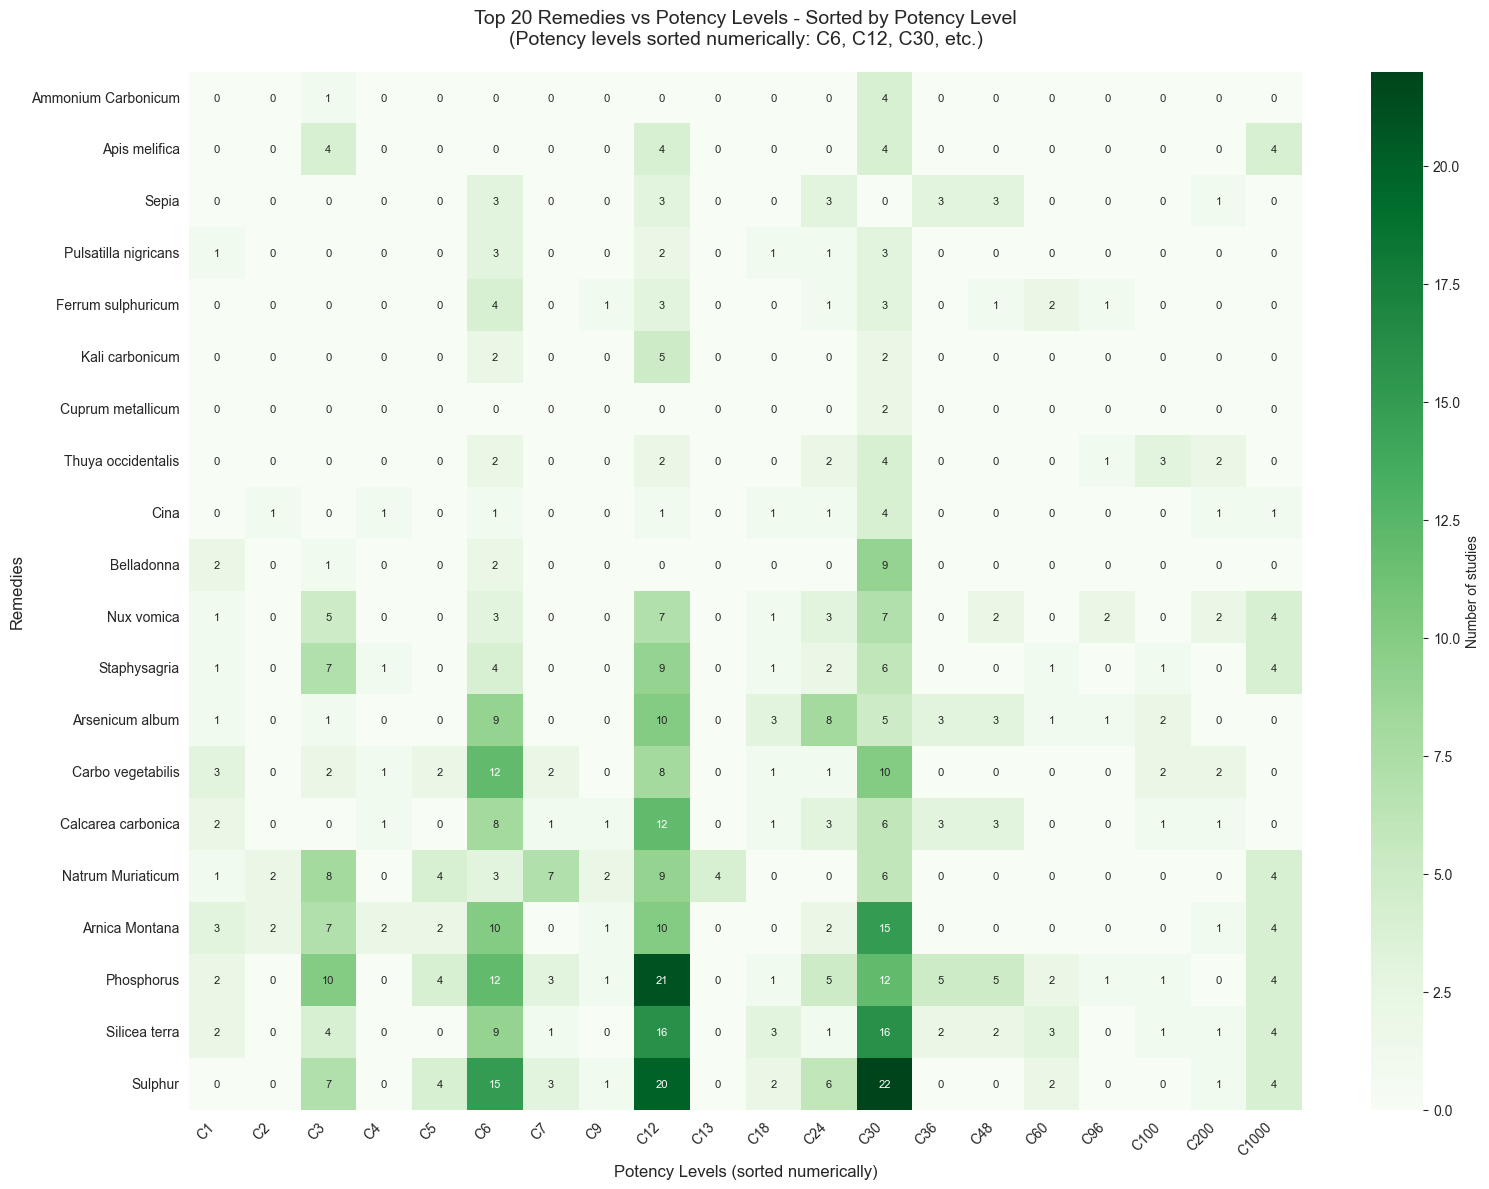


Potency levels in sorted order:
1. C1 (level 1)
2. C2 (level 2)
3. C3 (level 3)
4. C4 (level 4)
5. C5 (level 5)
6. C6 (level 6)
7. C7 (level 7)
8. C9 (level 9)
9. C12 (level 12)
10. C13 (level 13)
11. C18 (level 18)
12. C24 (level 24)
13. C30 (level 30)
14. C36 (level 36)
15. C48 (level 48)
16. C60 (level 60)
17. C96 (level 96)
18. C100 (level 100)
19. C200 (level 200)
20. C1000 (level 1000)


In [337]:
# Create potency-level-sorted version of remedy-potency heatmap
# Potency levels sorted numerically (C6, C12, C30, C200, etc.)

# Define a function to extract numeric value from potency strings like 'C6', 'C12', 'C200'
def extract_potency_number(potency_str):
    """Extract numeric part from potency string (e.g., 'C6' -> 6, 'C200' -> 200)"""
    try:
        # Remove 'C' prefix and convert to integer
        if potency_str.startswith('C'):
            return int(potency_str[1:])
        # For other formats (LM, M, etc.), return large number to put at end
        return 999999
    except (ValueError, AttributeError):
        # If parsing fails, return large number to put at end
        return 999999

# Sort potency levels by their numeric value
potency_cols = remedy_potency_matrix.columns.tolist()
sorted_potencies = sorted(potency_cols, key=extract_potency_number)

# Keep the same remedy order as original (frequency-based with reversed order)
remedy_rows = remedy_potency_matrix.index.tolist()

# Reindex the matrix with sorted potencies
remedy_potency_sorted = remedy_potency_matrix.loc[remedy_rows, sorted_potencies]

# Create heatmap visualization
fig_sorted_potency, ax_sorted_potency = plt.subplots(figsize=(16, 12))

sns.heatmap(
    remedy_potency_sorted,
    annot=True,  # Show numbers in cells
    fmt='d',     # Integer format
    cmap='Greens',  # Green color scheme
    ax=ax_sorted_potency,
    cbar_kws={'label': 'Number of studies'},
    annot_kws={'size': 8}  # Smaller annotation text
)

# Center ticks and labels
ax_sorted_potency.set_xticks([i + 0.5 for i in range(len(remedy_potency_sorted.columns))])
ax_sorted_potency.set_xticklabels(remedy_potency_sorted.columns, rotation=45, ha='right')
ax_sorted_potency.set_yticks([i + 0.5 for i in range(len(remedy_potency_sorted.index))])
ax_sorted_potency.set_yticklabels(remedy_potency_sorted.index, rotation=0)

# Customize the plot
ax_sorted_potency.set_title(
    'Top 20 Remedies vs Potency Levels - Sorted by Potency Level\n(Potency levels sorted numerically: C6, C12, C30, etc.)',
    fontsize=14,
    pad=20
)
ax_sorted_potency.set_xlabel('Potency Levels (sorted numerically)', fontsize=12)
ax_sorted_potency.set_ylabel('Remedies', fontsize=12)

# Save and display
plt.tight_layout()
fig_sorted_potency.savefig('remedy_potency_correlation_heatmap_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

# Print sorted potency order
print(f"\nPotency levels in sorted order:")
for i, potency in enumerate(sorted_potencies, 1):
    numeric_val = extract_potency_number(potency)
    if numeric_val < 999999:
        print(f"{i}. {potency} (level {numeric_val})")
    else:
        print(f"{i}. {potency} (non-standard format)")


Country-Crop heatmap includes:
- 6 countries (top 20)
- 20 crops (top 20)
- 100 total country-crop combinations

Top 10 country-crop combinations:
- Brazil studying Tomato: 15 studies
- Brazil studying Bean: 11 studies
- Brazil studying Soybean: 10 studies
- Brazil studying Onion: 7 studies
- Brazil studying Lettuce: 5 studies
- Brazil studying Cabbage: 4 studies
- Brazil studying Chamomile: 4 studies
- Brazil studying Artemisia: 3 studies
- Brazil studying Strawberry: 3 studies
- Brazil studying Tiririca: 3 studies


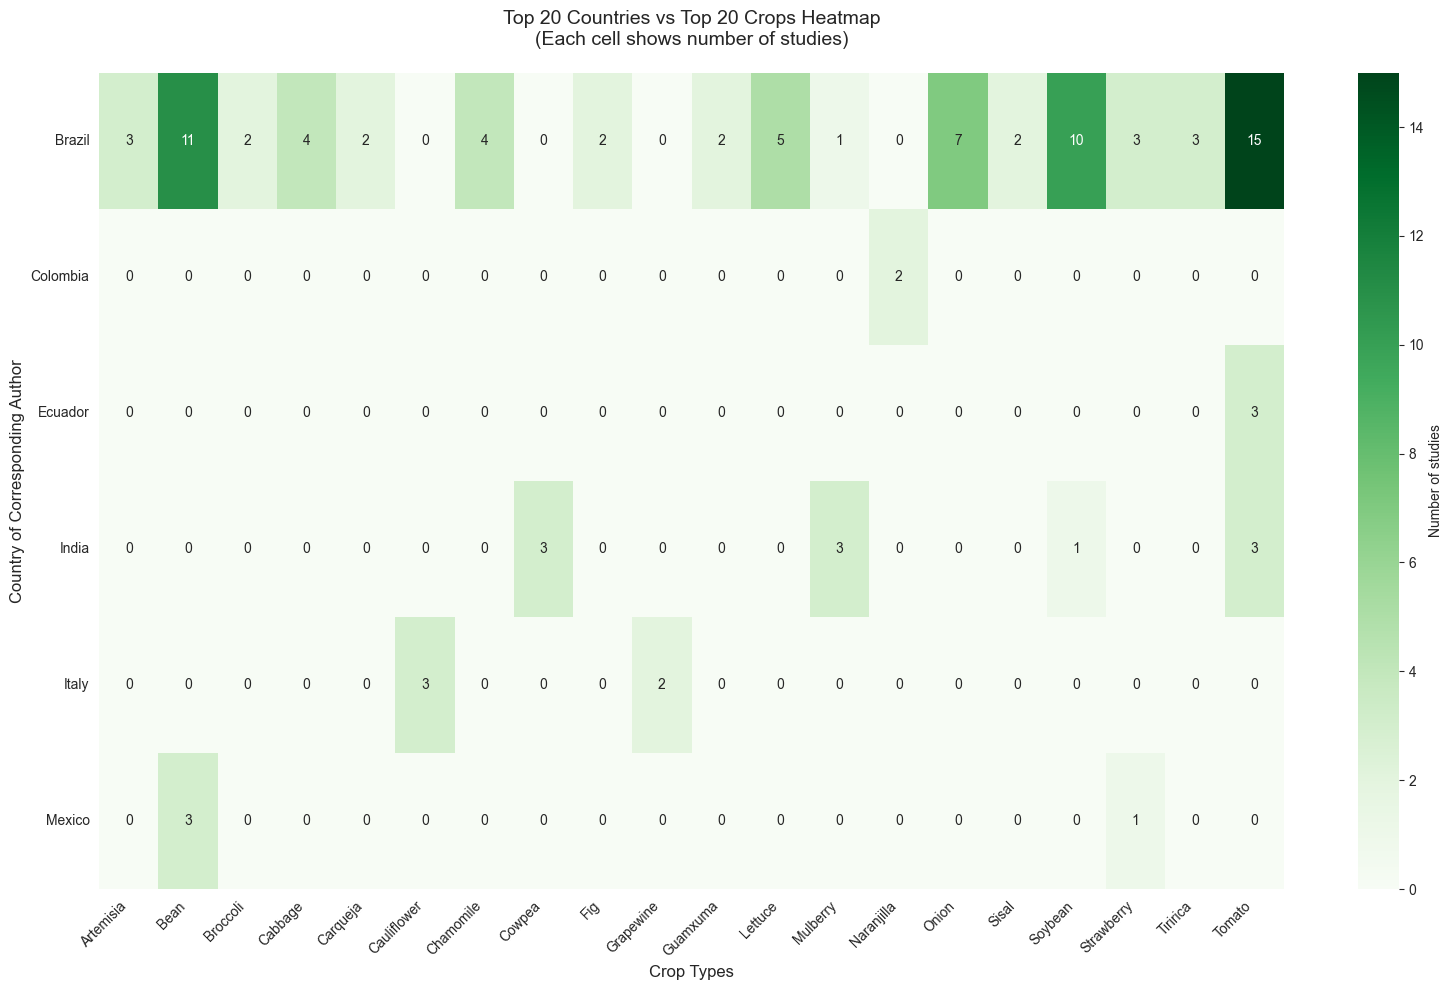

In [338]:
# Cross-Category Heatmap: Top 20 Countries vs Top 20 Crops
# This code creates a heatmap showing which crop types are studied in which countries

# Data cleaning and preparation
country_series_crop = (
    df['Country of corresponding author']
    .fillna('Blank')
    .astype(str)
    .str.strip()
    .replace({'Parkistan': 'Pakistan'})  # Fix known typo
)

crop_series_country = (
    df['Crop type studied']
    .fillna('N/A')
    .astype(str)
    .str.strip()
)

# Filter: Top 20 of each (exclude N/A, Blank)
top_20_countries = country_series_crop.value_counts().drop(['N/A', 'Blank'], errors='ignore').head(20).index.tolist()
top_20_crops_country = crop_series_country.value_counts().drop(['N/A', 'Blank'], errors='ignore').head(20).index.tolist()

# Data expansion
expanded_country_crop = []
for idx in range(len(df)):
    country = country_series_crop.iloc[idx]
    crop = crop_series_country.iloc[idx]

    # Skip if either not in top 20 or is N/A/Blank
    if country not in top_20_countries or country in ['N/A', 'Blank']:
        continue
    if crop not in top_20_crops_country or crop in ['N/A', 'Blank']:
        continue

    expanded_country_crop.append({'Country': country, 'Crop': crop})

# Validation
if len(expanded_country_crop) == 0:
    print("No data found! Check if countries and crops match top lists.")
else:
    expanded_country_crop_df = pd.DataFrame(expanded_country_crop)

    # Countries as rows, crops as columns
    country_crop_matrix = pd.crosstab(expanded_country_crop_df['Country'], expanded_country_crop_df['Crop'])

    # Create heatmap visualization
    fig_country_crop, ax_country_crop = plt.subplots(figsize=(16, 10))

    # Use seaborn for professional heatmap
    sns.heatmap(
        country_crop_matrix,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=ax_country_crop,
        cbar_kws={'label': 'Number of studies'}
    )

    # Tick positioning
    ax_country_crop.set_xticks([i + 0.5 for i in range(len(country_crop_matrix.columns))])
    ax_country_crop.set_xticklabels(country_crop_matrix.columns, rotation=45, ha='right')
    ax_country_crop.set_yticks([i + 0.5 for i in range(len(country_crop_matrix.index))])
    ax_country_crop.set_yticklabels(country_crop_matrix.index, rotation=0)

    # Labels
    ax_country_crop.set_title('Top 20 Countries vs Top 20 Crops Heatmap\n(Each cell shows number of studies)', fontsize=14, pad=20)
    ax_country_crop.set_xlabel('Crop Types', fontsize=12)
    ax_country_crop.set_ylabel('Country of Corresponding Author', fontsize=12)

    plt.tight_layout()
    fig_country_crop.savefig('country_crop_heatmap.png', dpi=300, bbox_inches='tight')

    # Summary statistics
    print(f"Country-Crop heatmap includes:")
    print(f"- {len(country_crop_matrix.index)} countries (top 20)")
    print(f"- {len(country_crop_matrix.columns)} crops (top 20)")
    print(f"- {country_crop_matrix.values.sum()} total country-crop combinations")

    # Top pairs
    country_crop_pairs = []
    for i in range(len(country_crop_matrix)):
        for j in range(len(country_crop_matrix.columns)):
            country = country_crop_matrix.index[i]
            crop = country_crop_matrix.columns[j]
            count = country_crop_matrix.iloc[i, j]
            if count > 0:
                country_crop_pairs.append((country, crop, count))

    country_crop_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop 10 country-crop combinations:")
    for country, crop, count in country_crop_pairs[:10]:
        print(f"- {country} studying {crop}: {count} studies")


## Cross-Category Heatmaps

### Country-Crop Distribution

Potency-Crop correlation heatmap includes:
- 20 potency levels (top 20)
- 18 crops (top 20)
- 265 total potency-crop combinations

Top 10 potency-crop combinations:
- C12 on Soybean: 10 studies
- C12 on Tomato: 8 studies
- C30 on Tomato: 8 studies
- C6 on Soybean: 8 studies
- C6 on Tomato: 8 studies
- C12 on Bean: 7 studies
- C6 on Bean: 6 studies
- C6 on Onion: 6 studies
- C12 on Onion: 5 studies
- C13 on Tomato: 5 studies


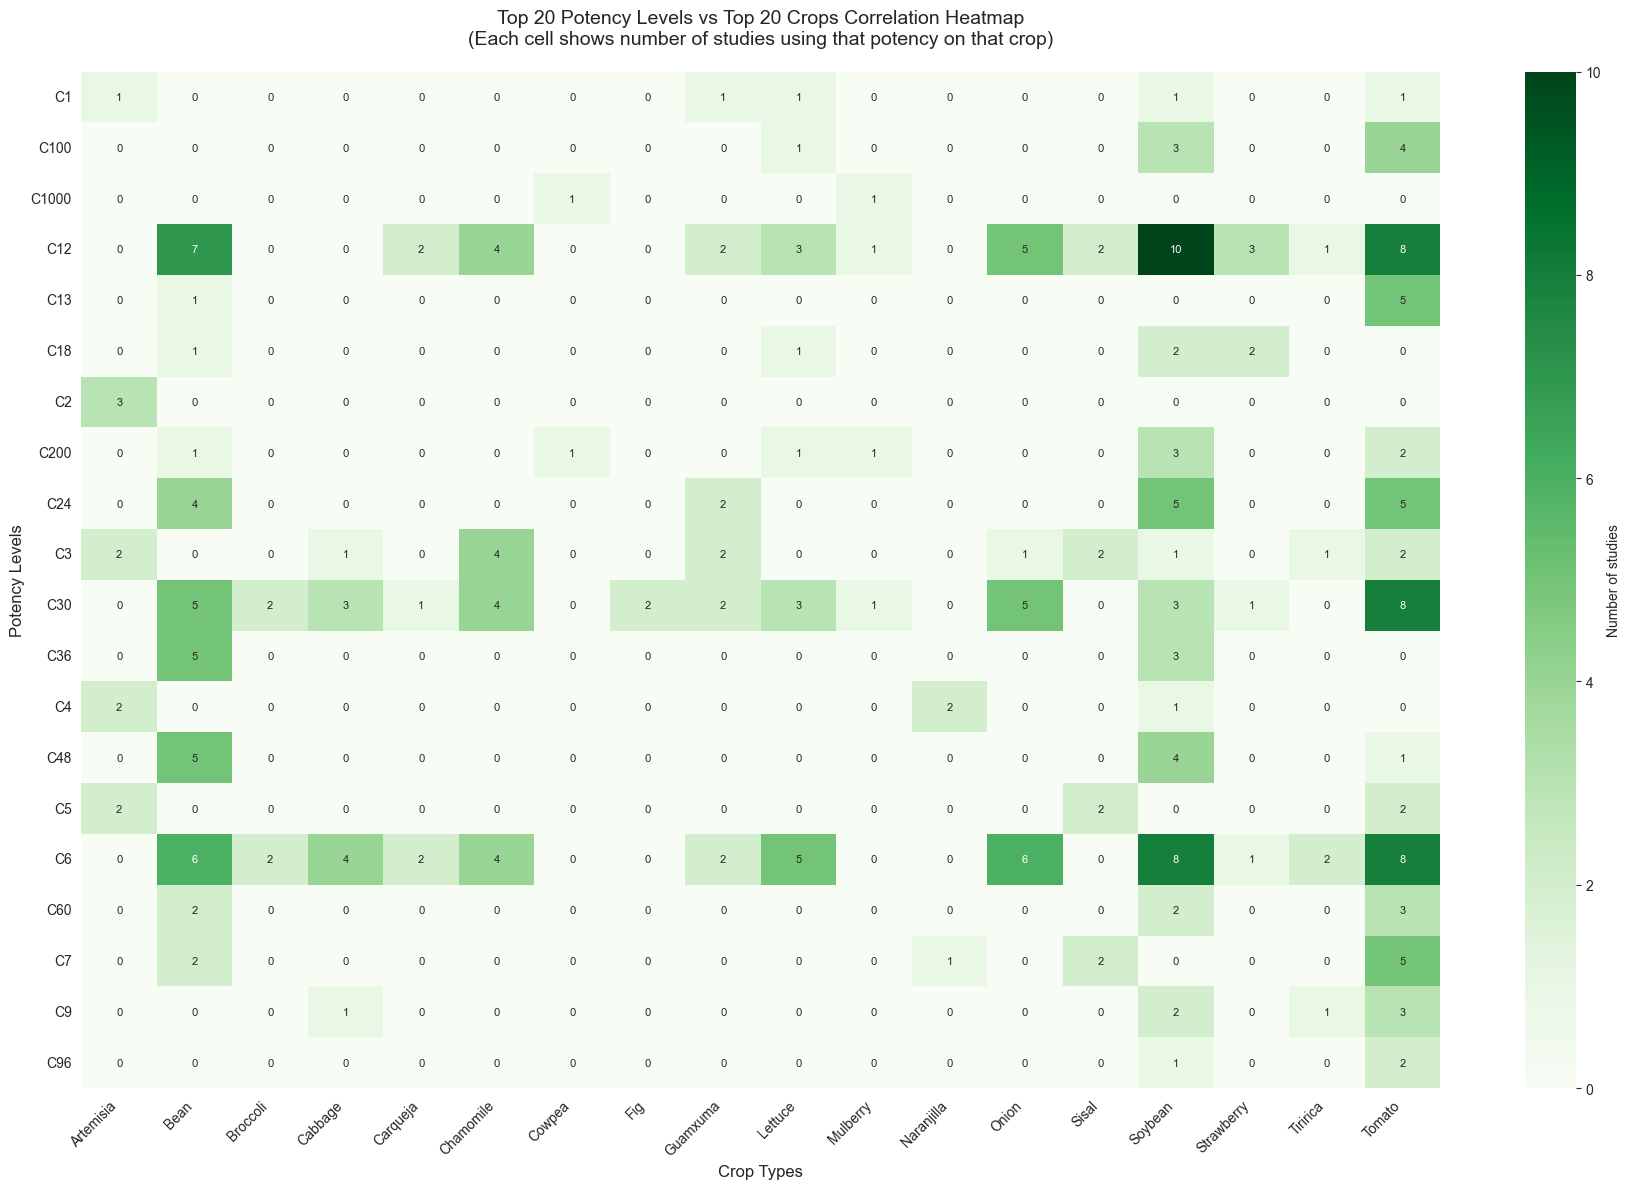

In [339]:
# Cross-Category Heatmap: Top 20 Potency Levels vs Top 20 Crops
# This code creates a heatmap showing which potency levels are used on which crops

# Data cleaning and preparation
potency_series_crop = (
    df['Potency levels']
    .fillna('Blank')
    .astype(str)
    .str.strip()
)

potency_exploded_crop = (
    potency_series_crop
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'Blank'})
)

crop_series_potency = (
    df['Crop type studied']
    .fillna('N/A')
    .astype(str)
    .str.strip()
)

# Filter: Top 20 of each (potency: drop N/A only; crop: drop N/A and Blank)
top_20_potencies_crop = potency_exploded_crop.value_counts().drop('N/A', errors='ignore').head(20).index.tolist()
top_20_crops_potency = crop_series_potency.value_counts().drop(['N/A', 'Blank'], errors='ignore').head(20).index.tolist()

# Data expansion (all combinations)
expanded_potency_crop = []
for idx in range(len(df)):
    potency_cell = potency_series_crop.iloc[idx]
    crop = crop_series_potency.iloc[idx]

    # Skip if crop not in top 20
    if crop not in top_20_crops_potency or crop in ['N/A', 'Blank']:
        continue

    # Skip if potency missing
    if pd.isna(potency_cell) or str(potency_cell).strip() in ['', 'N/A']:
        continue
    else:
        potencies = str(potency_cell).split(',')

    # Create entries for ALL potencies used on this crop
    for potency in potencies:
        potency_clean = potency.strip() if potency.strip() else 'Blank'
        if potency_clean in top_20_potencies_crop and potency_clean != 'N/A':
            expanded_potency_crop.append({'Potency': potency_clean, 'Crop': crop})

# Validation
if len(expanded_potency_crop) == 0:
    print("No data found! Check if potencies and crops match top lists.")
else:
    expanded_potency_crop_df = pd.DataFrame(expanded_potency_crop)

    # Potencies as rows, crops as columns
    potency_crop_matrix = pd.crosstab(expanded_potency_crop_df['Potency'], expanded_potency_crop_df['Crop'])

    # Create heatmap visualization
    fig_potency_crop, ax_potency_crop = plt.subplots(figsize=(18, 12))

    # Use seaborn for professional heatmap
    sns.heatmap(
        potency_crop_matrix,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=ax_potency_crop,
        cbar_kws={'label': 'Number of studies'},
        annot_kws={'size': 8}  # Smaller text for large matrix
    )

    # Tick positioning
    ax_potency_crop.set_xticks([i + 0.5 for i in range(len(potency_crop_matrix.columns))])
    ax_potency_crop.set_xticklabels(potency_crop_matrix.columns, rotation=45, ha='right')
    ax_potency_crop.set_yticks([i + 0.5 for i in range(len(potency_crop_matrix.index))])
    ax_potency_crop.set_yticklabels(potency_crop_matrix.index, rotation=0)

    # Labels
    ax_potency_crop.set_title('Top 20 Potency Levels vs Top 20 Crops Correlation Heatmap\n(Each cell shows number of studies using that potency on that crop)', fontsize=14, pad=20)
    ax_potency_crop.set_xlabel('Crop Types', fontsize=12)
    ax_potency_crop.set_ylabel('Potency Levels', fontsize=12)

    plt.tight_layout()
    fig_potency_crop.savefig('potency_crop_correlation_heatmap.png', dpi=300, bbox_inches='tight')

    # Summary statistics
    print(f"Potency-Crop correlation heatmap includes:")
    print(f"- {len(potency_crop_matrix.index)} potency levels (top 20)")
    print(f"- {len(potency_crop_matrix.columns)} crops (top 20)")
    print(f"- {potency_crop_matrix.values.sum()} total potency-crop combinations")

    # Top pairs
    potency_crop_pairs = []
    for i in range(len(potency_crop_matrix)):
        for j in range(len(potency_crop_matrix.columns)):
            potency = potency_crop_matrix.index[i]
            crop = potency_crop_matrix.columns[j]
            count = potency_crop_matrix.iloc[i, j]
            if count > 0:
                potency_crop_pairs.append((potency, crop, count))

    potency_crop_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop 10 potency-crop combinations:")
    for potency, crop, count in potency_crop_pairs[:10]:
        print(f"- {potency} on {crop}: {count} studies")


### Potency-Crop Relationships

VERIFICATION TABLE - Production Method Combinations Data (with grouping):
Production Method Combination                      No Add   Had Add  Total   
--------------------------------------------------------------------------------
In-house production of mother tincture             17       33       50      
Brand-not-reported potency store bought potency... 20       30       50      
Branded potency                                    16       11       27      
Combinations                                       4        17       21      
Branded MT                                         2        3        5       
Brand-not-reported potency store bought potency... 1        4        5       
Missing                                            2        0        2       

Summary: 7 unique combinations, 160 total entries


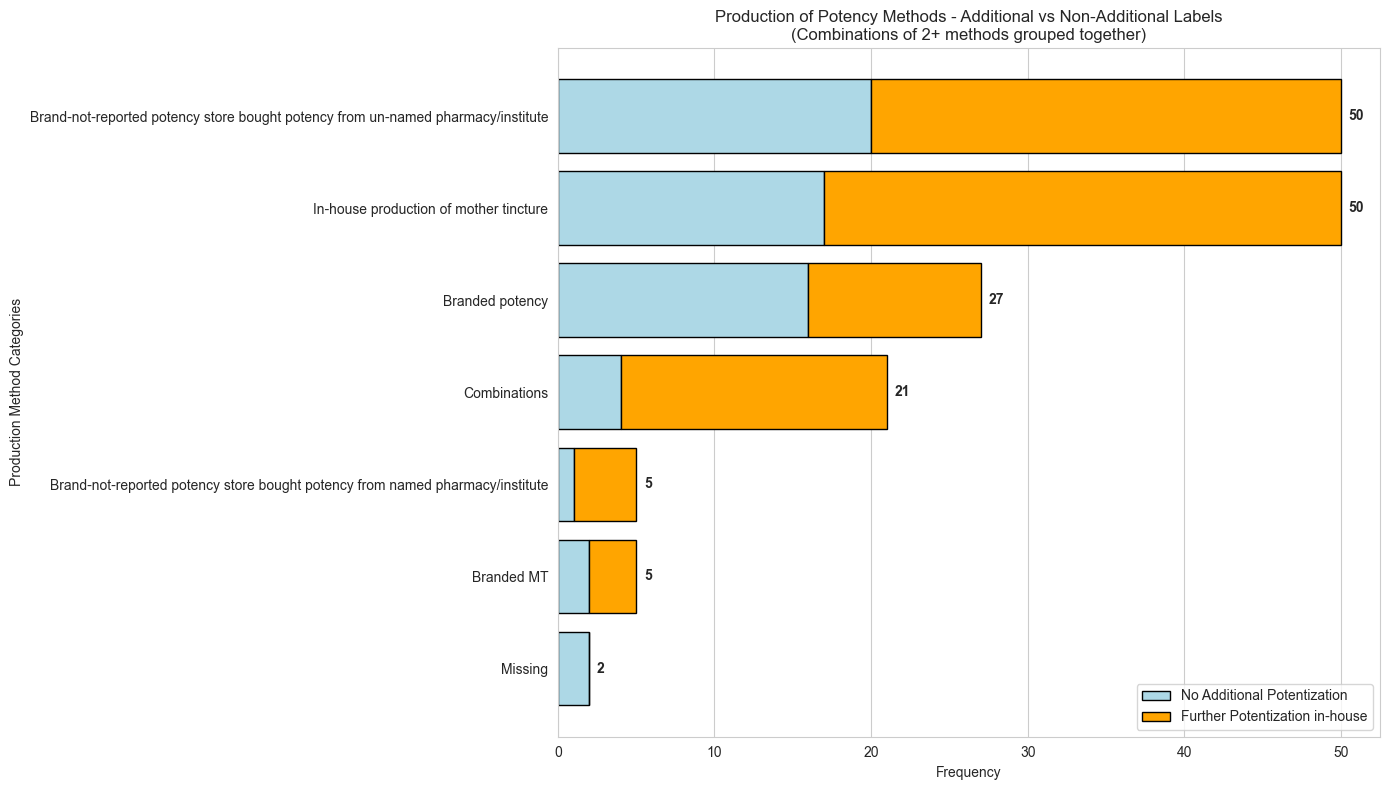

In [340]:
# Production of Potency Stacked Horizontal Bar Chart with Combination Grouping

# This code analyzes the "Production of potency" column by removing "Additional..." labels, groups combinations of two or more labels under "Combinations", and creates a data table first for verification, then creates a horizontal bar chart
# with stacked colors showing Additional vs non-Additional proportions.
# Analyze "Production of potency" with combination grouping and stacked bars showing Additional vs non-Additional proportions, with data table for verification

import csv
from io import StringIO

# Clean the production of potency column
production_series_stacked = (
    df['Production of potency']
    .fillna('Blank')
    .astype(str)
    .str.strip()
)


# Function to remove "Additional..." entries while preserving CSV structure
def clean_additional_entries(cell_value):
    if pd.isna(cell_value) or str(cell_value).strip() in ['', 'N/A', 'Blank']:
        return 'Missing', False

    try:
        # Parse CSV entries properly
        csv_input = StringIO(str(cell_value))
        csv_reader = csv.reader(csv_input)
        parsed_entries = next(csv_reader)

        # Check if any entry starts with "Additional"
        has_additional = any(entry.strip().startswith('Additional') for entry in parsed_entries)

        # Remove Additional entries and clean remaining ones
        cleaned_entries = [entry.strip() for entry in parsed_entries
                           if entry.strip() and not entry.strip().startswith('Additional')]

        # Reconstruct the cleaned string
        if cleaned_entries:
            cleaned_string = ', '.join(cleaned_entries)
        else:
            cleaned_string = 'N/A'

        return cleaned_string, has_additional

    except:
        # Fallback: simple comma split if CSV parsing fails
        entries = [entry.strip() for entry in str(cell_value).split(',')]
        has_additional = any(entry.startswith('Additional') for entry in entries)
        cleaned_entries = [entry for entry in entries if entry and not entry.startswith('Additional')]

        if cleaned_entries:
            cleaned_string = ', '.join(cleaned_entries)
        else:
            cleaned_string = 'N/A'

        return cleaned_string, has_additional


# Process all entries to create cleaned combinations and track Additional status
combination_data = {}
for idx in range(len(df)):
    cell_value = production_series_stacked.iloc[idx]
    cleaned_combination, had_additional = clean_additional_entries(cell_value)

    # Group combinations of 2+ labels under "Combinations"
    if cleaned_combination != ['N/A', 'Blank'] and ',' in cleaned_combination:
        grouped_combination = 'Combinations'
    else:
        grouped_combination = cleaned_combination

    # Initialize combination tracking if not seen before
    if grouped_combination not in combination_data:
        combination_data[grouped_combination] = {'had_additional': 0, 'no_additional': 0}

    # Count based on whether original entry had Additional labels
    if had_additional:
        combination_data[grouped_combination]['had_additional'] += 1
    else:
        combination_data[grouped_combination]['no_additional'] += 1

# Convert to DataFrame for easier manipulation and verification
combination_df = pd.DataFrame([
    {
        'combination': combo,
        'had_additional': data['had_additional'],
        'no_additional': data['no_additional'],
        'total': data['had_additional'] + data['no_additional']
    }
    for combo, data in combination_data.items()
])

# Sort by total frequency (highest first for table display)
combination_df_display = combination_df.sort_values('total', ascending=False)

# Display verification table
print("VERIFICATION TABLE - Production Method Combinations Data (with grouping):")
print("=" * 80)
print(f"{'Production Method Combination':<50} {'No Add':<8} {'Had Add':<8} {'Total':<8}")
print("-" * 80)
for _, row in combination_df_display.iterrows():
    combo = row['combination'][:47] + "..." if len(row['combination']) > 50 else row['combination']
    print(f"{combo:<50} {row['no_additional']:<8} {row['had_additional']:<8} {row['total']:<8}")

print(f"\nSummary: {len(combination_df)} unique combinations, {combination_df['total'].sum()} total entries")

# Sort for chart display (ascending=True puts smallest at bottom for horizontal bars)
combination_df = combination_df.sort_values('total', ascending=True)

# Create stacked horizontal bar chart
fig_prod_stacked, ax_prod_stacked = plt.subplots(figsize=(14, max(8, len(combination_df) * 0.4)))

# Create stacked horizontal bars
y_positions = range(len(combination_df))
bars_no_additional = ax_prod_stacked.barh(y_positions, combination_df['no_additional'],
                                          label='No Additional Potentization', color='lightblue', edgecolor='black')
bars_had_additional = ax_prod_stacked.barh(y_positions, combination_df['had_additional'],
                                           left=combination_df['no_additional'],
                                           label='Further Potentization in-house', color='orange', edgecolor='black')

# Set y-axis labels and positions
ax_prod_stacked.set_yticks(y_positions)
ax_prod_stacked.set_yticklabels(combination_df['combination'], fontsize=10)

# Customize the plot
ax_prod_stacked.set_xlabel('Frequency')
ax_prod_stacked.set_ylabel('Production Method Categories')
ax_prod_stacked.set_title(
    'Production of Potency Methods - Additional vs Non-Additional Labels\n(Combinations of 2+ methods grouped together)')
ax_prod_stacked.legend()

# Add total count labels on the bars
for i, (_, row) in enumerate(combination_df.iterrows()):
    total = row['total']
    ax_prod_stacked.text(total + 0.5, i, str(int(total)), va='center', fontweight='bold')

ax_prod_stacked.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_prod_stacked.savefig('production_potency_stacked_horizontal_bar.png', dpi=300, bbox_inches='tight')
plt.show()


### Intervention Type-Crop Relationships

Intervention-Crop heatmap includes:
- 8 intervention types
- 20 crops (top 20)
- 118 total intervention-crop combinations

Top 10 intervention-crop combinations:
- Treatment of plant during growth (eg. spray on leaves) on Tomato: 12 studies
- Treatment of plant during growth (eg. spray on leaves) on Onion: 7 studies
- Treatment of soil during growth (seperate from watering) on Bean: 7 studies
- Treatment of plant during growth (eg. spray on leaves) on Bean: 6 studies
- Treatment of plant during growth (eg. spray on leaves) on Soybean: 6 studies
- Pre-treatment of seeds on Tomato: 4 studies
- Pre-treatment of soil/growth medium on Soybean: 4 studies
- Treatment of plant during growth (eg. spray on leaves) on Mulberry: 4 studies
- Pre-treatment of seeds on Bean: 3 studies
- Pre-treatment of soil/growth medium on Tomato: 3 studies


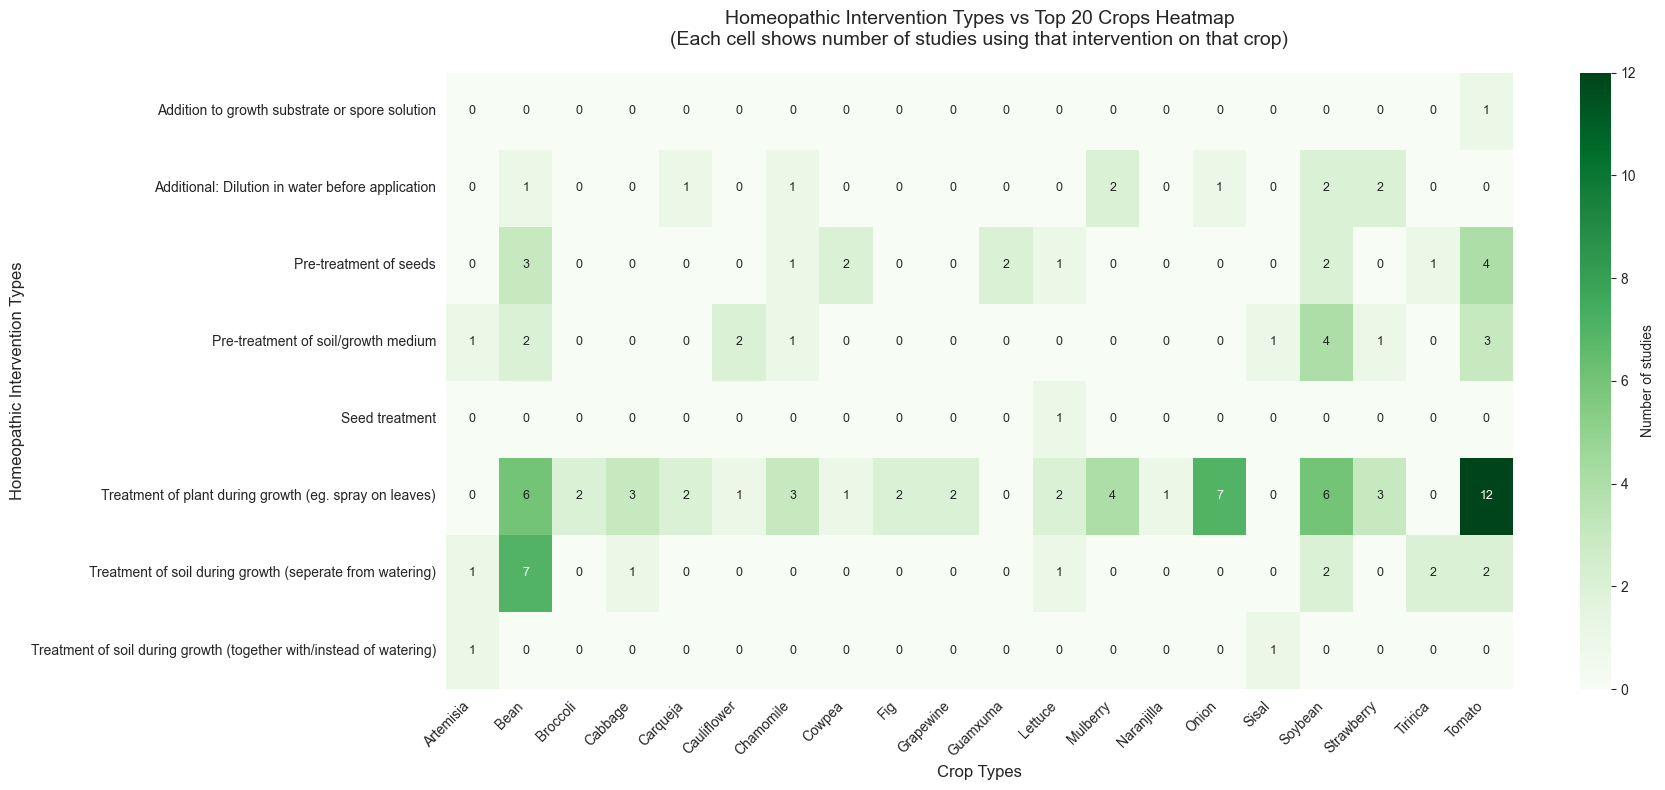

In [341]:
# Cross-Category Heatmap: Homeopathic Intervention Types vs Top 20 Crops
# This code creates a heatmap showing which intervention types are applied to which crops

# Data cleaning and preparation
intervention_series_crop = (
    df['Homeopathic intervention']
    .fillna('N/A')
    .astype(str)
    .str.strip()
)

intervention_exploded_crop = (
    intervention_series_crop
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'N/A'})
)

crop_series_intervention = (
    df['Crop type studied']
    .fillna('N/A')
    .astype(str)
    .str.strip()
)

# Filter: Top 20 crops, ALL intervention types (since we know there are only ~9 types)
top_20_crops_intervention = crop_series_intervention.value_counts().drop(['N/A', 'Blank'], errors='ignore').head(20).index.tolist()
all_interventions = intervention_exploded_crop.value_counts().drop(['N/A', 'Blank'], errors='ignore').index.tolist()

# Data expansion
expanded_intervention_crop = []
for idx in range(len(df)):
    crop = crop_series_intervention.iloc[idx]
    intervention_cell = intervention_series_crop.iloc[idx]

    # Skip if crop not in top 20
    if crop not in top_20_crops_intervention or crop in ['N/A', 'Blank']:
        continue

    # Skip if intervention missing
    if pd.isna(intervention_cell) or str(intervention_cell).strip() in ['', 'N/A']:
        continue
    else:
        interventions = str(intervention_cell).split(',')

    for intervention in interventions:
        intervention_clean = intervention.strip() if intervention.strip() else 'N/A'
        if intervention_clean in all_interventions and intervention_clean not in ['N/A', 'Blank']:
            expanded_intervention_crop.append({'Intervention': intervention_clean, 'Crop': crop})

# Validation
if len(expanded_intervention_crop) == 0:
    print("No data found! Check if interventions and crops match top lists.")
else:
    expanded_intervention_crop_df = pd.DataFrame(expanded_intervention_crop)

    # Interventions as rows, crops as columns
    intervention_crop_matrix = pd.crosstab(expanded_intervention_crop_df['Intervention'], expanded_intervention_crop_df['Crop'])

    # Create heatmap visualization (adjust figsize based on number of intervention types ~9 x 20 crops)
    fig_intervention_crop, ax_intervention_crop = plt.subplots(figsize=(18, 8))

    # Use seaborn for professional heatmap
    sns.heatmap(
        intervention_crop_matrix,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=ax_intervention_crop,
        cbar_kws={'label': 'Number of studies'},
        annot_kws={'size': 9}  # Slightly larger since fewer rows
    )

    # Tick positioning
    ax_intervention_crop.set_xticks([i + 0.5 for i in range(len(intervention_crop_matrix.columns))])
    ax_intervention_crop.set_xticklabels(intervention_crop_matrix.columns, rotation=45, ha='right')
    ax_intervention_crop.set_yticks([i + 0.5 for i in range(len(intervention_crop_matrix.index))])
    ax_intervention_crop.set_yticklabels(intervention_crop_matrix.index, rotation=0)

    # Labels
    ax_intervention_crop.set_title('Homeopathic Intervention Types vs Top 20 Crops Heatmap\n(Each cell shows number of studies using that intervention on that crop)', fontsize=14, pad=20)
    ax_intervention_crop.set_xlabel('Crop Types', fontsize=12)
    ax_intervention_crop.set_ylabel('Homeopathic Intervention Types', fontsize=12)

    plt.tight_layout()
    fig_intervention_crop.savefig('intervention_crop_heatmap.png', dpi=300, bbox_inches='tight')

    # Summary statistics
    print(f"Intervention-Crop heatmap includes:")
    print(f"- {len(intervention_crop_matrix.index)} intervention types")
    print(f"- {len(intervention_crop_matrix.columns)} crops (top 20)")
    print(f"- {intervention_crop_matrix.values.sum()} total intervention-crop combinations")

    # Top pairs
    intervention_crop_pairs = []
    for i in range(len(intervention_crop_matrix)):
        for j in range(len(intervention_crop_matrix.columns)):
            intervention = intervention_crop_matrix.index[i]
            crop = intervention_crop_matrix.columns[j]
            count = intervention_crop_matrix.iloc[i, j]
            if count > 0:
                intervention_crop_pairs.append((intervention, crop, count))

    intervention_crop_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop 10 intervention-crop combinations:")
    for intervention, crop, count in intervention_crop_pairs[:10]:
        print(f"- {intervention} on {crop}: {count} studies")


### Production of Potency Methods

## Production and Application Methods

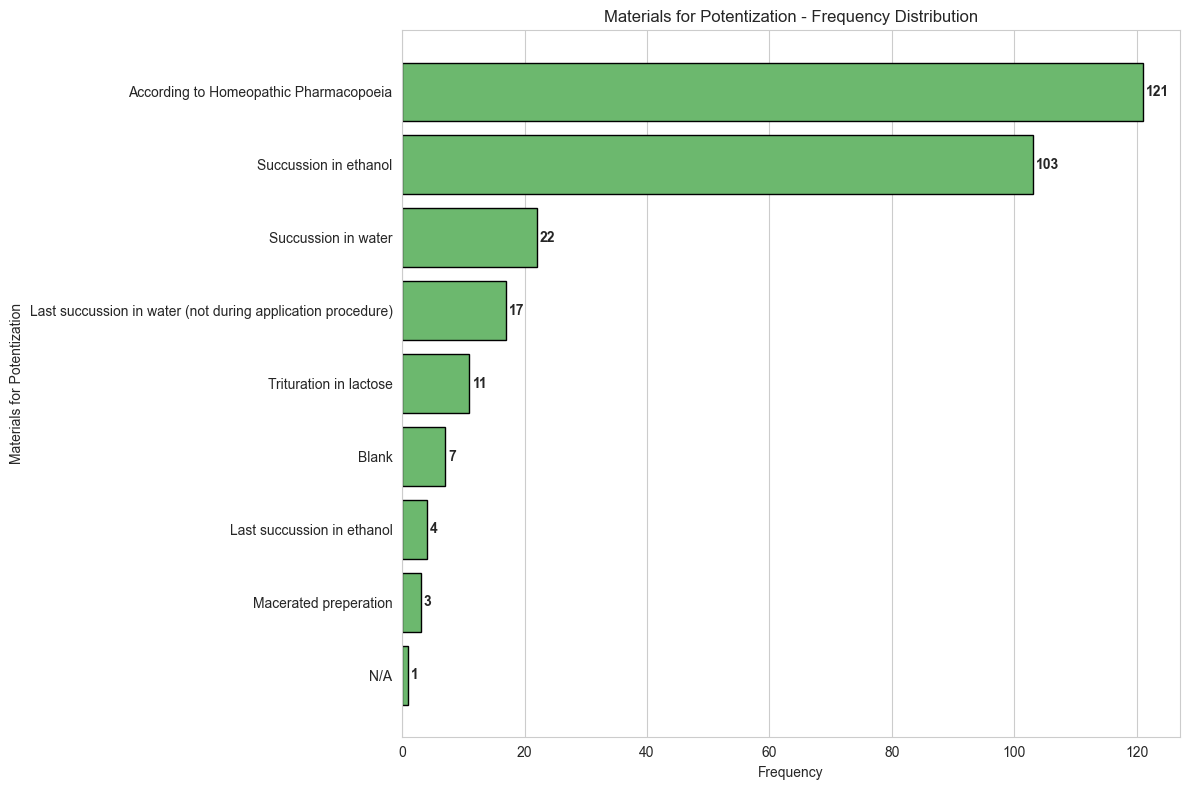

Materials for Potentization - Summary:
- Total entries: 289
- Unique materials: 9
- Most common: According to Homeopathic Pharmacopoeia (121 entries)


In [342]:
# Materials for Potentization Horizontal Bar Chart

# This code analyzes the "Materials for potentization" column and creates a horizontal bar chart showing the frequency of each material used. We'll handle comma-separated entries properly.

# Analyze "Materials for potentization" column and create horizontal bar chart with comma separation

# Clean and split the 'Materials for potentization' column on commas
materials_series_potent = (
    df['Materials for potentization']
    .fillna('Blank')
    .astype(str)
    .str.strip()
)

# Split on comma, explode into individual entries, and clean up
materials_exploded_potent = (
    materials_series_potent
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'Blank'})
)

# Get frequency counts and sort by frequency (highest first for horizontal bars)
materials_counts_potent = materials_exploded_potent.value_counts().sort_values(ascending=True)

# Create horizontal bar chart using matplotlib
fig_materials, ax_materials = plt.subplots(figsize=(12, 8))

# Create horizontal bars with proper positioning
y_positions = range(len(materials_counts_potent))
bars = ax_materials.barh(y_positions, materials_counts_potent.values, edgecolor='black')

# Set y-axis labels and positions
ax_materials.set_yticks(y_positions)
ax_materials.set_yticklabels(materials_counts_potent.index)

# Customize the plot
ax_materials.set_xlabel('Frequency')
ax_materials.set_ylabel('Materials for Potentization')
ax_materials.set_title('Materials for Potentization - Frequency Distribution')

# Add value labels on the bars
for i, (material, freq) in enumerate(materials_counts_potent.items()):
    ax_materials.text(freq + 0.5, i, str(freq), va='center', fontweight='bold')

ax_materials.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_materials.savefig('materials_potentization_horizontal_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"Materials for Potentization - Summary:")
print(f"- Total entries: {len(materials_exploded_potent)}")
print(f"- Unique materials: {len(materials_counts_potent)}")
print(f"- Most common: {materials_counts_potent.index[-1]} ({materials_counts_potent.iloc[-1]} entries)")


### Materials for Potentization

In [343]:
# Create pie chart showing succussion methods per study from "Materials for potentization" column

# Clean the materials for potentization column
materials_series_pie = (
    df['Materials for potentization']
    .fillna('N/A')
    .astype(str)
    .str.strip()
)


# Function to categorize each study based on succussion method
def categorize_succussion_method(cell_value):
    if pd.isna(cell_value) or str(cell_value).strip() in ['', 'N/A', 'Blank']:
        return 'No Info'

    cell_str = str(cell_value).lower()  # Convert to lowercase for case-insensitive matching

    has_water = 'succussion in water' in cell_str
    has_ethanol = 'succussion in ethanol' in cell_str

    if has_water and has_ethanol:
        return 'Both'
    elif has_water:
        return 'Succussion in water'
    elif has_ethanol:
        return 'Succussion in ethanol'
    else:
        return 'Other'  # Trituration or maceration


# Apply categorization to each study
succussion_categories = materials_series_pie.apply(categorize_succussion_method)
succussion_counts = succussion_categories.value_counts()

# Prepare data for pie chart
labels_succussion = succussion_counts.index.tolist()
labels_succussion = [add_line_breaks_to_label(lbl, strategy='word_count') for lbl in labels_succussion]
values_succussion = succussion_counts.values.tolist()

# Compute percentages and set label positions
total_succussion = sum(values_succussion)
percentages_succussion = [(v / total_succussion) * 100 if total_succussion else 0 for v in values_succussion]
percentages_cutoff = 10
text_positions_succussion = ['outside' if p < percentages_cutoff else 'inside' for p in percentages_succussion]
custom_text_succussion = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels_succussion, percentages_succussion, text_positions_succussion)
]

# Build pie chart (styled like the "Country of corresponding author" chart)
succussion_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_succussion,
            values=values_succussion,
            text=custom_text_succussion,
            textinfo='text',
            textposition=text_positions_succussion,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

succussion_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=12, color='black'),
succussion_pie.update_layout(
    title='Materials for Potentization - Succussion Methods',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

succussion_pie.show()
succussion_pie.write_image('materials_succussion_methods_pie.png', width=800, height=600, scale=2)

# Print summary statistics
print(f"Succussion Methods Distribution:")
for method, count in succussion_counts.items():
    percentage = (count / total_succussion * 100) if total_succussion else 0
    print(f"- {method}: {count} studies ({percentage:.1f}%)")
print(f"Total studies: {total_succussion}")


Succussion Methods Distribution:
- Succussion in ethanol: 90 studies (56.2%)
- Other: 24 studies (15.0%)
- Succussion in water: 23 studies (14.4%)
- Both: 16 studies (10.0%)
- No Info: 7 studies (4.4%)
Total studies: 160


## Control Strategies

### Succussion Methods

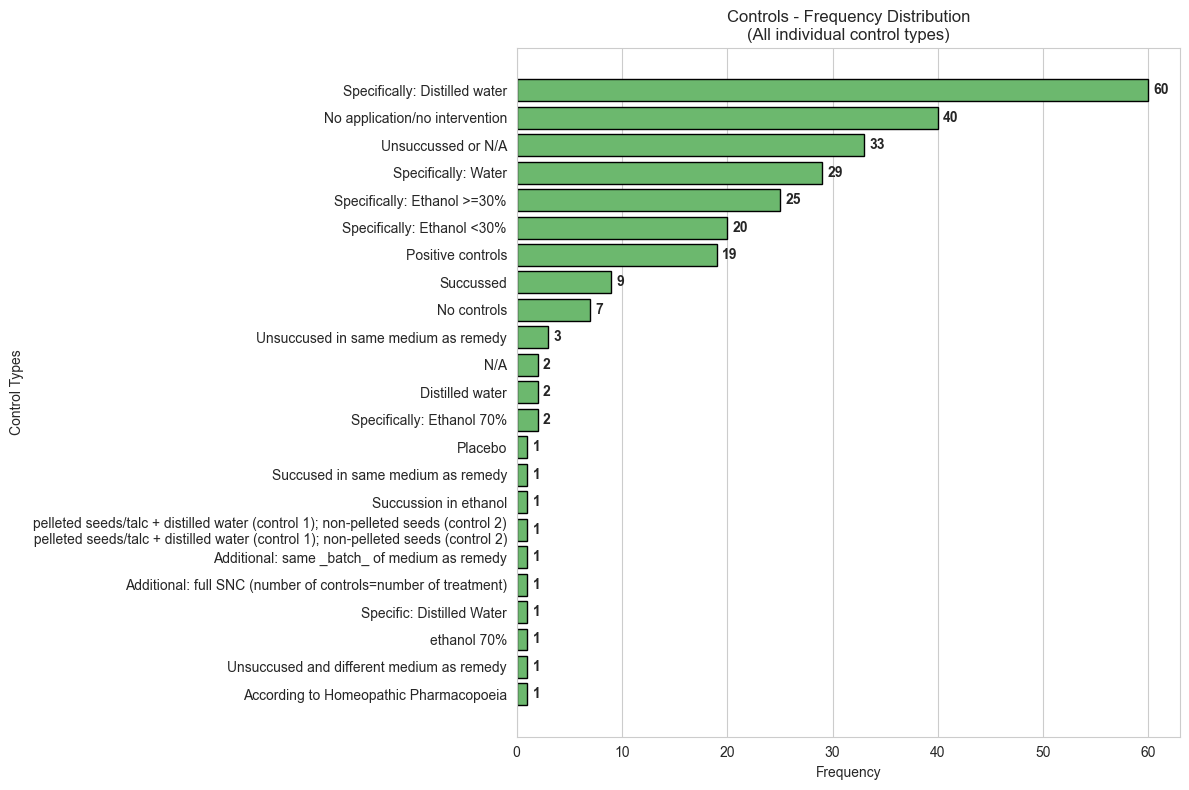

Controls - Summary:
- Total entries: 261
- Unique control types: 23
- Most common: Specifically: Distilled water (60 entries)
- Least common: According to Homeopathic Pharmacopoeia (1 entries)


In [344]:
# Analyze "Controls" column and create horizontal bar chart with comma separation, showing all individual control types

# Clean and split the 'Controls' column on commas
controls_series_chart = (
    df['Controls']
    .fillna('Blank')
    .astype(str)
    .str.strip()
)

# Split on comma, explode into individual entries, and clean up
controls_exploded_chart = (
    controls_series_chart
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'Blank'})
)

# Get frequency counts and sort by frequency (highest first for horizontal bars)
controls_counts_chart = controls_exploded_chart.value_counts().sort_values(ascending=True)

# Create horizontal bar chart using matplotlib
fig_controls, ax_controls = plt.subplots(figsize=(12, max(8, len(controls_counts_chart) * 0.3)))

# Create horizontal bars with proper positioning
y_positions = range(len(controls_counts_chart))
bars = ax_controls.barh(y_positions, controls_counts_chart.values, edgecolor='black')

# Set y-axis labels and positions
ax_controls.set_yticks(y_positions)
ax_controls.set_yticklabels(controls_counts_chart.index, fontsize=10)

# Customize the plot
ax_controls.set_xlabel('Frequency')
ax_controls.set_ylabel('Control Types')
ax_controls.set_title('Controls - Frequency Distribution\n(All individual control types)')

# Add value labels on the bars
for i, (control, freq) in enumerate(controls_counts_chart.items()):
    ax_controls.text(freq + 0.5, i, str(freq), va='center', fontweight='bold')

ax_controls.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_controls.savefig('controls_horizontal_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"Controls - Summary:")
print(f"- Total entries: {len(controls_exploded_chart)}")
print(f"- Unique control types: {len(controls_counts_chart)}")
print(f"- Most common: {controls_counts_chart.index[-1]} ({controls_counts_chart.iloc[-1]} entries)")
print(f"- Least common: {controls_counts_chart.index[0]} ({controls_counts_chart.iloc[0]} entries)")


RELABELING COMPARISON:
Original: 23 unique labels, 261 total entries
Relabeled: 19 unique labels, 261 total entries


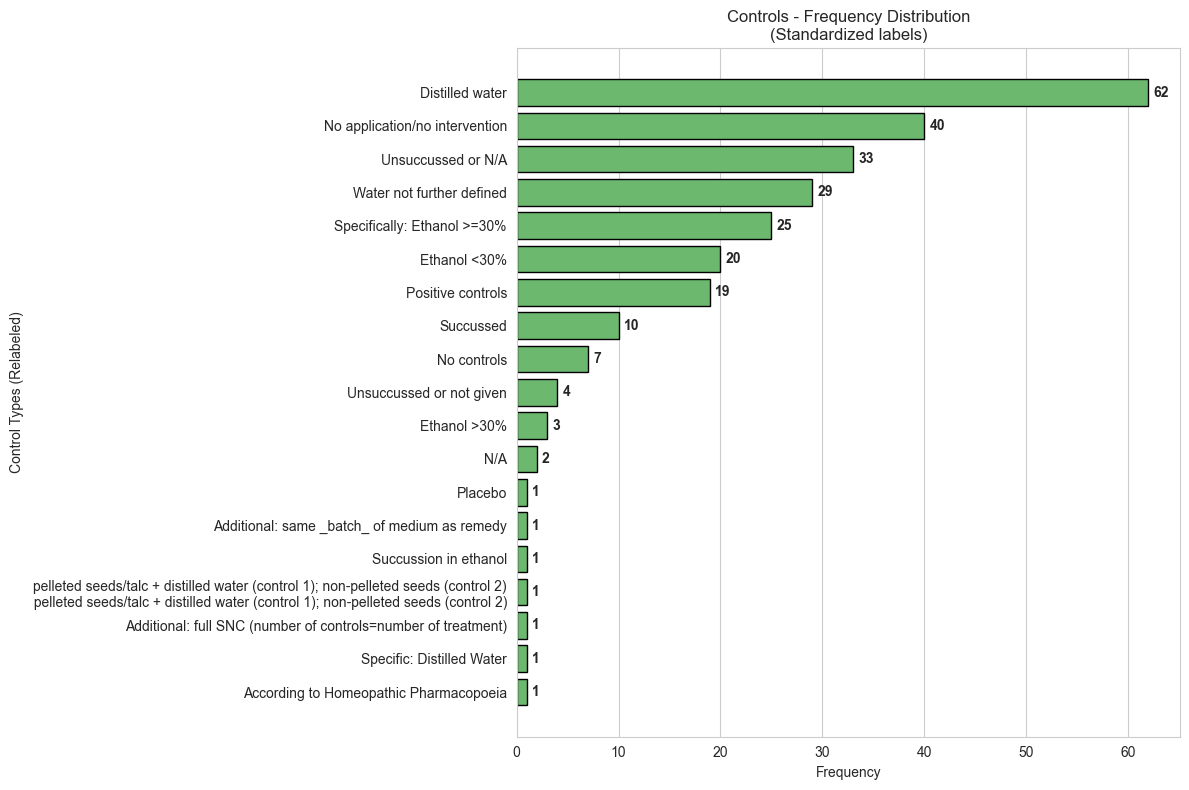


Controls (Relabeled) - Summary:
- Total entries: 261
- Unique control types: 19
- Most common: Distilled water (62 entries)
- Least common: According to Homeopathic Pharmacopoeia (1 entries)

Standardized Control Types:
 1. According to Homeopathic Pharmacopoeia
 2. Specific: Distilled Water
 3. Additional: full SNC (number of controls=number of treatment)
 4. pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)
 pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)
 5. Succussion in ethanol
 6. Additional: same _batch_ of medium as remedy
 7. Placebo
 8. N/A
 9. Ethanol >30%
10. Unsuccussed or not given
11. No controls
12. Succussed
13. Positive controls
14. Ethanol <30%
15. Specifically: Ethanol >=30%
16. Water not further defined
17. Unsuccussed or N/A
18. No application/no intervention
19. Distilled water


In [345]:
#
# NEEDS OVERHAUL -----------------
#

# Create relabeled Controls column with standardized labels and generate horizontal bar chart

# Create comprehensive mapping dictionary for control label standardization
controls_mapping = {
    'Distilled Water': 'Distilled water',
    'pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)': 'Other',
    'ethanol 70%': 'Ethanol >30%',
    'Distilled water': 'Distilled water',
    'Specifically: Ethanol 70%': 'Ethanol >30%',
    'Succused in same medium as remedy': 'Succussed',
    'No controls': 'No controls',
    'Succussed': 'Succussed',
    'Specifically: Ethanol >30%': 'Ethanol >30%',
    'Positive controls': 'Positive controls',
    'Unsuccused and different medium as remedy': 'Unsuccussed or not given',
    'Specifically: Ethanol <30%': 'Ethanol <30%',
    'Unsuccused in same medium as remedy': 'Unsuccussed or not given',
    'No application/no intervention': 'No application/no intervention',
    'Specifically: Distilled water': 'Distilled water',
    'Unsuccused or N/A': 'Unsuccussed or not given',
    'Specifically: Water': 'Water not further defined',
    'N/A': 'N/A'
}


# Function to relabel individual control entries
def relabel_control_entry(entry):
    entry = entry.strip()
    return controls_mapping.get(entry, entry)  # Return mapped value or original if not found


# Clean the original Controls column and apply relabeling
controls_series_original = (
    df['Controls']
    .fillna('Blank')
    .astype(str)
    .str.strip()
)

# Apply relabeling to each cell (handling comma-separated entries)
controls_relabeled_series = []
for cell_value in controls_series_original:
    if cell_value in ['', 'N/A']:
        controls_relabeled_series.append('N/A')
    else:
        # Split by comma, relabel each entry, then rejoin
        entries = [entry.strip() for entry in cell_value.split(',')]
        relabeled_entries = [relabel_control_entry(entry) for entry in entries]
        controls_relabeled_series.append(', '.join(relabeled_entries))

# Create controls_relabeled column
controls_relabeled = pd.Series(controls_relabeled_series, index=df.index)

# Split relabeled controls on comma, explode into individual entries, and clean up
controls_relabeled_exploded = (
    controls_relabeled
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'N/A'})
)

# Get frequency counts and sort by frequency (highest first for horizontal bars)
controls_relabeled_counts = controls_relabeled_exploded.value_counts().sort_values(ascending=True)

# Display comparison of before and after relabeling
print("RELABELING COMPARISON:")
print("=" * 50)
original_exploded = (controls_series_original.str.split(',').explode().astype(str).str.strip().replace({'': 'N/A'}))
original_counts = original_exploded.value_counts()
print(f"Original: {len(original_counts)} unique labels, {len(original_exploded)} total entries")
print(f"Relabeled: {len(controls_relabeled_counts)} unique labels, {len(controls_relabeled_exploded)} total entries")

# Create horizontal bar chart using matplotlib
fig_controls_relabeled, ax_controls_relabeled = plt.subplots(figsize=(12, max(8, len(controls_relabeled_counts) * 0.3)))

# Create horizontal bars with proper positioning
y_positions = range(len(controls_relabeled_counts))
bars = ax_controls_relabeled.barh(y_positions, controls_relabeled_counts.values, edgecolor='black')

# Set y-axis labels and positions
ax_controls_relabeled.set_yticks(y_positions)
ax_controls_relabeled.set_yticklabels(controls_relabeled_counts.index, fontsize=10)

# Customize the plot
ax_controls_relabeled.set_xlabel('Frequency')
ax_controls_relabeled.set_ylabel('Control Types (Relabeled)')
ax_controls_relabeled.set_title('Controls - Frequency Distribution\n(Standardized labels)')

# Add value labels on the bars
for i, (control, freq) in enumerate(controls_relabeled_counts.items()):
    ax_controls_relabeled.text(freq + 0.5, i, str(freq), va='center', fontweight='bold')

ax_controls_relabeled.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_controls_relabeled.savefig('controls_relabeled_horizontal_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nControls (Relabeled) - Summary:")
print(f"- Total entries: {len(controls_relabeled_exploded)}")
print(f"- Unique control types: {len(controls_relabeled_counts)}")
print(f"- Most common: {controls_relabeled_counts.index[-1]} ({controls_relabeled_counts.iloc[-1]} entries)")
print(f"- Least common: {controls_relabeled_counts.index[0]} ({controls_relabeled_counts.iloc[0]} entries)")

# Show the relabeled control types
print(f"\nStandardized Control Types:")
for i, control in enumerate(controls_relabeled_counts.index, 1):
    print(f"{i:2d}. {control}")


In [346]:
# #
# # NEEDS OVERHAUL -----------------
# #
#
#
# controls_mapping_pie = {
#       'Distilled Water': 'Distilled water',
#       'pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)': 'Other',
#       'ethanol 70%': 'Ethanol >30%',
#       'Distilled water': 'Distilled water',
#       'Specifically: Ethanol 70%': 'Ethanol >30%',
#       'Succused in same medium as remedy': 'Succussed',
#       'No controls': 'No controls',
#       'Succussed': 'Succussed',
#       'Specifically: Ethanol >30%': 'Ethanol >30%',
#       'Positive controls': 'Positive controls',
#       'Unsuccused and different medium as remedy': 'Unsuccussed or not given',
#       'Specifically: Ethanol <30%': 'Ethanol <30%',
#       'Unsuccused in same medium as remedy': 'Unsuccussed or not given',
#       'No application/no intervention': 'No application/no intervention',
#       'Specifically: Distilled water': 'Distilled water',
#       'Unsuccused or N/A': 'Unsuccussed or not given',
#       'Unsuccussed or N/A': 'Unsuccussed or not given',  # Fixed spelling variation
#       'Specifically: Water': 'Water not further defined',
#       'N/A': 'N/A'
# }
#
#   # Function to categorize each study's succussion status
#   def categorize_succussion_status(cell_value):
#       if pd.isna(cell_value) or str(cell_value).strip() in ['', 'N/A']:
#           return None  # Exclude studies with no content
#
#       # Split by comma and relabel each entry
#       entries = [entry.strip() for entry in str(cell_value).split(',')]
#       relabeled_entries = [controls_mapping_pie.get(entry, entry) for entry in entries]
#
#       # Check for target labels
#       has_succussed = 'Succussed' in relabeled_entries
#       has_unsuccussed = 'Unsuccussed or not given' in relabeled_entries
#
#       # Categorize based on presence of target labels
#       if has_succussed and has_unsuccussed:
#           return 'Both Succussed and Unsuccussed'  # Handle edge case if both present
#       elif has_succussed:
#           return 'Succussed'
#       elif has_unsuccussed:
#           return 'Unsuccussed or not given'
#       else:
#           return 'Unknown'
#
#   # Clean the original Controls column
#   controls_series_succussion = (
#       df['Controls']
#       .fillna('N/A')
#       .astype(str)
#       .str.strip()
#   )
#
#   # Apply categorization to each study
#   succussion_categories = controls_series_succussion.apply(categorize_succussion_status)
#
#   # Remove None values (excluded studies with no content)
#   succussion_categories_filtered = succussion_categories.dropna()
#
#   # Get frequency counts
#   succussion_counts = succussion_categories_filtered.value_counts()
#
#   print(f"Succussion status analysis:")
#   print(f"- Original studies: {len(df)}")
#   print(f"- Studies with control content: {len(succussion_categories_filtered)}")
#   print(f"- Excluded studies (no content): {len(df) - len(succussion_categories_filtered)}")
#
#   # Prepare data for pie chart
#   labels_succussion_status = succussion_counts.index.tolist()
#   labels_succussion_status = [add_line_breaks_to_label(lbl, strategy='word_count') for lbl in labels_succussion_status]
#   values_succussion_status = succussion_counts.values.tolist()
#
#   # Compute percentages and set label positions
#   total_succussion_status = sum(values_succussion_status)
#   percentages_succussion_status = [(v / total_succussion_status) * 100 if total_succussion_status else 0 for v in values_succussion_status]
#   percentages_cutoff = 10
#   text_positions_succussion_status = ['outside' if p < percentages_cutoff else 'inside' for p in percentages_succussion_status]
#   custom_text_succussion_status = [
#       f"{label}<br>{percent:.1f}%" if position == 'inside'
#       else f"{label} {percent:.1f}%"
#       for label, percent, position in zip(labels_succussion_status, percentages_succussion_status, text_positions_succussion_status)
#   ]
#
#   # Build pie chart (styled like the "Country of corresponding author" chart)
#   succussion_status_pie = go.Figure(
#       data=[
#           go.Pie(
#               labels=labels_succussion_status,
#               values=values_succussion_status,
#               text=custom_text_succussion_status,
#               textinfo='text',
#               textposition=text_positions_succussion_status,
#             insidetextorientation='horizontal',
#               sort=False,
#               direction='clockwise',
#               rotation=90,
#           )
#       ]
#   )
#
#   succussion_status_pie.update_traces(
#       textfont=dict(size=12, color='black'),
#       insidetextfont=dict(color='black'),
#   )
#
#
#   textfont=dict(size=12, color='black'),
#   succussion_status_pie.update_layout(
#       title='Succussion Status of Control Groups in Studies',
#       showlegend=False,
#       margin=dict(t=120, b=20, l=20, r=20)
#   )
#
#   succussion_status_pie.show()
#   succussion_status_pie.write_image('succussion_status_pie.png', width=800, height=600, scale=2)
#
#   # Print detailed breakdown
#   print(f"\nSuccussion Status Distribution:")
#   for status, count in succussion_counts.items():
#       percentage = (count / total_succussion_status * 100) if total_succussion_status else 0
#       print(f"- {status}: {count} studies ({percentage:.1f}%)")
#   print(f"Total studies analyzed: {total_succussion_status}")
#


### Interference Control During Application

In [347]:
# Title: Interference Control During Application — Grouping, Summary Table, and Pie Chart Data
# Content note: Processes 'Control for interference between group (during application)': trims/cleans text, groups mixed None/N/A entries as "Inconsistent across study", merges "Spacing"+"Shielding" as "Both", excludes "Blank" from the chart, prints the original (unsplit) frequency table, prepares grouped labels and percentages, renders and saves the pie chart, and prints a grouped breakdown.

interference_series_grouped = (
    df['Control for interference between group (during application)']
    .fillna('Blank')
    .astype(str)
    .str.strip()
)

# Function to group interference control entries
def group_interference_entries(entry):
    if entry == 'Blank':
        return 'Blank'  # Will be excluded from pie chart

    entry_lower = entry.lower()

    # Check for combinations of None/N/A with something else
    if ('none' in entry_lower or 'n/a' in entry_lower) and ',' in entry:
        return 'Inconsistent across study'

    # Check for Spacing and Shielding combinations (order independent)
    if ('spacing' in entry_lower and 'shielding' in entry_lower):
        return 'Both'

    # Return original entry for all other cases
    return entry

# Apply grouping to each study
interference_grouped = interference_series_grouped.apply(group_interference_entries)

# Remove Blank entries for pie chart
interference_grouped_no_blank = interference_grouped[interference_grouped != 'Blank']

# Get frequency counts for pie chart
interference_grouped_counts = interference_grouped_no_blank.value_counts()

# Display original unsplit frequency table first
interference_counts_unsplit = interference_series_grouped.value_counts()
interference_freq_table_unsplit = interference_counts_unsplit.to_frame(name='Frequency')
interference_freq_table_unsplit['Percentage'] = (interference_freq_table_unsplit['Frequency'] / interference_freq_table_unsplit['Frequency'].sum() * 100).round(2)

print("ORIGINAL UNSPLIT DATA - FREQUENCY TABLE:")
print("=" * 80)
print(f"{'Complete Entry':<60} {'Frequency':<10} {'Percentage':<10}")
print("-" * 80)

for entry, row in interference_freq_table_unsplit.iterrows():
    freq = row['Frequency']
    pct = row['Percentage']
    display_entry = entry[:57] + "..." if len(entry) > 60 else entry
    print(f"{display_entry:<60} {freq:<10} {pct:<10.1f}%")

print(
    f"\nOriginal data summary: {len(interference_freq_table_unsplit)} unique entries, {interference_freq_table_unsplit['Frequency'].sum()} total studies")

# Prepare data for pie chart (excluding Blanks)
labels_interference_grouped = interference_grouped_counts.index.tolist()
labels_interference_grouped = [add_line_breaks_to_label(lbl, strategy='word_count') for lbl in
                               labels_interference_grouped]
values_interference_grouped = interference_grouped_counts.values.tolist()

# Compute percentages and set label positions
total_interference_grouped = sum(values_interference_grouped)
percentages_interference_grouped = [(v / total_interference_grouped) * 100 if total_interference_grouped else 0 for v in values_interference_grouped]
percentages_cutoff = 10
text_positions_interference_grouped = ['outside' if p < percentages_cutoff else 'inside' for p in
                                       percentages_interference_grouped]
custom_text_interference_grouped = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
      for label, percent, position in zip(labels_interference_grouped, percentages_interference_grouped, text_positions_interference_grouped)
]

# Build pie chart (styled like the "Country of corresponding author" chart)
interference_grouped_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_interference_grouped,
            values=values_interference_grouped,
            text=custom_text_interference_grouped,
            textinfo='text',
            textposition=text_positions_interference_grouped,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

interference_grouped_pie.update_traces(
    textfont=dict(size=12, color='black'),
    insidetextfont=dict(color='black'),
)


textfont = dict(size=12, color='black'),
interference_grouped_pie.update_layout(
    title='Control for Interference Between Groups (Grouped)',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

interference_grouped_pie.show()
interference_grouped_pie.write_image('interference_control_grouped_pie.png', width=800, height=600, scale=2)

# Print grouped data summary
print(f"\nGROUPED DATA FOR PIE CHART (Blanks excluded):")
print(f"- Total studies in pie chart: {total_interference_grouped}")
print(f"- Excluded Blank entries: {len(interference_series_grouped[interference_series_grouped == 'Blank'])}")
print(f"- Grouped categories: {len(interference_grouped_counts)}")

print(f"\nGrouped breakdown:")
for category, count in interference_grouped_counts.items():
    percentage = (count / total_interference_grouped * 100) if total_interference_grouped else 0
    print(f"- {category}: {count} studies ({percentage:.1f}%)")


ORIGINAL UNSPLIT DATA - FREQUENCY TABLE:
Complete Entry                                               Frequency  Percentage
--------------------------------------------------------------------------------
Spacing                                                      133.0      83.1      %
None or N/A                                                  16.0       10.0      %
Spacing, Shielding                                           3.0        1.9       %
None or N/A, Spacing                                         2.0        1.2       %
Shielding, Spacing                                           2.0        1.2       %
Spacing, None or N/A                                         2.0        1.2       %
None or N/A, Shielding                                       1.0        0.6       %
Blank                                                        1.0        0.6       %

Original data summary: 8 unique entries, 160 total studies



GROUPED DATA FOR PIE CHART (Blanks excluded):
- Total studies in pie chart: 159
- Excluded Blank entries: 1
- Grouped categories: 4

Grouped breakdown:
- Spacing: 133 studies (83.6%)
- None or N/A: 16 studies (10.1%)
- Both: 5 studies (3.1%)
- Inconsistent across study: 5 studies (3.1%)


<llm-snippet-file>/Users/anezkasokol/Dropbox/AgroHomeo Review/Analysis/python_code_agrohom/agro_hom_figures260212.ipynb</llm-snippet-file>


## Outcome Measures

### Frequency of Outcome Measures

Analysis of the top 30 most frequently used outcome measures across all studies. Each study may report multiple outcome measures (comma-separated).

Total unique outcome measures: 280
Total outcome measure entries: 847

Top 30 most frequent outcome measures:


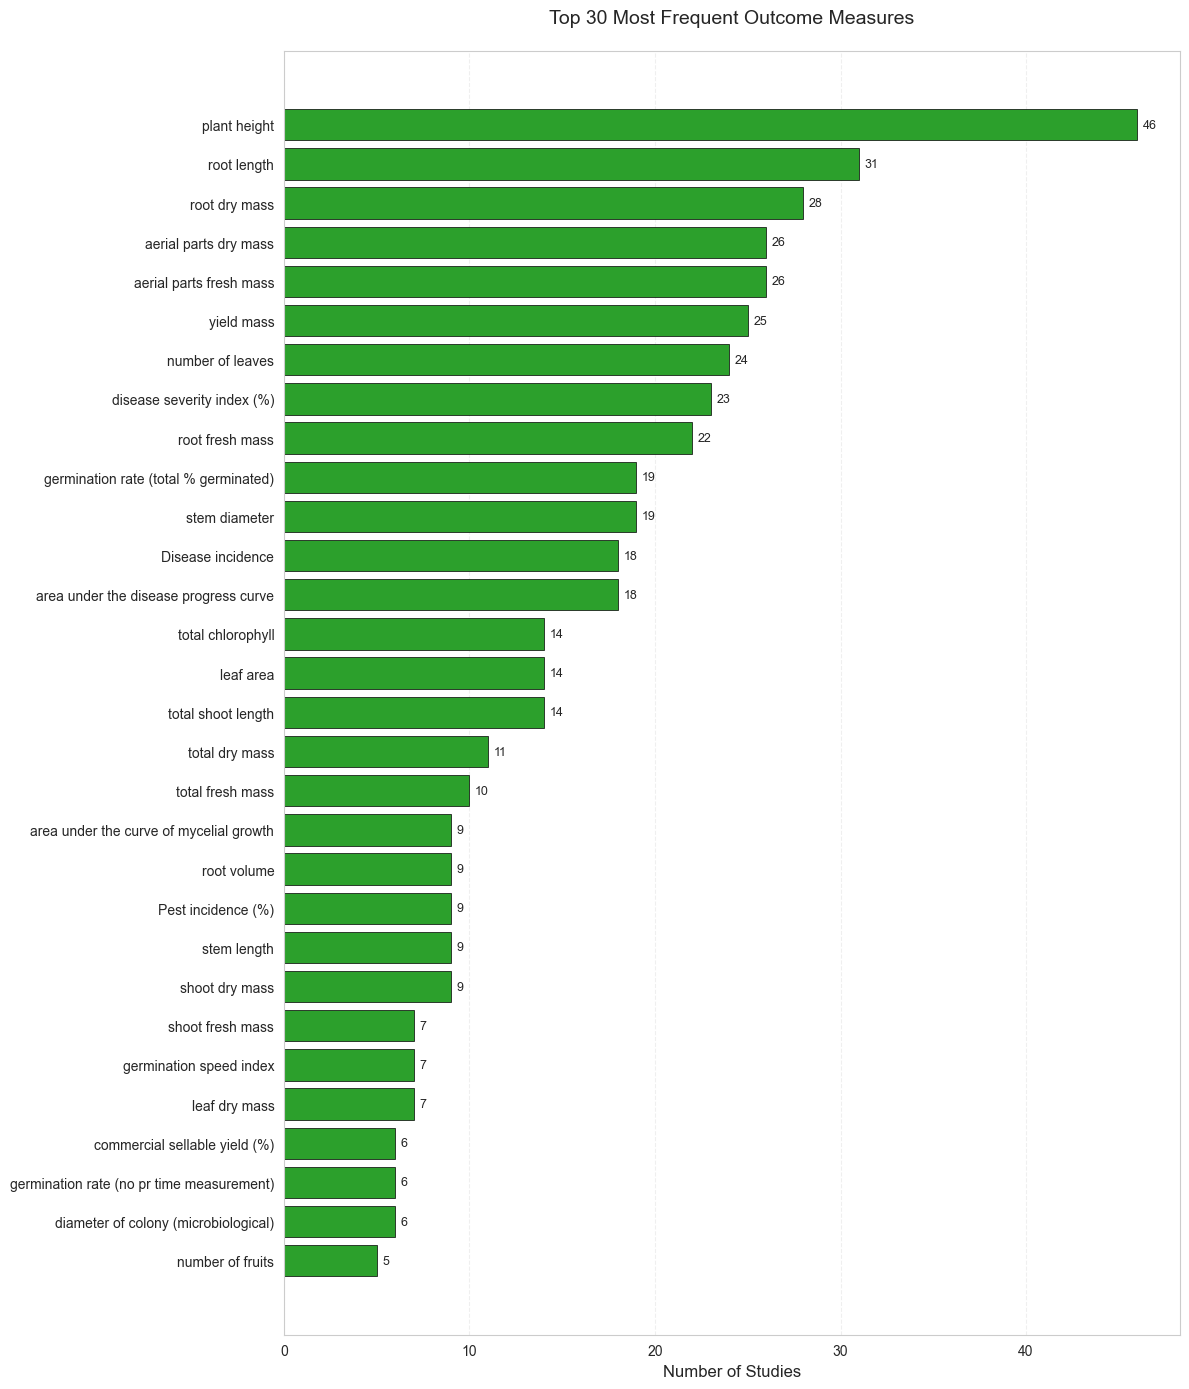


Chart saved: outcome_measures_frequency.png
Showing top 30 outcome measures out of 30 total in top 30


In [348]:
# Extract and analyze outcome measures - showing top 30 most frequent

# Clean outcome measures data
outcome_series = (
    df['Outcome measures (specific)']
    .fillna('N/A')
    .astype(str)
    .str.strip()
)

# Split comma-separated outcome measures into individual entries
outcome_exploded = (
    outcome_series
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'N/A'})
)

# Get top 30 most frequent outcome measures (excluding N/A)
outcome_counts = outcome_exploded.value_counts().drop(['N/A'], errors='ignore').head(30)

print(f"Total unique outcome measures: {outcome_exploded.nunique()}")
print(f"Total outcome measure entries: {len(outcome_exploded)}")
print(f"\nTop 30 most frequent outcome measures:")

# Create horizontal bar chart
fig_outcome, ax_outcome = plt.subplots(figsize=(12, 14))

# Create horizontal bars (reverse order so most frequent is at top)
y_pos = range(len(outcome_counts))
ax_outcome.barh(y_pos, outcome_counts.values[::-1], color='#2ca02c', edgecolor='black', linewidth=0.5)

# Customize axes
ax_outcome.set_yticks(y_pos)
ax_outcome.set_yticklabels(outcome_counts.index[::-1], fontsize=10)
ax_outcome.set_xlabel('Number of Studies', fontsize=12)
ax_outcome.set_title('Top 30 Most Frequent Outcome Measures', fontsize=14, pad=20)

# Add value labels on bars
for i, (idx, value) in enumerate(zip(y_pos, outcome_counts.values[::-1])):
    ax_outcome.text(value + 0.3, idx, str(int(value)), va='center', fontsize=9)

# Add grid for better readability

ax_outcome.grid(axis='x', alpha=0.3, linestyle='--')
ax_outcome.set_axisbelow(True)
ax_outcome.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_outcome.savefig('outcome_measures_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print(f"\nChart saved: outcome_measures_frequency.png")
print(f"Showing top 30 outcome measures out of {outcome_counts.shape[0]} total in top 30")


## Data Validation


### Outcome Measures vs Significant Results Validation

This validation checks whether significant results reported for each study are a proper subset of the outcome measures. Discrepancies may indicate:
- Typos or spelling inconsistencies
- Data entry errors
- Missing outcome measures in the documentation
- Different terminology used between columns


In [349]:
# Data Validation - Outcome Measures vs Significant Results
# Validates that significant results are proper subsets of outcome measures

# Define column names
outcome_col = 'Outcome measures (specific)'
sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Normalization function
def normalize_items(text):
    """Normalize comma-separated text into a set of cleaned items."""
    if pd.isna(text):
        return set()
    
    # Convert to string, replace newlines with spaces
    text = str(text).replace('\n', ' ')
    
    # Lowercase and strip
    text = text.lower().strip()
    
    # Split by comma and clean each item
    items = [item.strip() for item in text.split(',') if item.strip()]
    
    return set(items)

# Validate each row
validation_results = []

for idx, row in df.iterrows():
    outcomes = normalize_items(row[outcome_col])
    sig_text = row[sig_col]
    
    # Check for special valid cases
    if pd.notna(sig_text):
        sig_text_lower = str(sig_text).lower()
        # Skip if the text indicates no significant results
        if 'not significant' in sig_text_lower or 'no significance calculated' in sig_text_lower:
            continue
    
    significant = normalize_items(sig_text)
    
    # Only check rows with significant results
    if len(significant) > 0:
        # Check if significant is subset of outcomes
        if not significant.issubset(outcomes):
            missing = significant - outcomes
            
            # Get sample data for context
            outcome_list = sorted(outcomes)
            sig_list = sorted(significant)
            
            validation_results.append({
                'Row Index': idx,
                'Covidence #': int(row['Covidence #']) if pd.notna(row['Covidence #']) else 'N/A',
                'Missing Items Count': len(missing),
                'Missing Items': ', '.join(sorted(missing)),
                'Outcome Count': len(outcomes),
                'Significant Count': len(significant),
                'Sample Outcomes': ', '.join(outcome_list),
                'Sample Significant': ', '.join(sig_list)
            })

# Create results DataFrame
validation_df = pd.DataFrame(validation_results)

# Print summary statistics
print("=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)
print(f"Total rows in dataset: {len(df)}")
print(f"Rows with outcome measures: {df[outcome_col].notna().sum()}")
print(f"Rows with significant results: {df[sig_col].notna().sum()}")
print(f"\nRows with validation issues: {len(validation_df)}")

if len(validation_df) > 0:
    total_with_sig = df[sig_col].notna().sum()
    print(f"Percentage of significant results with issues: {len(validation_df)/total_with_sig*100:.1f}%")
    print(f"\nTotal missing items across all problematic rows: {validation_df['Missing Items Count'].sum()}")
    print(f"Average missing items per problematic row: {validation_df['Missing Items Count'].mean():.1f}")
    print(f"Max missing items in a single row: {validation_df['Missing Items Count'].max()}")
    
    print("\n" + "=" * 80)
    print("PROBLEMATIC STUDIES (sorted by number of missing items)")
    print("=" * 80)
    
    # Sort by missing items count and display
    validation_df_sorted = validation_df.sort_values('Missing Items Count', ascending=False)
    
    # Configure display options
    pd.set_option('display.max_colwidth', 80)
    pd.set_option('display.width', None)
    
    # Display the validation results
    display(validation_df_sorted)
    
    print("\n" + "=" * 80)
    print("DETAILED EXAMPLES (Top 5 Most Problematic)")
    print("=" * 80)
    
    for i, (idx, row_data) in enumerate(validation_df_sorted.head(5).iterrows()):
        print(f"\n{i+1}. Row {row_data['Row Index']}, Covidence #{row_data['Covidence #']}")
        print(f"   Missing Items ({row_data['Missing Items Count']}): {row_data['Missing Items']}")
        print(f"   Context: {row_data['Outcome Count']} outcomes, {row_data['Significant Count']} significant")
    
    # Save to CSV for further analysis
    output_file = 'validation_results.csv'
    validation_df_sorted.to_csv(output_file, index=False)
    print(f"\n\nFull validation results saved to: {output_file}")
    
else:
    print("\n✓ All validation checks passed!")
    print("All significant results are proper subsets of their corresponding outcome measures.")


VALIDATION SUMMARY
Total rows in dataset: 160
Rows with outcome measures: 160
Rows with significant results: 144

Rows with validation issues: 35
Percentage of significant results with issues: 24.3%

Total missing items across all problematic rows: 41
Average missing items per problematic row: 1.2
Max missing items in a single row: 3

PROBLEMATIC STUDIES (sorted by number of missing items)


,Row Index,Covidence #,Missing Items Count,Missing Items,Outcome Count,Significant Count,Sample Outcomes,Sample Significant
33,177,11863,3,"area under the curve of mycelial growth, total flavonoid content (%), total ...",1,4,microbiological growth inhibition (%),"area under the curve of mycelial growth, microbiological growth inhibition (..."
19,102,6162,2,"aerial parts fresh mass, plant height",11,11,"leaf area, number of leaves, number of nematodes in roots, number of nematod...","aerial parts fresh mass, leaf area, number of leaves, number of nematodes in..."
16,88,2242,2,"number of floral blooms, stem fresh mass",11,10,"aerial parts dry mass, aerial parts fresh mass, leaf dry mass, leaf fresh ma...","aerial parts dry mass, aerial parts fresh mass, number of branches, number o..."
31,162,10666,2,"area under the disease progress curve, germination rate (no pr time measurem...",2,2,"area under the curve of mycelial growth, number of sclerotia","area under the disease progress curve, germination rate (no pr time measurem..."
18,91,2344,2,"fruit fresh mass, root volume",3,5,"peroxidase, phenylalanine ammonia-lyase, polyphenoloxidase","fruit fresh mass, peroxidase, phenylalanine ammonia-lyase, polyphenoloxidase..."
24,133,10591,1,injured leaf area (%),7,1,"area under the disease progress curve pest incidence and severity (thrips), ...",injured leaf area (%)
20,110,6190,1,number of floral blooms,9,5,"number of branches, number of flower buds, number of leaves, root length, so...","number of branches, number of floral blooms, number of leaves, root length, ..."
21,111,6192,1,nematod population per 2g of roots,11,4,"leaf fresh mass, leaf protein content %, nematode population per 2.4 g of ro...","leaf protein content %, nematod population per 2g of roots, number of root g..."
22,113,7201,1,oil content mass %,8,2,"aerial parts dry mass, aerial parts fresh mass, flower buds dry mass, leaf a...","aerial parts fresh mass, oil content mass %"
23,131,10584,1,no significance,3,1,"leaf dry mass, leaf number;leaf area, shoot dry mass",no significance



DETAILED EXAMPLES (Top 5 Most Problematic)

1. Row 177, Covidence #11863
   Missing Items (3): area under the curve of mycelial growth, total flavonoid content (%), total phenolic content
   Context: 1 outcomes, 4 significant

2. Row 102, Covidence #6162
   Missing Items (2): aerial parts fresh mass, plant height
   Context: 11 outcomes, 11 significant

3. Row 88, Covidence #2242
   Missing Items (2): number of floral blooms, stem fresh mass
   Context: 11 outcomes, 10 significant

4. Row 162, Covidence #10666
   Missing Items (2): area under the disease progress curve, germination rate (no pr time measurement)
   Context: 2 outcomes, 2 significant

5. Row 91, Covidence #2344
   Missing Items (2): fruit fresh mass, root volume
   Context: 3 outcomes, 5 significant


Full validation results saved to: validation_results.csv


In [350]:
# Significance Rate Analysis
# Calculate average percentage of outcomes that were significant

print("=" * 80)
print("SIGNIFICANCE RATE ANALYSIS")
print("=" * 80)

# Reuse column names and normalization function from validation code above
outcome_col = 'Outcome measures (specific)'
sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Part 1: Calculate average significance rate for valid studies
# NOW INCLUDES studies with 'not significant' or 'no significance calculated' (treated as 0%)
significance_rates = []
distribution = {
    '0%': 0,
    '1-25%': 0,
    '26-50%': 0,
    '51-75%': 0,
    '76-99%': 0,
    '100%': 0
}

for idx, row in df.iterrows():
    sig_text = row[sig_col]
    
    # Exclude only blanks/N/A
    if pd.isna(sig_text):
        continue
    
    sig_text_lower = str(sig_text).lower().strip()
    
    # Skip blank/N/A
    if sig_text_lower in ['', 'n/a', 'blank']:
        continue
    
    # Check for special text cases - treat as 0% significance
    if 'not significant' in sig_text_lower or 'no significance calculated' in sig_text_lower:
        # Count these as 0% significance rate
        significance_rates.append(0.0)
        distribution['0%'] += 1
        continue
    
    # Get normalized sets
    outcomes = normalize_items(row[outcome_col])
    significant = normalize_items(sig_text)
    
    # Skip if validation error (significant not subset of outcomes)
    if len(significant) > 0 and len(outcomes) > 0:
        if not significant.issubset(outcomes):
            continue  # Skip validation errors
    
    # Calculate significance rate for this study
    if len(outcomes) > 0 and len(significant) > 0:
        rate = (len(significant) / len(outcomes)) * 100
        significance_rates.append(rate)
        
        # Categorize for distribution
        if rate == 0:
            distribution['0%'] += 1
        elif rate <= 25:
            distribution['1-25%'] += 1
        elif rate <= 50:
            distribution['26-50%'] += 1
        elif rate <= 75:
            distribution['51-75%'] += 1
        elif rate < 100:
            distribution['76-99%'] += 1
        else:  # 100%
            distribution['100%'] += 1
    elif len(outcomes) > 0 and len(significant) == 0:
        # Has outcomes but no significant results - also 0%
        significance_rates.append(0.0)
        distribution['0%'] += 1

# Calculate average
avg_rate = sum(significance_rates) / len(significance_rates) if significance_rates else 0

print("\nPART 1: AVERAGE SIGNIFICANCE RATE (Valid Studies)")
print("-" * 55)
print("Includes: Validated studies + 'not significant' + 'no significance calculated' (as 0%)")
print("Excludes: Blanks/N/A, validation errors\n")
print(f"Valid studies analyzed: {len(significance_rates)}")
print(f"Average percentage of outcomes that were significant: {avg_rate:.1f}%\n")

print("Details:")
print(f"- Studies with 0% significance: {distribution['0%']}")
print(f"- Studies with 1-25% significance: {distribution['1-25%']}")
print(f"- Studies with 26-50% significance: {distribution['26-50%']}")
print(f"- Studies with 51-75% significance: {distribution['51-75%']}")
print(f"- Studies with 76-99% significance: {distribution['76-99%']}")
print(f"- Studies with 100% significance: {distribution['100%']}")

# Part 2: Categorical breakdown
print("\n" + "=" * 80)
print("PART 2: CATEGORICAL BREAKDOWN (All Studies)")
print("-" * 44)
print("Note: Categories can overlap - a study may appear in multiple categories.\n")

total_studies = len(df)
print(f"Total studies in dataset: {total_studies}\n")

# Category a: Any significant outcomes
count_any_sig = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.notna(sig_text):
        sig_text_lower = str(sig_text).lower().strip()
        # Exclude special cases
        if 'not significant' not in sig_text_lower and 'no significance calculated' not in sig_text_lower:
            significant = normalize_items(sig_text)
            if len(significant) > 0:
                count_any_sig += 1

# Category b: "not significant"
count_not_sig = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.notna(sig_text):
        if 'not significant' in str(sig_text).lower():
            count_not_sig += 1

# Category c: "no significance calculated"
count_no_calc = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.notna(sig_text):
        if 'no significance calculated' in str(sig_text).lower():
            count_no_calc += 1

# Category d: Blank/N/A
count_blank = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.isna(sig_text):
        count_blank += 1
    elif str(sig_text).strip().lower() in ['', 'n/a', 'blank']:
        count_blank += 1

# Category e: ALL outcomes significant (100%)
count_all_sig = distribution['100%']

# Validation issues (from earlier analysis)
count_validation_issues = len(validation_df) if len(validation_df) > 0 else 0

# Print categories
print(f"a) Studies with any significant outcomes: {count_any_sig} ({count_any_sig/total_studies*100:.1f}%)")
print(f"b) Studies marked 'not significant': {count_not_sig} ({count_not_sig/total_studies*100:.1f}%)")
print(f"c) Studies with 'no significance calculated': {count_no_calc} ({count_no_calc/total_studies*100:.1f}%)")
print(f"d) Studies with blank/N/A significant results: {count_blank} ({count_blank/total_studies*100:.1f}%)")
print(f"e) Studies with ALL outcomes significant (100%): {count_all_sig} ({count_all_sig/total_studies*100:.1f}%)")
print(f"\nValidation: Studies with data quality issues: {count_validation_issues} ({count_validation_issues/total_studies*100:.1f}%)")

print("\n" + "=" * 80)


SIGNIFICANCE RATE ANALYSIS

PART 1: AVERAGE SIGNIFICANCE RATE (Valid Studies)
-------------------------------------------------------
Includes: Validated studies + 'not significant' + 'no significance calculated' (as 0%)
Excludes: Blanks/N/A, validation errors

Valid studies analyzed: 109
Average percentage of outcomes that were significant: 67.8%

Details:
- Studies with 0% significance: 1
- Studies with 1-25% significance: 12
- Studies with 26-50% significance: 29
- Studies with 51-75% significance: 19
- Studies with 76-99% significance: 5
- Studies with 100% significance: 43

PART 2: CATEGORICAL BREAKDOWN (All Studies)
--------------------------------------------
Note: Categories can overlap - a study may appear in multiple categories.

Total studies in dataset: 160

a) Studies with any significant outcomes: 143 (89.4%)
b) Studies marked 'not significant': 1 (0.6%)
c) Studies with 'no significance calculated': 0 (0.0%)
d) Studies with blank/N/A significant results: 16 (10.0%)
e) Stu

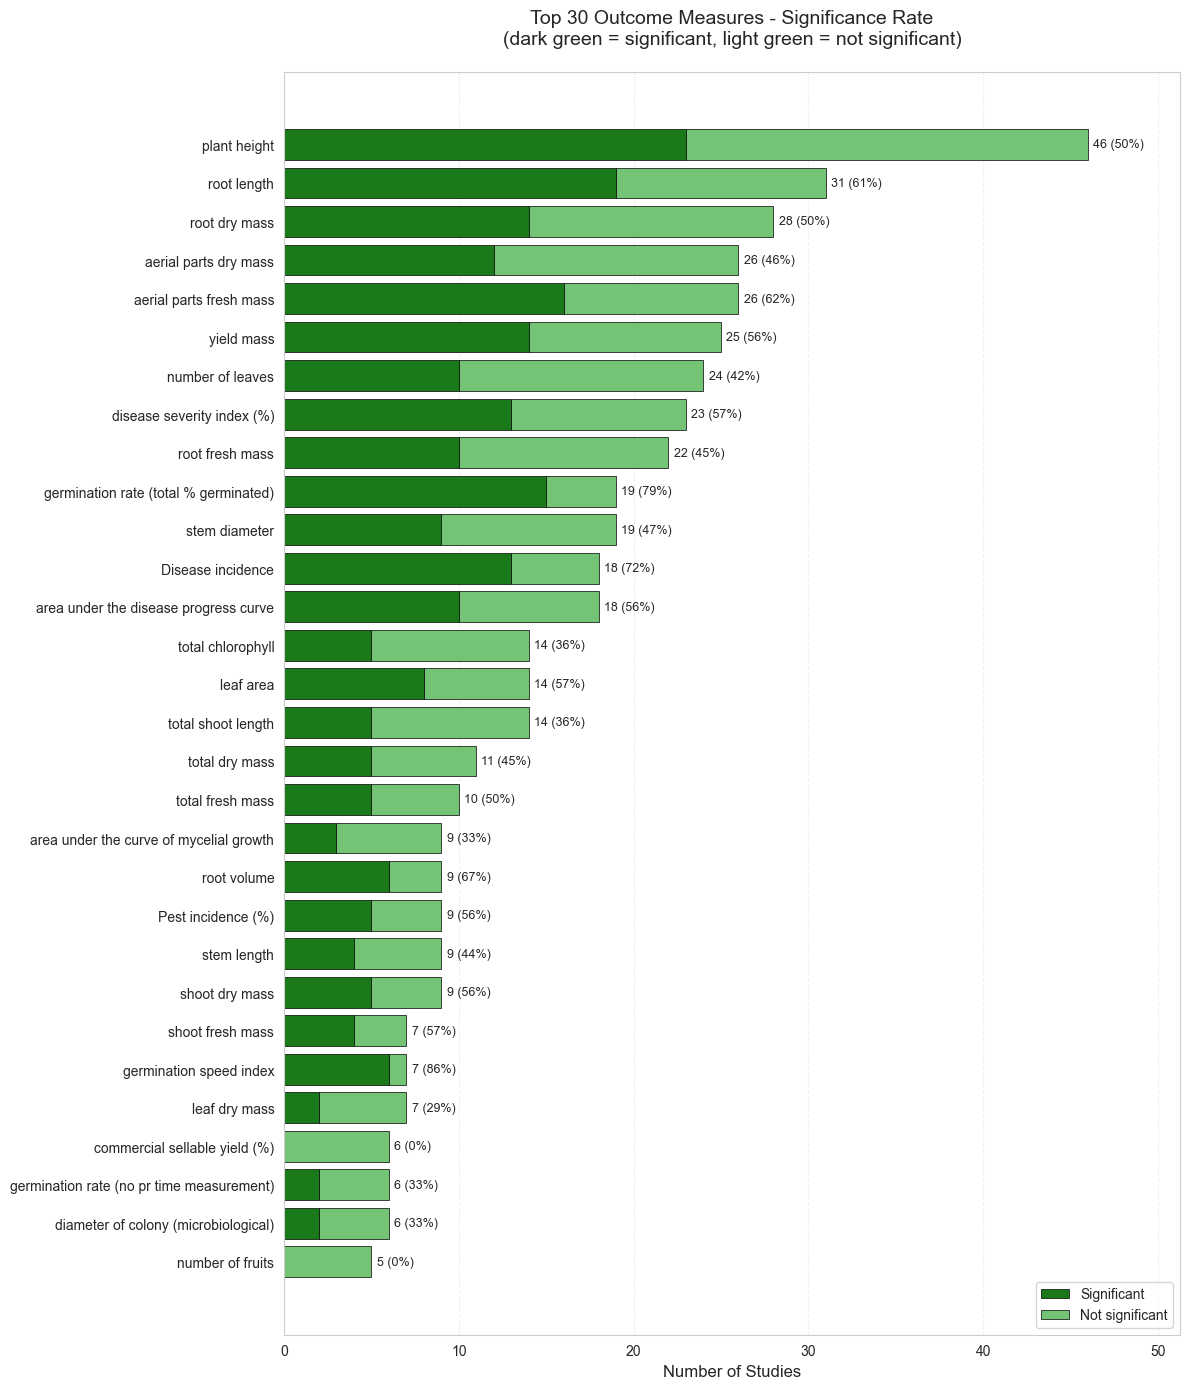

In [351]:
# Stacked bar chart: outcome measures with significance overlay
# Dark green = also significant, light green = measured but not significant

outcome_col = 'Outcome measures (specific)'
sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Step 1: Get top 30 outcomes (same logic as earlier chart, original case preserved)
outcome_series_s = (
    df[outcome_col]
    .fillna('N/A')
    .astype(str)
    .str.strip()
)
outcome_exploded_s = (
    outcome_series_s
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
    .replace({'': 'N/A'})
)
outcome_counts_s = outcome_exploded_s.value_counts().drop(['N/A'], errors='ignore').head(30)

# Build lowercase -> original-case mapping for top 30 outcomes
top30_lower_to_orig = {o.lower(): o for o in outcome_counts_s.index}
top30_lower = set(top30_lower_to_orig.keys())

# Step 2: Count significant occurrences per outcome by cross-referencing both columns
from collections import defaultdict
sig_counts = defaultdict(int)

for idx, row in df.iterrows():
    sig_text = row[sig_col]

    # Skip blank/null
    if pd.isna(sig_text):
        continue

    sig_text_lower = str(sig_text).lower().strip()

    # Skip special cases (no significant outcomes for this study)
    if 'not significant' in sig_text_lower or 'no significance calculated' in sig_text_lower:
        continue

    # Get outcomes and significant items for this study (lowercased sets)
    outcomes_lower = normalize_items(row[outcome_col])
    significant_lower = normalize_items(sig_text)

    # For each top-30 outcome this study measured and found significant
    for outcome_lc in top30_lower:
        if outcome_lc in outcomes_lower and outcome_lc in significant_lower:
            orig = top30_lower_to_orig[outcome_lc]
            sig_counts[orig] += 1

# Step 3: Build arrays in reverse order (so most frequent is at top)
labels = outcome_counts_s.index[::-1].tolist()
totals = outcome_counts_s.values[::-1].tolist()
sig_vals = [sig_counts[lbl] for lbl in labels]
not_sig_vals = [t - s for t, s in zip(totals, sig_vals)]

# Step 4: Plot stacked horizontal bar chart
fig_stacked, ax_stacked = plt.subplots(figsize=(12, 14))

y_pos = range(len(labels))

# Dark green = significant
ax_stacked.barh(y_pos, sig_vals, color='#1a7a1a', edgecolor='black', linewidth=0.5, label='Significant')
# Light green = not significant (stacked on top)
ax_stacked.barh(y_pos, not_sig_vals, left=sig_vals, color='#74c476', edgecolor='black', linewidth=0.5, label='Not significant')

# Axis labels and title
ax_stacked.set_yticks(y_pos)
ax_stacked.set_yticklabels(labels, fontsize=10)
ax_stacked.set_xlabel('Number of Studies', fontsize=12)
ax_stacked.set_title(
    'Top 30 Outcome Measures - Significance Rate\n(dark green = significant, light green = not significant)',
    fontsize=14, pad=20
)

# Value labels at end of each bar: total count and % significant
for i, (total, sig) in enumerate(zip(totals, sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_stacked.text(total + 0.3, i, f'{total} ({pct:.0f}%)', va='center', fontsize=9)

# Extend x-axis to fit text labels (approx 3 extra characters of space)
max_val = max(totals)
ax_stacked.set_xlim(right=max_val + 0.3 + len(f'{max_val} (100%)') * max_val * 0.012)

ax_stacked.legend(loc='lower right', fontsize=10)

ax_stacked.grid(axis='x', alpha=0.3, linestyle='--')
ax_stacked.set_axisbelow(True)
ax_stacked.yaxis.grid(False)

plt.tight_layout()
fig_stacked.savefig('outcome_measures_significance_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


## Crop - which are significant?
This can not be exhaustatively done, as each study can have multiple crops, and we did not record the significances directly connected to the crops

Single-crop studies: 148 out of 160 total rows


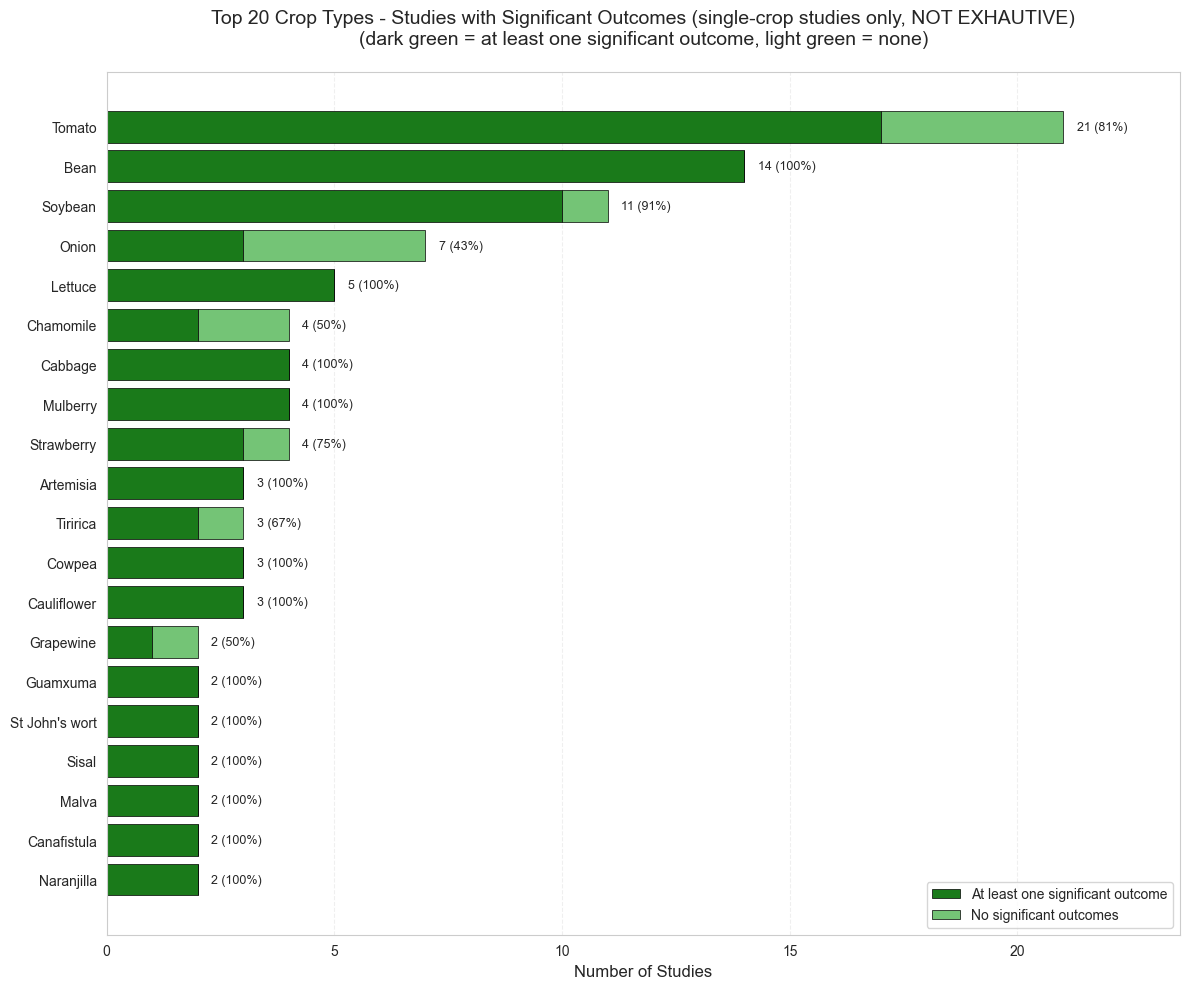

In [352]:
# Stacked bar chart: top 20 crop types with significance overlay
# Single-crop studies only (multi-crop rows excluded - significance not linkable to specific crop)
# Dark green = study had at least one significant outcome
# Light green = study had no significant outcomes

sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Step 1: Filter to single-crop studies only
crop_series_st = df['Crop type studied'].fillna('').astype(str).str.strip()
single_crop_mask = (~crop_series_st.str.contains(',')) & (crop_series_st != '') & (crop_series_st.str.lower() != 'n/a')
df_single_crop = df[single_crop_mask].copy()

print(f"Single-crop studies: {len(df_single_crop)} out of {len(df)} total rows")

# Step 2: Get top 20 crop types by frequency (among single-crop studies)
crop_counts_st = df_single_crop['Crop type studied'].str.strip().value_counts().head(20)
top20_crop_set = set(crop_counts_st.index)

# Step 3: Helper to check if a study had at least one significant outcome
def has_significant_outcome(sig_text):
    if pd.isna(sig_text):
        return False
    s = str(sig_text).lower().strip()
    if s in ['', 'n/a', 'blank']:
        return False
    if 'not significant' in s or 'no significance calculated' in s:
        return False
    return True

# Step 4: Count significant studies per crop
sig_counts_crop = {}
for crop in top20_crop_set:
    crop_rows = df_single_crop[df_single_crop['Crop type studied'].str.strip() == crop]
    sig_counts_crop[crop] = int(crop_rows.apply(lambda r: has_significant_outcome(r[sig_col]), axis=1).sum())

# Step 5: Build arrays (reversed so most frequent is at top)
crop_labels = crop_counts_st.index[::-1].tolist()
crop_totals = crop_counts_st.values[::-1].tolist()
crop_sig_vals = [sig_counts_crop[lbl] for lbl in crop_labels]
crop_not_sig_vals = [t - s for t, s in zip(crop_totals, crop_sig_vals)]

# Step 6: Plot stacked horizontal bar chart
fig_crop_st, ax_crop_st = plt.subplots(figsize=(12, 10))

y_pos = range(len(crop_labels))

ax_crop_st.barh(y_pos, crop_sig_vals, color='#1a7a1a', edgecolor='black', linewidth=0.5, label='At least one significant outcome')
ax_crop_st.barh(y_pos, crop_not_sig_vals, left=crop_sig_vals, color='#74c476', edgecolor='black', linewidth=0.5, label='No significant outcomes')

ax_crop_st.set_yticks(y_pos)
ax_crop_st.set_yticklabels(crop_labels, fontsize=10)
ax_crop_st.set_xlabel('Number of Studies', fontsize=12)
ax_crop_st.set_title(
    'Top 20 Crop Types - Studies with Significant Outcomes (single-crop studies only, NOT EXHAUTIVE)\n(dark green = at least one significant outcome, light green = none)',
    fontsize=14, pad=20
)

# Value labels at end of each bar: total and % with significance
for i, (total, sig) in enumerate(zip(crop_totals, crop_sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_crop_st.text(total + 0.3, i, f'{total} ({pct:.0f}%)', va='center', fontsize=9)

# Extend x-axis to prevent text clipping
max_crop_val = max(crop_totals)
ax_crop_st.set_xlim(right=max_crop_val + 0.3 + len(f'{max_crop_val} (100%)') * max_crop_val * 0.012)

ax_crop_st.legend(loc='lower right', fontsize=10)

ax_crop_st.grid(axis='x', alpha=0.3, linestyle='--')
ax_crop_st.set_axisbelow(True)
ax_crop_st.yaxis.grid(False)

plt.tight_layout()
fig_crop_st.savefig('crop_type_significance_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


Studies with valid country data: 160 out of 160 total rows


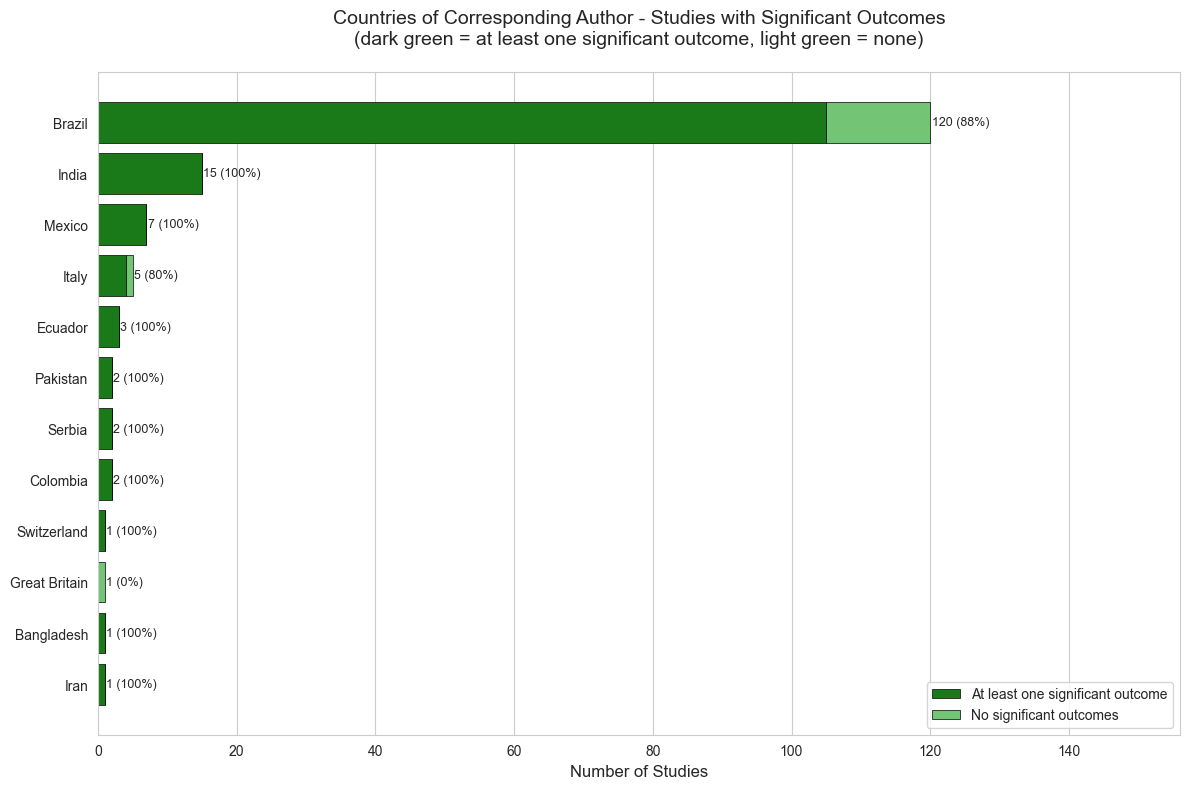

In [353]:
# Stacked bar chart: countries of corresponding author with significance overlay
# Each study has exactly one country, so no multi-value filtering needed.
# Dark green = at least one significant outcome
# Light green = no significant outcomes

sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Step 1: Prepare country series (drop blanks and N/A)
country_series_sig = df['Country of corresponding author'].fillna('').astype(str).str.strip()
valid_country_mask_sig = (country_series_sig != '') & (country_series_sig.str.lower() != 'n/a')
df_country_sig = df[valid_country_mask_sig].copy()
df_country_sig['_country'] = country_series_sig[valid_country_mask_sig]

print(f"Studies with valid country data: {len(df_country_sig)} out of {len(df)} total rows")

# Step 2: Get all countries by frequency
country_counts_sig = df_country_sig['_country'].value_counts()

# Step 3: Helper to check if a study had at least one significant outcome
def has_significant_outcome_country(sig_text):
    if pd.isna(sig_text):
        return False
    s = str(sig_text).lower().strip()
    if s in ['', 'n/a', 'blank']:
        return False
    if 'not significant' in s or 'no significance calculated' in s:
        return False
    return True

# Step 4: Count significant studies per country
sig_counts_country = {}
for country in country_counts_sig.index:
    rows = df_country_sig[df_country_sig['_country'] == country]
    sig_counts_country[country] = int(rows.apply(lambda r: has_significant_outcome_country(r[sig_col]), axis=1).sum())

# Step 5: Build arrays (reversed so most frequent is at top)
country_labels_sig = country_counts_sig.index[::-1].tolist()
country_totals_sig = country_counts_sig.values[::-1].tolist()
country_sig_vals = [sig_counts_country[lbl] for lbl in country_labels_sig]
country_not_sig_vals = [t - s for t, s in zip(country_totals_sig, country_sig_vals)]

# Step 6: Plot stacked horizontal bar chart
n_countries = len(country_labels_sig)
fig_country_sig, ax_country_sig = plt.subplots(figsize=(12, max(8, n_countries * 0.4)))

y_pos_sig = range(n_countries)

ax_country_sig.barh(y_pos_sig, country_sig_vals, color='#1a7a1a', edgecolor='black', linewidth=0.5, label='At least one significant outcome')
ax_country_sig.barh(y_pos_sig, country_not_sig_vals, left=country_sig_vals, color='#74c476', edgecolor='black', linewidth=0.5, label='No significant outcomes')

ax_country_sig.set_yticks(y_pos_sig)
ax_country_sig.set_yticklabels(country_labels_sig, fontsize=10)
ax_country_sig.set_xlabel('Number of Studies', fontsize=12)
ax_country_sig.set_title(
    'Countries of Corresponding Author - Studies with Significant Outcomes\n(dark green = at least one significant outcome, light green = none)',
    fontsize=14, pad=20
)

# Value labels at end of each bar: total count and % with significance
for i, (total, sig) in enumerate(zip(country_totals_sig, country_sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_country_sig.text(total + 0.2, i, f'{total} ({pct:.0f}%)', va='center', fontsize=9)

# Extend x-axis to prevent text clipping
max_country_val = max(country_totals_sig)
ax_country_sig.set_xlim(0, max_country_val * 1.3)

ax_country_sig.legend(loc='lower right', fontsize=10)
ax_country_sig.yaxis.grid(False)

plt.tight_layout()
plt.savefig('country_significance_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()
